# Understanding Attitudes Toward Violence Against Women and Girls




## 1. Project Introduction

Violence against women and girls remains a major social and development challenge across the world. While legal frameworks and public awareness campaigns have expanded considerably, attitudes that justify violence against women continue to exist within different populations and social groups.

Understanding these attitudes is important because social norms and beliefs can influence how violence is perceived, tolerated, reported, and addressed within communities.

This project analyzes survey data on attitudes toward violence against women and girls across multiple countries and demographic groups. The analysis will investigate how attitudes vary by **gender, age, education, employment, residence, marital status, country, survey year, and the specific circumstances used to justify violence**.

Rather than simply describing the dataset, this project aims to identify meaningful patterns, demographic disparities, country-level differences, and factors associated with greater acceptance of violence.

The findings will be translated into actionable insights that can potentially support policymakers, development organizations, gender-focused programs, and researchers in designing more targeted interventions.



## 2. Problem Statement

Despite significant efforts to prevent violence against women and girls, harmful attitudes and social norms that justify violence continue to exist in many communities.

However, these attitudes are not necessarily distributed equally across populations. Differences may exist according to education, age, gender, employment, marital status, place of residence, and country.

Without identifying these patterns, interventions may be designed too broadly and fail to adequately target populations where harmful attitudes are most prevalent.

This project therefore seeks to use data science and statistical analysis to investigate the demographic and geographical patterns associated with attitudes toward violence against women and girls.



## 3. Project Goal

The overall goal of this project is to **identify and explain demographic, geographical, and temporal patterns in attitudes toward violence against women and girls using data-driven methods.**



## 4. Project Objectives

### General Objective

To analyze cross-country survey data to understand the demographic and social factors associated with attitudes toward violence against women and girls.

### Specific Objectives

1. Examine the distribution of attitudes toward violence across countries.
2. Compare attitudes across different demographic groups.
3. Investigate differences between male and female respondents.
4. Examine the relationship between education and attitudes toward violence.
5. Investigate differences between urban and rural populations.
6. Analyze variations across age, employment, and marital-status groups.
7. Identify which circumstances are most commonly used to justify violence.
8. Examine changes in reported attitudes across survey years where sufficient data are available.
9. Identify countries and demographic groups with particularly high levels of acceptance.
10. Develop statistical and machine-learning approaches to identify important predictors of the observed patterns.
11. Translate the findings into practical recommendations for policy and social-impact interventions.



## 5. Research Questions

The analysis will seek to answer the following questions:

### Primary Research Question

**How do attitudes toward the justification of violence against women and girls vary across countries, demographic groups, genders, and different justifications for violence?**

### Secondary Research Questions

1. Which countries report the highest levels of acceptance of violence?
2. Which demographic groups show the highest levels of acceptance?
3. Does education appear to be associated with lower acceptance of violence?
4. Are attitudes different between male and female respondents?
5. Are attitudes different between urban and rural populations?
6. How do attitudes vary across age groups?
7. Does employment status appear to influence attitudes?
8. Do attitudes differ according to marital status?
9. Which circumstances are most commonly considered acceptable justifications for violence?
10. Have attitudes changed over time in countries with multiple survey years?
11. Which factors explain the greatest variation in reported attitudes?
12. Can statistical or machine-learning models predict the reported level of acceptance based on demographic and contextual characteristics?



## 6. Expected Value of the Analysis

The analysis is intended to move beyond simple descriptive statistics and provide evidence that can help identify:

* Populations that may require targeted awareness and prevention programs.
* Countries or regions with particularly high levels of acceptance.
* Demographic characteristics associated with differing attitudes.
* Potential relationships between education and harmful social norms.
* Differences between urban and rural populations.
* Changes in attitudes over time.
* Areas requiring further research or intervention.

The ultimate objective is to transform survey data into **evidence that can support better decision-making and more targeted social-impact interventions.**



## 7. Important Analytical Consideration

The dataset contains **aggregated survey results rather than individual respondent-level observations**.

Therefore, the analysis will primarily identify **patterns and associations between demographic groups and reported percentages**. Findings will not automatically imply that one factor causes another.

For example, if a particular education group reports lower acceptance of violence, this may indicate an association between education and attitudes, but it does not by itself prove that education causes the difference.

Statistical analysis will therefore be interpreted carefully, with particular attention to the limitations of aggregated survey data.


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Statistical analysis
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## 8. Loading the Dataset

The dataset contains survey-based information on attitudes toward violence against women and girls across multiple countries, demographic groups, survey questions, and survey years.

The first step is to load the dataset and verify that it has been imported correctly before beginning any cleaning or analysis.


In [2]:
# Load dataset
df = pd.read_csv("../data/Violence Against Women  Girls Data.csv")

# Display first five rows
df

,RecordID,Country,Gender,Demographics Question,Demographics Response,Question,Survey Year,Value
0,1,Afghanistan,F,Marital status,Never married,... if she burns the food,01/01/2015,NaN
1,1,Afghanistan,F,Education,Higher,... if she burns the food,01/01/2015,10.1
2,1,Afghanistan,F,Education,Secondary,... if she burns the food,01/01/2015,13.7
3,1,Afghanistan,F,Education,Primary,... if she burns the food,01/01/2015,13.8
4,1,Afghanistan,F,Marital status,"Widowed, divorced, separated",... if she burns the food,01/01/2015,13.8
...,...,...,...,...,...,...,...,...
12595,210,Zimbabwe,M,Residence,Urban,... if she goes out without telling him,01/01/2015,11.8
12596,280,Zimbabwe,M,Residence,Rural,... if she neglects the children,01/01/2015,20.1
12597,280,Zimbabwe,M,Residence,Urban,... if she neglects the children,01/01/2015,15.0
12598,350,Zimbabwe,M,Residence,Rural,... if she refuses to have sex with him,01/01/2015,7.2


In [3]:
df.shape

(12600, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RecordID               12600 non-null  int64  
 1   Country                12600 non-null  object 
 2   Gender                 12600 non-null  object 
 3   Demographics Question  12600 non-null  object 
 4   Demographics Response  12600 non-null  object 
 5   Question               12600 non-null  object 
 6   Survey Year            12600 non-null  object 
 7   Value                  11187 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 787.6+ KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RecordID,12600.0,NaN,NaN,NaN,210.5,121.248024,1.0,105.75,210.5,315.25,420.0
Country,12600,70,Afghanistan,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,12600,2,F,6300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Demographics Question,12600,5,Education,3360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Demographics Response,12600,15,Never married,840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Question,12600,6,... if she burns the food,2100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survey Year,12600,18,01/01/2013,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,11187.0,NaN,NaN,NaN,19.762537,16.986437,0.0,6.2,14.9,29.2,86.9


In [6]:
df.isnull().sum()

RecordID                    0
Country                     0
Gender                      0
Demographics Question       0
Demographics Response       0
Question                    0
Survey Year                 0
Value                    1413
dtype: int64

## 9. Data Understanding

Before performing statistical analysis or building predictive models, it is important to understand the structure of the dataset and determine what each observation represents.

The dataset contains **12,600 records and 8 variables**. It combines information about countries, respondent gender, demographic characteristics, survey questions, survey years, and the reported percentage of respondents associated with each observation.

An initial inspection shows that:

* There are **70 countries** represented.
* The dataset contains **2 respondent gender categories**.
* Five demographic dimensions are represented.
* There are **15 demographic response categories**.
* Six questions address different circumstances associated with attitudes toward violence against women.
* The dataset contains **18 survey-year values**.
* The outcome variable, `Value`, contains **11,187 non-missing observations** and **1,413 missing observations**.
* `Value` ranges from **0% to 86.9%**, with a mean of approximately **19.76%**.

An important structural characteristic is that `RecordID` contains only 420 unique values despite the dataset containing 12,600 rows. This indicates that multiple rows may represent different combinations of gender, demographic characteristics, questions, or other dimensions associated with the same underlying record.

This structure must be investigated before statistical testing or machine-learning modeling to avoid treating related observations as independent observations.


In [7]:
categorical_cols = [
    "Country",
    "Gender",
    "Demographics Question",
    "Demographics Response",
    "Question",
    "Survey Year"
]

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")
    print(df[col].value_counts(dropna=False))


Country
Country
Afghanistan                  180
Albania                      180
Angola                       180
Armenia                      180
Azerbaijan                   180
Bangladesh                   180
Benin                        180
Bolivia                      180
Burkina Faso                 180
Burundi                      180
Cambodia                     180
Cameroon                     180
Chad                         180
Colombia                     180
Comoros                      180
Congo                        180
Congo Democratic Republic    180
Cote d'Ivoire                180
Dominican Republic           180
Egypt                        180
Eritrea                      180
Eswatini                     180
Ethiopia                     180
Gabon                        180
Gambia                       180
Ghana                        180
Guatemala                    180
Guinea                       180
Guyana                       180
Haiti                     

In [8]:
pd.crosstab(
    df["Demographics Question"],
    df["Demographics Response"]
)

Demographics Response,15-24,25-34,35-49,Employed for cash,Employed for kind,Higher,Married or living together,Never married,No education,Primary,Rural,Secondary,Unemployed,Urban,"Widowed, divorced, separated"
Demographics Question,,,,,,,,,,,,,,,
Age,840,840,840,0,0,0,0,0,0,0,0,0,0,0,0
Education,0,0,0,0,0,840,0,0,840,840,0,840,0,0,0
Employment,0,0,0,840,840,0,0,0,0,0,0,0,840,0,0
Marital status,0,0,0,0,0,0,840,840,0,0,0,0,0,0,840
Residence,0,0,0,0,0,0,0,0,0,0,840,0,0,840,0


In [9]:
df["RecordID"].nunique()

420

In [10]:
df["RecordID"].value_counts().value_counts().sort_index()

count
30    420
Name: count, dtype: int64

In [11]:
df.groupby("RecordID").size().describe()

count    420.0
mean      30.0
std        0.0
min       30.0
25%       30.0
50%       30.0
75%       30.0
max       30.0
dtype: float64

In [12]:
df[df["RecordID"] == 1]

,RecordID,Country,Gender,Demographics Question,Demographics Response,Question,Survey Year,Value
0,1,Afghanistan,F,Marital status,Never married,... if she burns the food,01/01/2015,NaN
1,1,Afghanistan,F,Education,Higher,... if she burns the food,01/01/2015,10.1
2,1,Afghanistan,F,Education,Secondary,... if she burns the food,01/01/2015,13.7
3,1,Afghanistan,F,Education,Primary,... if she burns the food,01/01/2015,13.8
4,1,Afghanistan,F,Marital status,"Widowed, divorced, separated",... if she burns the food,01/01/2015,13.8
5,1,Afghanistan,F,Employment,Employed for kind,... if she burns the food,01/01/2015,17.0
6,1,Afghanistan,F,Age,15-24,... if she burns the food,01/01/2015,17.3
7,1,Afghanistan,F,Employment,Unemployed,... if she burns the food,01/01/2015,18.0
8,1,Afghanistan,F,Residence,Rural,... if she burns the food,01/01/2015,18.1
9,1,Afghanistan,F,Age,25-34,... if she burns the food,01/01/2015,18.2


In [13]:
df[df["RecordID"] == 2]

,RecordID,Country,Gender,Demographics Question,Demographics Response,Question,Survey Year,Value
180,2,Albania,F,Education,Higher,... if she burns the food,01/01/2017,0.2
181,2,Albania,F,Residence,Urban,... if she burns the food,01/01/2017,0.4
182,2,Albania,F,Age,15-24,... if she burns the food,01/01/2017,0.6
183,2,Albania,F,Education,Secondary,... if she burns the food,01/01/2017,0.6
184,2,Albania,F,Employment,Employed for cash,... if she burns the food,01/01/2017,0.6
185,2,Albania,F,Marital status,Never married,... if she burns the food,01/01/2017,0.6
186,2,Albania,F,Marital status,"Widowed, divorced, separated",... if she burns the food,01/01/2017,0.6
187,2,Albania,F,Age,25-34,... if she burns the food,01/01/2017,0.8
188,2,Albania,F,Employment,Unemployed,... if she burns the food,01/01/2017,0.8
189,2,Albania,F,Marital status,Married or living together,... if she burns the food,01/01/2017,0.9


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.duplicated(
    subset=[
        "Country",
        "Gender",
        "Demographics Question",
        "Demographics Response",
        "Question",
        "Survey Year"
    ]
).sum()

np.int64(0)

In [16]:
df["Survey Year"].unique()

array(['01/01/2015', '01/01/2017', '01/01/2006', '01/01/2014',
       '01/01/2008', '01/01/2010', '01/01/2016', '01/01/2011',
       '01/01/2012', '01/01/2013', '01/01/2002', '01/01/2018',
       '01/01/2009', '01/01/2005', '01/01/2003', '01/01/2001',
       '01/01/2000', '01/01/2007'], dtype=object)

In [17]:
df["Survey Year"].value_counts().sort_index()

Survey Year
01/01/2000     180
01/01/2001     180
01/01/2002     180
01/01/2003     180
01/01/2005     180
01/01/2006     360
01/01/2007     180
01/01/2008     540
01/01/2009     180
01/01/2010     180
01/01/2011     720
01/01/2012    1080
01/01/2013    1980
01/01/2014    1620
01/01/2015    1800
01/01/2016    1440
01/01/2017    1260
01/01/2018     360
Name: count, dtype: int64

## 10. Understanding the Dataset Structure

The dataset follows a structured multi-dimensional design.

Each `RecordID` contains exactly 30 observations. These observations represent combinations of:

* 2 genders
* 5 demographic dimensions
* 15 demographic response categories

The 15 demographic responses are distributed across the five demographic dimensions as follows:

| Demographic Dimension | Categories                                                            |
| --------------------- | --------------------------------------------------------------------- |
| Age                   | 15–24, 25–34, 35–49                                                   |
| Education             | No education, Primary, Secondary, Higher                              |
| Employment            | Employed for cash, Employed for kind, Unemployed                      |
| Marital status        | Married or living together, Never married, Widowed/divorced/separated |
| Residence             | Rural, Urban                                                          |

This gives:

**3 + 4 + 3 + 3 + 2 = 15 demographic categories**

When combined with the two gender categories, each country-year-question combination produces:

**2 × 15 = 30 observations.**

Therefore, the `RecordID` represents a country-year-question combination rather than an independent individual respondent.

This structure is important because the `Value` variable represents an aggregated percentage rather than an individual-level response.

Consequently, the project will focus on analyzing **patterns in reported percentages across countries, demographic groups, violence scenarios, and survey years**, rather than treating each row as an independent respondent.


In [18]:
missing_summary = (
    df.assign(Missing_Value=df["Value"].isna())
      .groupby([
          "Gender",
          "Demographics Question",
          "Demographics Response"
      ])["Missing_Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

missing_summary

,Gender,Demographics Question,Demographics Response,count,sum,mean
0,F,Age,15-24,420,5,0.011905
1,F,Age,25-34,420,5,0.011905
2,F,Age,35-49,420,5,0.011905
3,F,Education,Higher,420,11,0.026190
4,F,Education,No education,420,29,0.069048
5,F,Education,Primary,420,11,0.026190
6,F,Education,Secondary,420,5,0.011905
7,F,Employment,Employed for cash,420,16,0.038095
8,F,Employment,Employed for kind,420,11,0.026190
9,F,Employment,Unemployed,420,5,0.011905


In [19]:
missing_by_question = (
    df.groupby("Question")["Value"]
      .apply(lambda x: x.isna().sum())
      .sort_values(ascending=False)
)

missing_by_question

Question
... if she argues with him                 271
... if she burns the food                  271
... if she refuses to have sex with him    238
... for at least one specific reason       211
... if she goes out without telling him    211
... if she neglects the children           211
Name: Value, dtype: int64

In [20]:
missing_by_country = (
    df.groupby("Country")["Value"]
      .apply(lambda x: x.isna().sum())
      .sort_values(ascending=False)
)

missing_by_country.head(20)

Country
Turkey             102
Bangladesh          96
Egypt               96
Eritrea             90
Bolivia             90
Peru                90
Nicaragua           90
Tajikistan          90
Turkmenistan        90
Yemen               90
Morocco             90
Philippines         90
Maldives            60
Congo               60
Jordan              45
Ukraine             24
Moldova             18
Kyrgyz Republic     18
Afghanistan         12
Pakistan            12
Name: Value, dtype: int64

In [21]:
country_year = (
    df.groupby(["Country", "Survey Year"])
      .agg(
          records=("RecordID", "nunique"),
          observations=("RecordID", "size"),
          non_missing=("Value", "count")
      )
      .reset_index()
)

country_year.head(20)

,Country,Survey Year,records,observations,non_missing
0,Afghanistan,01/01/2015,6,180,168
1,Albania,01/01/2017,6,180,180
2,Angola,01/01/2015,6,180,180
3,Armenia,01/01/2015,6,180,168
4,Azerbaijan,01/01/2006,6,180,168
5,Bangladesh,01/01/2014,6,180,84
6,Benin,01/01/2017,6,180,180
7,Bolivia,01/01/2008,6,180,90
8,Burkina Faso,01/01/2010,6,180,180
9,Burundi,01/01/2016,6,180,180


In [22]:
country_year["observations"].value_counts()

observations
180    70
Name: count, dtype: int64

In [23]:
df.groupby("Country")["Survey Year"].nunique().sort_values(ascending=False)

Country
Afghanistan                  1
Albania                      1
Angola                       1
Armenia                      1
Azerbaijan                   1
Bangladesh                   1
Benin                        1
Bolivia                      1
Burkina Faso                 1
Burundi                      1
Cambodia                     1
Cameroon                     1
Chad                         1
Colombia                     1
Comoros                      1
Congo                        1
Congo Democratic Republic    1
Cote d'Ivoire                1
Dominican Republic           1
Egypt                        1
Eritrea                      1
Eswatini                     1
Ethiopia                     1
Gabon                        1
Gambia                       1
Ghana                        1
Guatemala                    1
Guinea                       1
Guyana                       1
Haiti                        1
Honduras                     1
India                        1


We have now established:

- 70 countries
- 70 country-year combinations
- 6 questions per country
- 2 genders
- 15 demographic categories
- 30 rows per RecordID
- 180 rows per country
- 12,600 total observations
- 1 survey year per country
- 1,413 missing values
- Missingness is structured rather than obviously random

In [24]:
#check for dublicates
print("Full duplicate rows:", df.duplicated().sum())

print(
    "Duplicate country/gender/demographic/question/year combinations:",
    df.duplicated(
        subset=[
            "Country",
            "Gender",
            "Demographics Question",
            "Demographics Response",
            "Question",
            "Survey Year"
        ]
    ).sum()
)

Full duplicate rows: 0
Duplicate country/gender/demographic/question/year combinations: 0


In [25]:
#where do the missing values occur
missing_pattern = (
    df[df["Value"].isna()]
    .groupby([
        "Country",
        "Gender",
        "Demographics Question",
        "Demographics Response",
        "Question"
    ])
    .size()
    .reset_index(name="missing_count")
    .sort_values("missing_count", ascending=False)
)

missing_pattern.head(30)

,Country,Gender,Demographics Question,Demographics Response,Question,missing_count
1412,Yemen,M,Residence,Urban,... if she refuses to have sex with him,1
0,Afghanistan,F,Marital status,Never married,... for at least one specific reason,1
1,Afghanistan,F,Marital status,Never married,... if she argues with him,1
2,Afghanistan,F,Marital status,Never married,... if she burns the food,1
3,Afghanistan,F,Marital status,Never married,... if she goes out without telling him,1
1396,Yemen,M,Marital status,"Widowed, divorced, separated",... if she argues with him,1
1395,Yemen,M,Marital status,"Widowed, divorced, separated",... for at least one specific reason,1
1394,Yemen,M,Marital status,Never married,... if she refuses to have sex with him,1
1393,Yemen,M,Marital status,Never married,... if she neglects the children,1
1392,Yemen,M,Marital status,Never married,... if she goes out without telling him,1


In [26]:
missing_by_demo = (
    df[df["Value"].isna()]
    .groupby([
        "Demographics Question",
        "Demographics Response"
    ])
    .size()
    .reset_index(name="missing_count")
    .sort_values("missing_count", ascending=False)
)

missing_by_demo

,Demographics Question,Demographics Response,missing_count
4,Education,No education,136
11,Marital status,Never married,129
5,Education,Primary,112
7,Employment,Employed for cash,104
8,Employment,Employed for kind,100
12,Marital status,"Widowed, divorced, separated",88
3,Education,Higher,88
6,Education,Secondary,82
0,Age,15-24,82
1,Age,25-34,82


## 13.1 Distribution of Reported Values

The `Value` variable represents the reported percentage associated with a particular violence-related attitude, demographic group, gender, country, and survey year.

Before examining individual demographic or country-level patterns, it is important to understand the overall distribution of reported values. This helps identify the typical level of reported acceptance, the spread of the data, potential skewness, and the presence of unusually high or low observations.


In [27]:
df["Value"].describe()

count    11187.000000
mean        19.762537
std         16.986437
min          0.000000
25%          6.200000
50%         14.900000
75%         29.200000
max         86.900000
Name: Value, dtype: float64

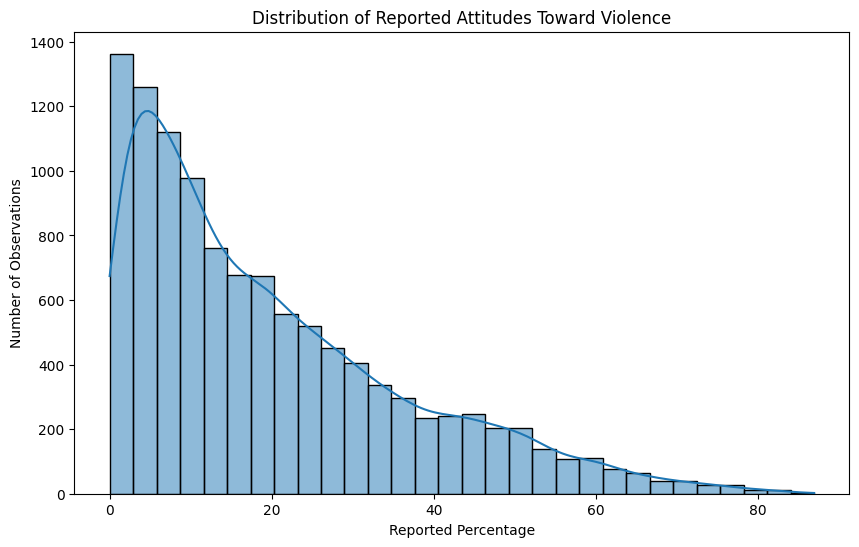

In [28]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Value",
    bins=30,
    kde=True
)

plt.title("Distribution of Reported Attitudes Toward Violence")
plt.xlabel("Reported Percentage")
plt.ylabel("Number of Observations")

plt.show()

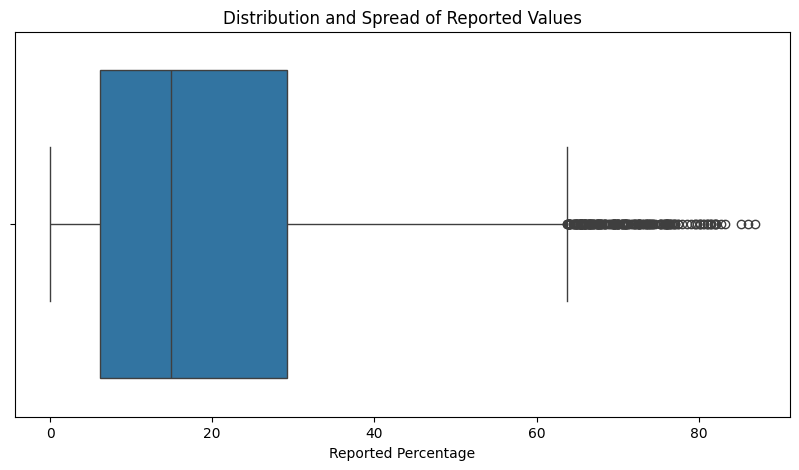

In [29]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Value"
)

plt.title("Distribution and Spread of Reported Values")
plt.xlabel("Reported Percentage")

plt.show()

### Interpretation

The distribution of reported attitudes toward violence is strongly right-skewed. Most reported values are concentrated at the lower end of the scale, while a smaller number of observations report substantially higher levels of acceptance.

The median reported value is approximately **14.9%**, compared with a mean of approximately **19.8%**. The fact that the mean is higher than the median is consistent with the right-skewed distribution.

The boxplot also shows a large number of high-value observations beyond the upper whisker. These observations should not automatically be treated as errors or removed. They may represent countries, demographic groups, or violence scenarios where the reported acceptance of violence is considerably higher.

### Key observation

The distribution suggests that attitudes toward the justification of violence are **not evenly distributed across the dataset**. Most reported percentages are relatively low, but a smaller group of observations records much higher levels.

This indicates that subsequent analysis should investigate **which countries, demographic groups, genders, and violence scenarios are responsible for the higher values** rather than relying only on the overall mean.

### Analytical consideration

Because `Value` represents an aggregated reported percentage rather than an individual respondent's outcome, the observations in this distribution should not be interpreted as 11,187 independent individuals. Each value represents a population-level estimate for a particular country, demographic breakdown, gender, and question.

## 13.2 Country-Level Analysis

Countries may differ substantially in the proportion of respondents who report attitudes that justify violence against women and girls.

This section compares reported values across countries to identify broad differences in attitudes and highlight countries with relatively higher or lower reported levels.

The analysis should be interpreted as a comparison of **reported survey attitudes**, rather than a ranking of countries by actual levels of violence.


In [30]:
country_summary = (
    df.groupby("Country")
      .agg(
          mean_value=("Value", "mean"),
          median_value=("Value", "median"),
          min_value=("Value", "min"),
          max_value=("Value", "max"),
          observations=("Value", "count")
      )
      .sort_values("mean_value", ascending=False)
)

country_summary.head(15)

,mean_value,median_value,min_value,max_value,observations
Country,,,,,
Timor-Leste,46.210000,44.65,14.7,85.2,180
Eritrea,46.186667,48.70,5.1,82.8,90
Morocco,45.213333,48.90,1.1,86.1,90
Tajikistan,44.304444,46.05,8.3,70.1,90
Afghanistan,42.683333,44.50,4.5,86.9,168
Chad,42.436667,41.85,9.3,79.6,180
Congo Democratic Republic,41.576111,42.55,3.3,77.1,180
Guinea,40.256111,41.80,8.2,71.2,180
Mali,39.420000,36.30,2.6,83.3,180


In [31]:
country_summary.tail(15)

,mean_value,median_value,min_value,max_value,observations
Country,,,,,
Bolivia,7.707778,5.35,0.6,23.4,90
Mozambique,7.441111,6.60,0.0,26.2,180
Turkey,6.964103,5.25,0.1,37.0,78
Malawi,6.786111,6.30,0.6,20.0,180
Nicaragua,6.618889,5.40,0.0,22.6,90
Haiti,6.399444,4.95,0.1,22.5,180
Honduras,5.776111,4.50,0.3,23.6,180
Albania,5.417778,3.75,0.0,29.7,180
Philippines,5.063333,2.80,0.7,17.5,90


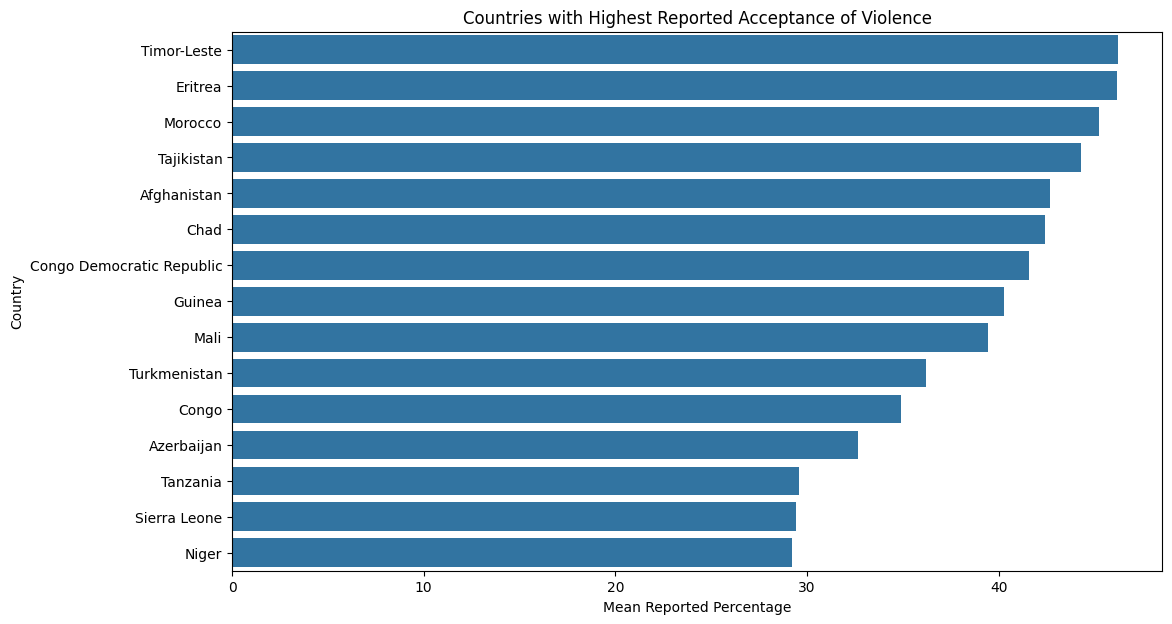

In [32]:
top_countries = country_summary.head(15).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_countries,
    x="mean_value",
    y="Country"
)

plt.title("Countries with Highest Reported Acceptance of Violence")
plt.xlabel("Mean Reported Percentage")
plt.ylabel("Country")

plt.show()

### Interpretation — Countries with Higher Reported Values

The country-level results show substantial variation in reported attitudes toward violence.

Among the countries shown, **Timor-Leste, Eritrea, Morocco, Tajikistan, and Afghanistan** have relatively high average reported values. Timor-Leste has an average reported value of approximately **46.2%**, while Eritrea and Morocco are also above **45%**.

The range within countries is also substantial. For example, Afghanistan has reported values ranging from **4.5% to 86.9%**, demonstrating that the overall country average hides considerable variation between demographic groups, genders, and violence scenarios.

This suggests that country-level averages are useful for identifying broad patterns, but they should not be interpreted in isolation. A high country average may be driven by particular demographic groups or specific justifications for violence.

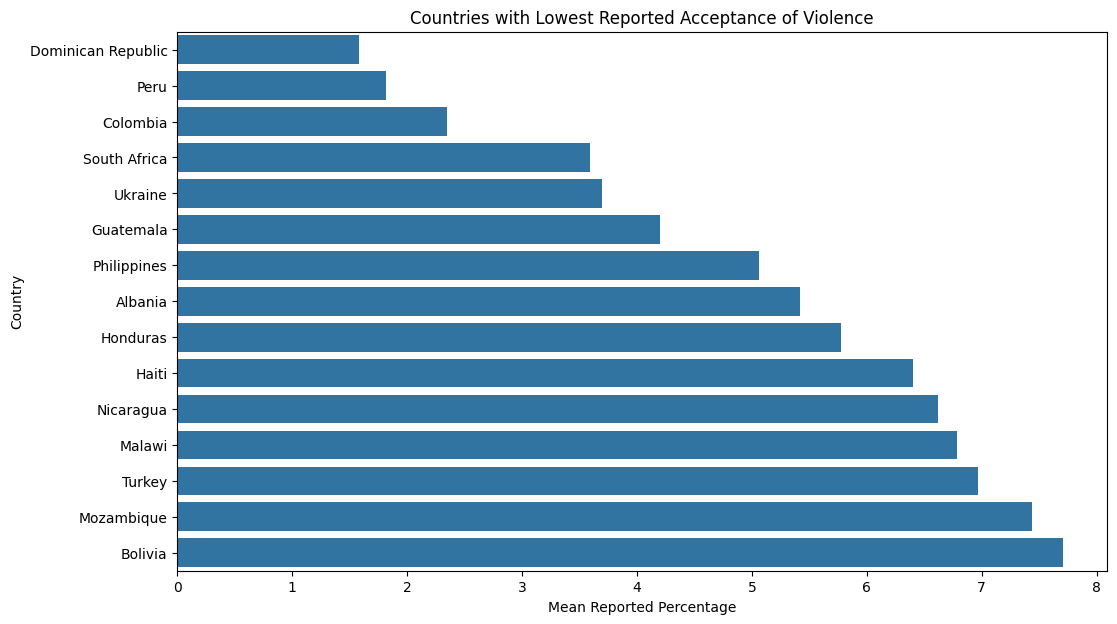

In [33]:
bottom_countries = (
    country_summary
    .tail(15)
    .sort_values("mean_value")
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=bottom_countries,
    x="mean_value",
    y="Country"
)

plt.title("Countries with Lowest Reported Acceptance of Violence")
plt.xlabel("Mean Reported Percentage")
plt.ylabel("Country")

plt.show()

### Interpretation — Countries with Lower Reported Values

The lower end of the country-level distribution is substantially different from the higher end.

Countries such as **Dominican Republic, Peru, Colombia, South Africa, and Ukraine** have relatively low average reported values in the available observations.

Dominican Republic has an average of approximately **1.6%**, while Peru and Colombia have averages of approximately **1.8%** and **2.4%**, respectively.

However, these averages should be interpreted alongside the number of available observations. Some countries have fewer than the full 180 observations because of missing values. Therefore, the country rankings should be treated as descriptive comparisons rather than definitive rankings of populations.

### Analytical insight

The large difference between country averages indicates that **country context is an important source of variation in the dataset**.

The next step is therefore to investigate whether these country-level differences are associated with particular violence scenarios, genders, or demographic groups.

## 13.3 Violence Scenario Analysis

The survey measures attitudes toward violence under several different situations. These scenarios provide an opportunity to examine whether certain circumstances are more commonly associated with the justification of violence.

The analysis will compare the reported percentage across the six scenarios and identify which situations receive the highest and lowest levels of reported acceptance.


In [34]:
question_summary = (
    df.groupby("Question")
      .agg(
          mean_value=("Value", "mean"),
          median_value=("Value", "median"),
          observations=("Value", "count"),
          missing=("Value", lambda x: x.isna().sum())
      )
      .sort_values("mean_value", ascending=False)
)

question_summary

,mean_value,median_value,observations,missing
Question,,,,
... for at least one specific reason,33.217152,31.0,1889,211
... if she neglects the children,23.461249,20.8,1889,211
... if she goes out without telling him,20.046321,16.4,1889,211
... if she argues with him,18.983652,15.7,1829,271
... if she refuses to have sex with him,13.209613,9.0,1862,238
... if she burns the food,9.203445,6.4,1829,271


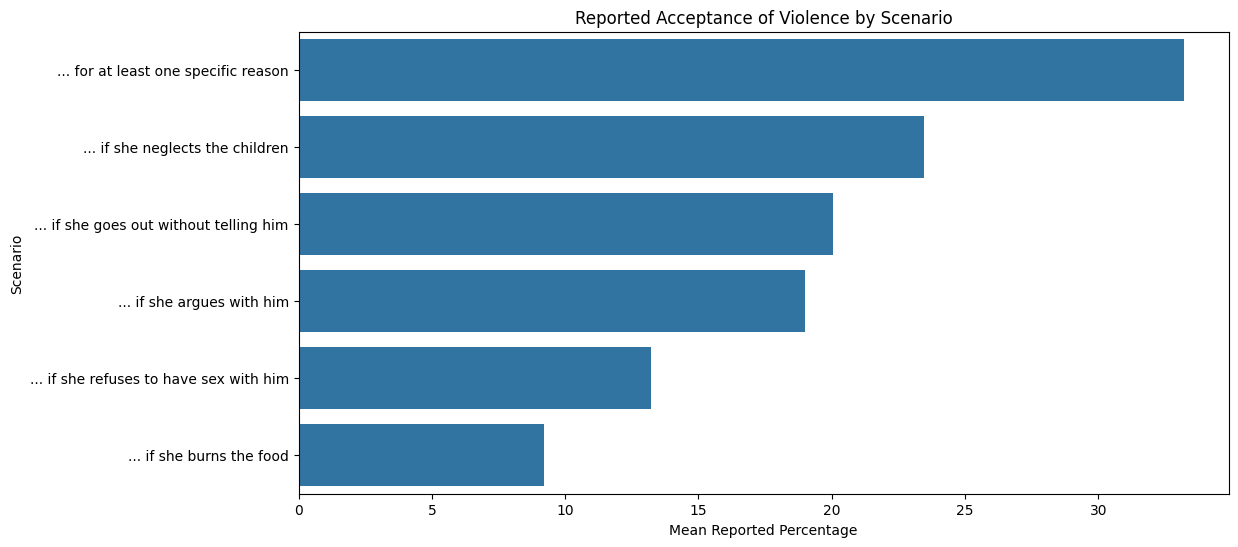

In [35]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=question_summary.reset_index(),
    x="mean_value",
    y="Question"
)

plt.title("Reported Acceptance of Violence by Scenario")
plt.xlabel("Mean Reported Percentage")
plt.ylabel("Scenario")

plt.show()

### Interpretation

There is considerable variation across the different violence-related scenarios.

The highest average reported value is associated with **justifying violence for at least one specific reason**, with an average of approximately **33.2%**.

This is followed by justification related to **neglecting the children**, with an average of approximately **23.5%**, and **going out without telling the partner**, at approximately **20.0%**.

Lower average values are observed for **arguing with the partner (19.0%)**, **refusing to have sex (13.2%)**, and **burning the food (9.2%)**.

The results indicate that acceptance varies substantially depending on the situation used to justify violence.

### Key insight

The difference between the highest and lowest scenario averages is approximately **24 percentage points**.

This means that attitudes toward violence cannot be understood adequately by looking only at an overall measure of acceptance. **The specific justification matters considerably.**

### Analytical caution

These figures represent reported attitudes captured by the underlying survey data. They should therefore be interpreted as measures of reported acceptance or justification, rather than direct measurements of actual violent behaviour.

## 13.4 Gender Analysis

The dataset provides separate reported values for females and males. This allows us to examine whether attitudes toward the justification of violence differ by gender.

Because the dataset contains aggregated survey estimates rather than individual-level responses, gender comparisons will be interpreted as differences in **reported aggregate percentages** rather than individual behavioral differences.


In [36]:
gender_summary = (
    df.groupby("Gender")
      .agg(
          mean_value=("Value", "mean"),
          median_value=("Value", "median"),
          observations=("Value", "count"),
          missing=("Value", lambda x: x.isna().sum())
      )
)

gender_summary

,mean_value,median_value,observations,missing
Gender,,,,
F,22.936350,18.3,6143,157
M,15.897205,12.0,5044,1256


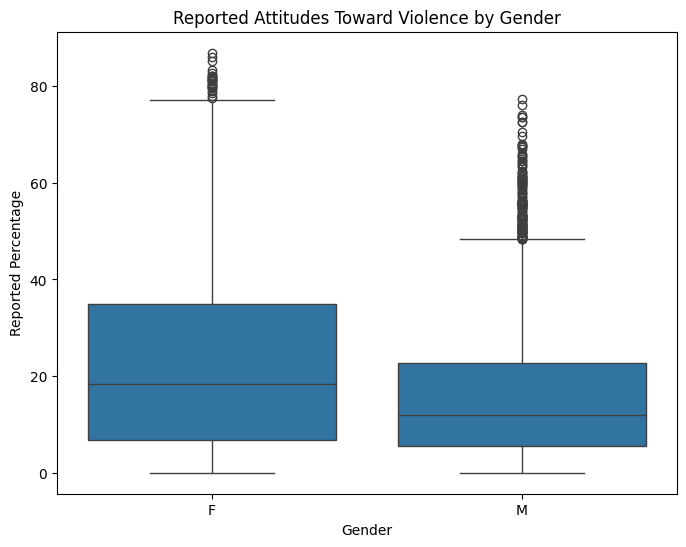

In [37]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Gender",
    y="Value"
)

plt.title("Reported Attitudes Toward Violence by Gender")
plt.xlabel("Gender")
plt.ylabel("Reported Percentage")

plt.show()

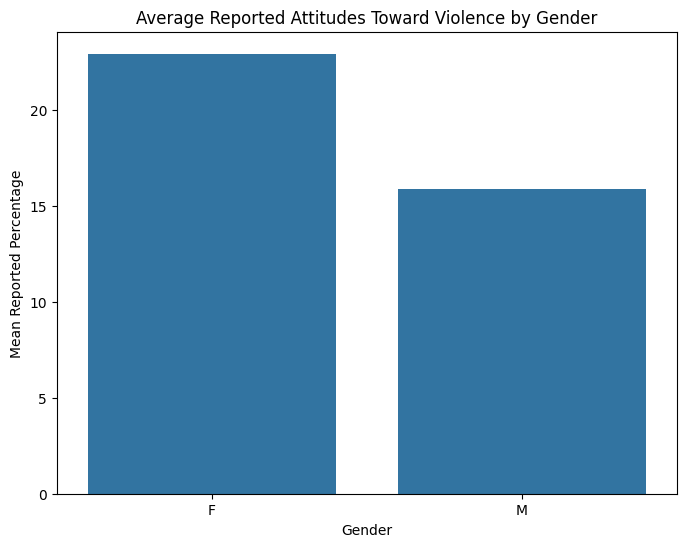

In [38]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=gender_summary.reset_index(),
    x="Gender",
    y="mean_value"
)

plt.title("Average Reported Attitudes Toward Violence by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Reported Percentage")

plt.show()

### Interpretation

The available observations show a higher average reported value for females than males.

The mean reported value is approximately **22.9% for females**, compared with approximately **15.9% for males**. The median follows the same pattern, at **18.3% for females** compared with **12.0% for males**.

This indicates that, within the available observations in this dataset, reported attitudes differ by gender.

However, the missing-data pattern is an important consideration. There are **157 missing female observations compared with 1,256 missing male observations**. Consequently, the male estimates are based on substantially fewer available observations.

The difference in missingness means that the gender comparison should not immediately be interpreted as a population-level gender effect.

### Key analytical question

The gender difference observed here raises an important question:

> Is the difference consistent across countries, violence scenarios, and demographic groups, or is it being driven by a smaller subset of observations?

To answer this, the gender analysis will be broken down by:

- Violence scenario
- Education
- Age
- Employment
- Marital status
- Residence
- Country

This will help determine whether the observed gender difference is broad or concentrated in particular parts of the dataset.

### Education analysis


In [39]:
education_df = df[
    df["Demographics Question"] == "Education"
].copy()

In [40]:
education_summary = (
    education_df.groupby("Demographics Response")
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
    .sort_values("mean_value", ascending=False)
)

education_summary

,mean_value,median_value,observations,missing
Demographics Response,,,,
No education,25.403125,21.55,704,136
Primary,22.819093,18.40,728,112
Secondary,17.378892,13.05,758,82
Higher,8.898670,4.20,752,88


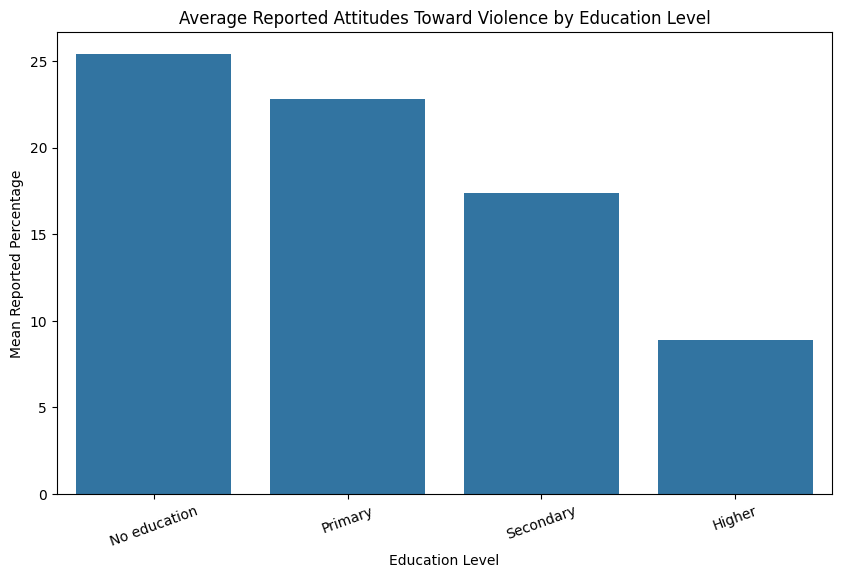

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_summary.reset_index(),
    x="Demographics Response",
    y="mean_value"
)

plt.title("Average Reported Attitudes Toward Violence by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Mean Reported Percentage")
plt.xticks(rotation=20)

plt.show()

### Interpretation

The results show a clear difference in reported attitudes toward the justification of violence across education levels.

Observations associated with **no education** have the highest average reported value at approximately **25.4%**, followed by **primary education** at approximately **22.8%**.

The average decreases to approximately **17.4%** among observations associated with **secondary education**, and falls further to approximately **8.9%** among those with **higher education**.

The median values show a similar pattern:

- No education: **21.55%**
- Primary education: **18.40%**
- Secondary education: **13.05%**
- Higher education: **4.20%**

### Key Insight

There is a strong descriptive gradient in the data: **higher reported education levels are associated with lower reported percentages of justification of violence**.

The difference between the no-education and higher-education groups is approximately **16.5 percentage points in the mean**.

This pattern is consistent with the possibility that education is associated with attitudes toward the justification of violence. However, the descriptive analysis alone cannot establish that education causes these differences.

Other factors, including country, gender, age, residence, employment, and marital status, may also contribute to the observed pattern.

### Missing Data Consideration

The number of missing observations varies across education categories.

The no-education group has **136 missing observations**, compared with 112 for primary, 82 for secondary, and 88 for higher education.

Therefore, comparisons should be based on the available observations and the missing-data pattern should be considered when conducting statistical analysis.

### Next Analytical Step

The next stage is to determine whether the education pattern remains visible when the data are examined across different:

- genders,
- countries,
- violence-related scenarios, and
- other demographic groups.

This will help determine whether the observed education gradient is broad or concentrated in particular parts of the dataset.

## 13.6 Age Analysis

Age is another important demographic dimension in the dataset.

The analysis compares reported attitudes toward the justification of violence across three age groups: **15–24, 25–34, and 35–49 years**.

The objective is to determine whether reported attitudes vary systematically across age groups and whether any observed differences are large enough to warrant further statistical investigation.

In [42]:
age_df = df[
    df["Demographics Question"] == "Age"
].copy()

In [43]:
age_summary = (
    age_df.groupby("Demographics Response")
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
)

age_summary

,mean_value,median_value,observations,missing
Demographics Response,,,,
15-24,21.084169,17.50,758,82
25-34,19.703562,14.45,758,82
35-49,19.336412,14.15,758,82


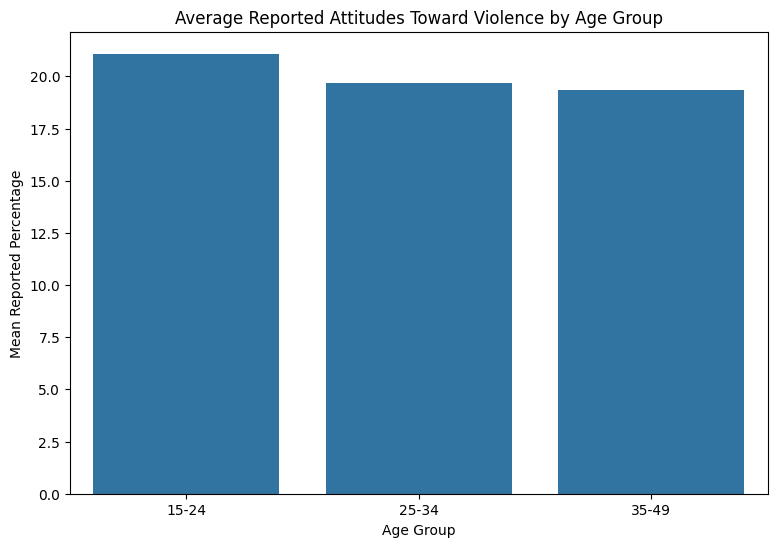

In [44]:
age_order = [
    "15-24",
    "25-34",
    "35-49"
]

plt.figure(figsize=(9, 6))

sns.barplot(
    data=age_summary.reset_index(),
    x="Demographics Response",
    y="mean_value",
    order=age_order
)

plt.title("Average Reported Attitudes Toward Violence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Reported Percentage")

plt.show()

### Interpretation

The results show relatively small differences in reported attitudes across the three age groups.

The **15–24 age group** has the highest mean reported value at approximately **21.1%**, followed by the **25–34 age group** at approximately **19.7%**. The **35–49 age group** has the lowest mean at approximately **19.3%**.

The medians follow the same general pattern, decreasing from **17.5%** among those aged 15–24 to **14.45%** among those aged 25–34 and **14.15%** among those aged 35–49.

However, the differences are relatively small. The difference between the youngest and oldest age groups is approximately **1.75 percentage points** in the mean.

### Key Insight

Unlike the education analysis, the age analysis does not show a large separation between groups.

There is a modest descriptive pattern in which younger observations have higher reported percentages, but the magnitude of the difference is small compared with the variation observed across education levels and violence-related scenarios.

This suggests that **age may be a weaker source of variation in the reported values than education**, although this cannot be determined conclusively from descriptive statistics alone.

### Missing Data

The missing-data pattern is identical across all three age groups, with **82 missing observations per group**.

This provides a relatively balanced basis for comparing the three age categories within the available observations.

### Next Analytical Step

The age pattern should be examined alongside gender, country, and violence scenario.

In particular, it is important to determine whether the small overall age difference hides larger differences within particular countries or demographic groups.

Statistical testing will later be used to determine whether the observed differences between age groups are statistically distinguishable from random variation.

## 13.7 Residence Analysis

Residence provides a geographic demographic dimension that distinguishes between respondents living in **rural** and **urban** areas.

This analysis examines whether reported attitudes toward the justification of violence differ between the two residence categories.

The comparison will use both the mean and median reported values while also considering the number of available and missing observations.

In [45]:
residence_df = df[
    df["Demographics Question"] == "Residence"
].copy()

In [46]:
residence_summary = (
    residence_df.groupby("Demographics Response")
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
)

residence_summary

,mean_value,median_value,observations,missing
Demographics Response,,,,
Rural,23.294063,19.00,758,82
Urban,15.895778,11.05,758,82


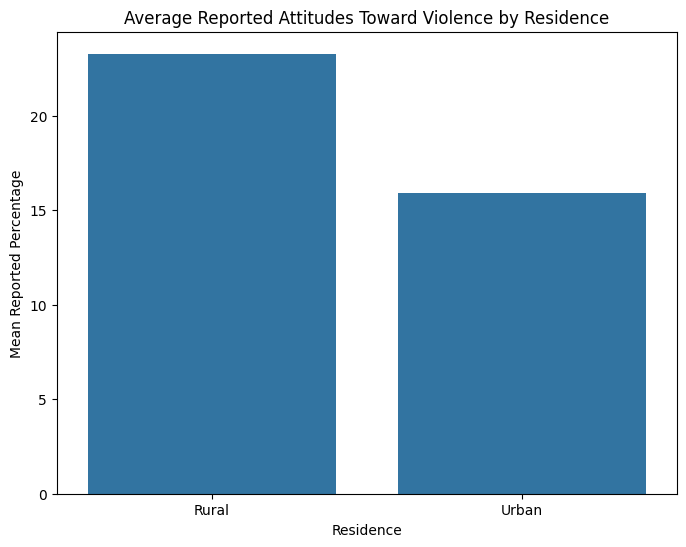

In [47]:
residence_order = [
    "Rural",
    "Urban"
]

plt.figure(figsize=(8, 6))

sns.barplot(
    data=residence_summary.reset_index(),
    x="Demographics Response",
    y="mean_value",
    order=residence_order
)

plt.title("Average Reported Attitudes Toward Violence by Residence")
plt.xlabel("Residence")
plt.ylabel("Mean Reported Percentage")

plt.show()

### Interpretation

The results show a noticeable difference in reported attitudes toward the justification of violence between rural and urban residence groups.

Observations associated with **rural areas** have an average reported value of approximately **23.3%**, compared with approximately **15.9%** for observations associated with **urban areas**.

The medians show the same pattern. The rural median is **19.0%**, while the urban median is **11.05%**.

The difference in mean reported values between rural and urban observations is approximately **7.4 percentage points**.

### Key Insight

The descriptive results indicate that reported attitudes toward the justification of violence are higher among rural observations than urban observations in this dataset.

This difference is considerably larger than the approximately **1.75 percentage-point difference observed across the youngest and oldest age groups**.

The finding therefore suggests that **residence may be a more important source of variation than age**, at least at the descriptive level.

### Missing Data

The missing-data pattern is identical for both groups:

- Rural: 82 missing observations
- Urban: 82 missing observations

Each group therefore has the same number of available observations, making the descriptive comparison balanced with respect to missing values.

### Analytical Caution

The observed rural–urban difference should not be interpreted as evidence that residence itself causes attitudes toward violence.

Country differences may be particularly important because countries can differ substantially in both their rural–urban composition and reported attitudes.

Other demographic characteristics, such as education, gender, age, employment, and marital status, may also be related to residence.

Further analysis is therefore required to determine whether the rural–urban difference remains after examining these other dimensions.

### Next Analytical Step

The next analysis will examine **employment status** to determine whether economic participation is associated with differences in reported attitudes toward the justification of violence.

## 13.8 Employment Analysis

Employment status provides another socioeconomic dimension through which reported attitudes can be examined.

The dataset contains three employment categories:

- Employed for cash
- Employed for kind
- Unemployed

This analysis examines whether reported attitudes toward the justification of violence differ across these employment groups.

Both mean and median values are considered, alongside the number of available and missing observations.

In [48]:
employment_df = df[
    df["Demographics Question"] == "Employment"
].copy()

In [49]:
employment_summary = (
    employment_df.groupby("Demographics Response")
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
    .sort_values("mean_value", ascending=False)
)

employment_summary

,mean_value,median_value,observations,missing
Demographics Response,,,,
Employed for kind,24.445541,20.15,740,100
Employed for cash,19.553804,14.85,736,104
Unemployed,19.539710,14.55,758,82


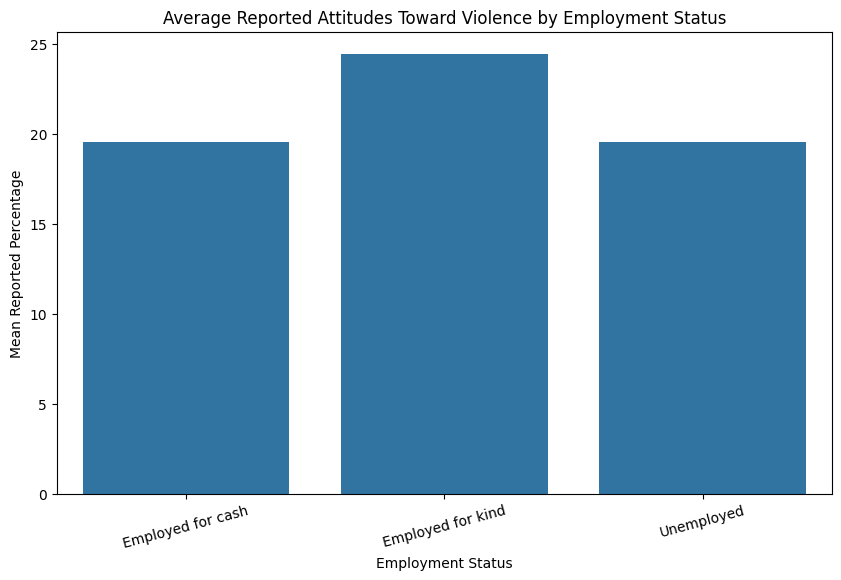

In [50]:
employment_order = [
    "Employed for cash",
    "Employed for kind",
    "Unemployed"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=employment_summary.reset_index(),
    x="Demographics Response",
    y="mean_value",
    order=employment_order
)

plt.title("Average Reported Attitudes Toward Violence by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Mean Reported Percentage")
plt.xticks(rotation=15)

plt.show()

### Interpretation

The results show some variation in reported attitudes across employment categories, although the differences are smaller than those observed for education, residence, and violence-related scenarios.

The **employed for kind** group has the highest mean reported value at approximately **24.4%**. This is followed by the **employed for cash** group at approximately **19.6%**, while the **unemployed** group has a very similar mean of approximately **19.5%**.

The median values show the same general pattern:

- Employed for kind: **20.15%**
- Employed for cash: **14.85%**
- Unemployed: **14.55%**

### Key Insight

The most noticeable difference is between the **employed for kind** group and the other two groups.

In contrast, the difference between employed for cash and unemployed observations is almost negligible, at approximately **0.01 percentage points** in the mean.

Therefore, the results do not support a simple pattern in which employment status consistently increases or decreases reported attitudes toward the justification of violence.

The type of employment may be more informative than employment status alone, although this requires further investigation.

### Missing Data

The number of missing observations differs slightly between the categories:

- Employed for kind: **100 missing**
- Employed for cash: **104 missing**
- Unemployed: **82 missing**

Although these differences are relatively modest, missingness should still be considered when conducting statistical comparisons.

### Analytical Caution

Employment status is likely related to other demographic characteristics such as education, age, gender, residence, and marital status.

Consequently, the observed differences should be interpreted as **descriptive associations**, rather than evidence that employment status itself causes differences in attitudes toward violence.

### Next Analytical Step

The final demographic dimension to examine is **marital status**.

After completing that analysis, the project will move from individual demographic comparisons to **cross-dimensional analysis**, where we investigate whether the patterns observed so far remain consistent across gender, country, and violence-related scenarios.

## 13.9 Marital Status Analysis

Marital status provides another important demographic dimension in the dataset.

The available categories are:

- Married or living together
- Never married
- Widowed, divorced, separated

This analysis examines whether reported attitudes toward the justification of violence differ across these marital-status groups.

As with the previous demographic analyses, both mean and median reported values are examined, together with the number of available and missing observations.

In [51]:
marital_df = df[
    df["Demographics Question"] == "Marital status"
].copy()

In [52]:
marital_summary = (
    marital_df.groupby("Demographics Response")
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
    .sort_values("mean_value", ascending=False)
)

marital_summary

,mean_value,median_value,observations,missing
Demographics Response,,,,
"Widowed, divorced, separated",20.683511,17.15,752,88
Married or living together,20.181003,14.80,758,82
Never married,18.704360,14.90,711,129


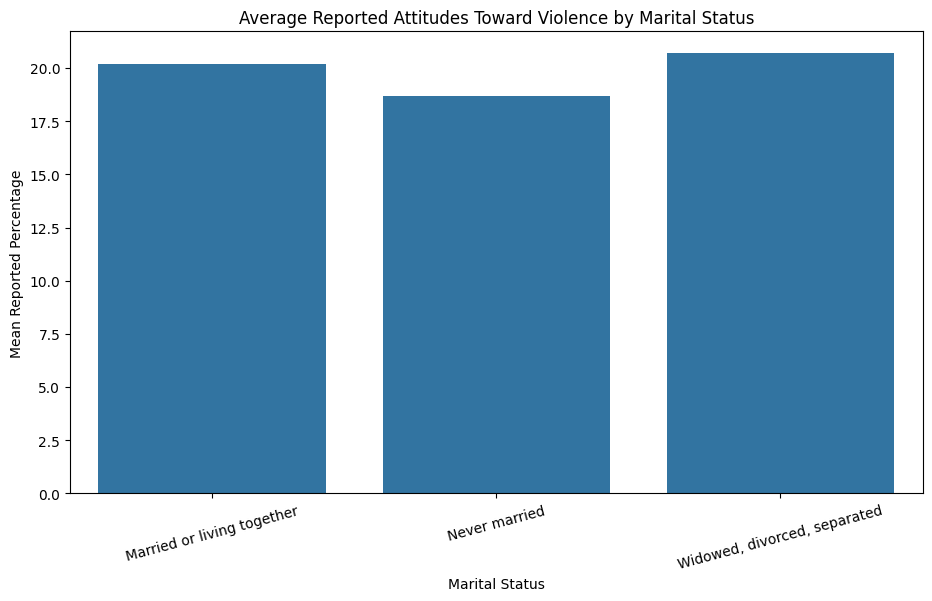

In [53]:
marital_order = [
    "Married or living together",
    "Never married",
    "Widowed, divorced, separated"
]

plt.figure(figsize=(11, 6))

sns.barplot(
    data=marital_summary.reset_index(),
    x="Demographics Response",
    y="mean_value",
    order=marital_order
)

plt.title("Average Reported Attitudes Toward Violence by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Mean Reported Percentage")
plt.xticks(rotation=15)

plt.show()

### Interpretation

The results show relatively small differences in reported attitudes toward the justification of violence across marital-status groups.

The **widowed, divorced, or separated** group has the highest mean reported value at approximately **20.7%**, followed closely by those who are **married or living together** at approximately **20.2%**.

The **never married** group has the lowest mean at approximately **18.7%**.

The median values show a similar but less pronounced pattern. The median is **17.15%** for the widowed, divorced, or separated group, **14.80%** for those who are married or living together, and **14.90%** for those who have never married.

### Key Insight

The overall differences between marital-status groups are relatively small.

The difference between the highest and lowest mean values is approximately **2.0 percentage points**, which is considerably smaller than the differences observed for education and residence.

This suggests that **marital status alone may explain relatively little of the overall variation in reported attitudes**, although this needs to be formally tested.

### Missing Data

The number of missing observations varies across the groups:

- Married or living together: **82 missing**
- Never married: **129 missing**
- Widowed, divorced, separated: **88 missing**

The never-married group therefore has somewhat more missing observations than the other two categories.

### Analytical Caution

These results are descriptive associations and should not be interpreted as evidence that marital status causes differences in attitudes.

Marital status may also be related to other demographic dimensions such as age, gender, education, employment, residence, and country.

### Summary of Demographic EDA

Across the demographic dimensions examined so far, the magnitude of variation differs considerably.

Education shows a pronounced gradient, while residence also shows a substantial difference between rural and urban observations. Gender shows a notable difference but is accompanied by substantially greater missingness among male observations.

Age, employment, and marital status show comparatively smaller differences in their overall means.

This suggests that the next stage of analysis should move beyond individual demographic variables and investigate **interactions between demographic characteristics and violence-related scenarios**.

The goal is to determine whether the patterns observed in the univariate analysis remain consistent when multiple dimensions of the dataset are examined together.

## 14. Gender × Education Analysis

The univariate analysis identified two notable patterns: reported values differed across gender groups, and there was a strong gradient across education levels.

The next step is to examine these dimensions together.

This analysis investigates whether the relationship between education level and reported attitudes toward the justification of violence is consistent across genders.

If the education pattern differs substantially between males and females, this would suggest that gender modifies the observed association between education and reported attitudes.

In [54]:
gender_education_summary = (
    df[df["Demographics Question"] == "Education"]
    .groupby(["Gender", "Demographics Response"])
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
    .reset_index()
)

gender_education_summary

,Gender,Demographics Response,mean_value,median_value,observations,missing
0,F,Higher,9.527628,4.3,409,11
1,F,No education,30.438619,28.0,391,29
2,F,Primary,26.699022,23.7,409,11
3,F,Secondary,19.399518,15.2,415,5
4,M,Higher,8.148688,4.1,343,77
5,M,No education,19.112780,15.9,313,107
6,M,Primary,17.844514,14.9,319,101
7,M,Secondary,14.934111,11.2,343,77


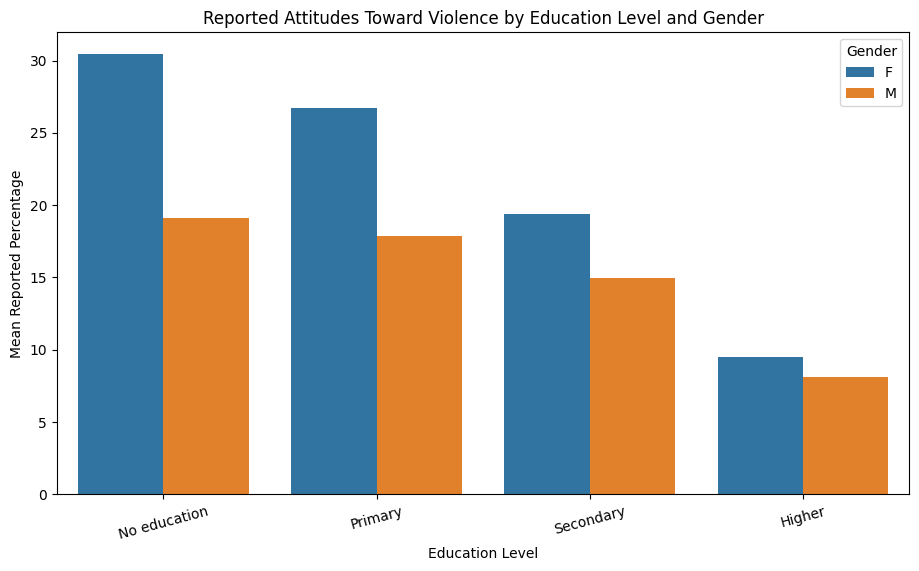

In [55]:
education_order = [
    "No education",
    "Primary",
    "Secondary",
    "Higher"
]

plt.figure(figsize=(11, 6))

sns.barplot(
    data=gender_education_summary,
    x="Demographics Response",
    y="mean_value",
    hue="Gender",
    order=education_order
)

plt.title("Reported Attitudes Toward Violence by Education Level and Gender")
plt.xlabel("Education Level")
plt.ylabel("Mean Reported Percentage")
plt.xticks(rotation=15)

plt.show()

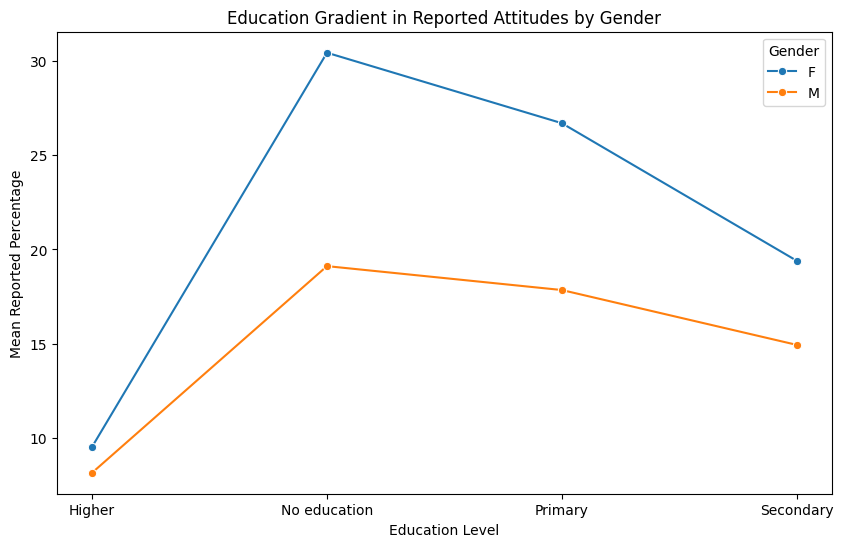

In [56]:
#line chart
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=gender_education_summary,
    x="Demographics Response",
    y="mean_value",
    hue="Gender",
    marker="o",
    sort=False
)

plt.title("Education Gradient in Reported Attitudes by Gender")
plt.xlabel("Education Level")
plt.ylabel("Mean Reported Percentage")

plt.show()

### Interpretation

The gender-by-education analysis reveals a clear and consistent education gradient in the reported values.

Among females, the mean reported value decreases from **30.44% among those with no education** to **9.53% among those with higher education**. A similar pattern appears among males, where the mean decreases from **19.11%** to **8.15%** across the same education levels.

The gender difference is also substantially larger at lower education levels. The difference between females and males is approximately **11.33 percentage points** among respondents with no education, compared with only **1.38 percentage points** among those with higher education.

This suggests that the relationship between education and reported attitudes may differ by gender, with the observed gender gap narrowing as education level increases.

However, these results are descriptive rather than causal. In addition, missing values are considerably more common among male observations, particularly for the no-education and primary-education groups. Therefore, the results should be interpreted as patterns in the available data rather than definitive estimates of the underlying populations.

The analysis also does not imply that education alone causes differences in attitudes. Country, survey context, age, residence, employment, marital status, and other social factors may contribute to the observed patterns.

## 15. Gender × Violence Scenario Analysis

The previous analysis showed differences between gender groups and education levels.

The next step is to examine whether reported attitudes differ between females and males across the six specific scenarios used to justify violence against women.

This allows us to determine whether the observed gender differences are consistent across different forms of justification or concentrated in particular scenarios.

Rather than treating violence justification as a single concept, this analysis recognizes that respondents may react differently to different situations.

In [57]:
gender_question_summary = (
    df.groupby(["Gender", "Question"])
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
    .reset_index()
)

gender_question_summary

,Gender,Question,mean_value,median_value,observations,missing
0,F,... for at least one specific reason,36.680116,36.35,1036,14
1,F,... if she argues with him,21.619284,18.25,1006,44
2,F,... if she burns the food,11.683400,8.50,1006,44
3,F,... if she goes out without telling him,23.515541,20.85,1036,14
4,F,... if she neglects the children,26.855695,26.10,1036,14
5,F,... if she refuses to have sex with him,16.823363,11.60,1023,27
6,M,... for at least one specific reason,29.011254,27.40,853,197
7,M,... if she argues with him,15.761968,13.20,823,227
8,M,... if she burns the food,6.172053,5.00,823,227
9,M,... if she goes out without telling him,15.832825,13.90,853,197


### Interpretation

The gender-by-violence-scenario analysis shows that the mean reported value for females is higher than the corresponding male value across all six violence-justification scenarios.

The size of the observed gender gap varies by scenario, ranging from approximately **5.51 percentage points** for the food-related scenario to **8.02 percentage points** for the scenario involving refusal to have sex.

The largest observed differences occur for:
- refusing to have sex with him: approximately **8.02 percentage points**
- going out without telling him: approximately **7.68 percentage points**
- at least one specific reason: approximately **7.67 percentage points**
- neglecting the children: approximately **7.52 percentage points**

This suggests that the observed difference between gender groups is not concentrated in a single scenario. Instead, a gender difference appears across all six measures in the available data.

However, the results must be interpreted alongside the substantial difference in missing observations between genders. Male observations have considerably more missing values across all scenarios. Consequently, these results describe differences among the available observations and should not automatically be interpreted as representative population-level gender differences.

The analysis is also descriptive and does not establish why the observed differences occur. Differences in country, education, age, residence, employment, marital status, survey context, and other factors may contribute to the observed patterns.

## 16. Gender Gap Across Violence-Justification Scenarios

The previous analysis showed that female and male reported values differ across all six violence-justification scenarios.

To make these differences easier to compare, we calculate the gender gap for each scenario.

The gender gap is defined here as:

**Female mean − Male mean**

A positive value indicates that the female mean is higher than the male mean in the available observations.

This measure is descriptive and should not be interpreted as a causal effect of gender.

In [58]:
gender_gap = (
    gender_question_summary
    .pivot(
        index="Question",
        columns="Gender",
        values="mean_value"
    )
    .reset_index()
)

gender_gap["gender_gap"] = gender_gap["F"] - gender_gap["M"]

gender_gap = gender_gap.sort_values(
    "gender_gap",
    ascending=False
)

gender_gap

Gender,Question,F,M,gender_gap
5,... if she refuses to have sex with him,16.823363,8.803337,8.020025
3,... if she goes out without telling him,23.515541,15.832825,7.682715
0,... for at least one specific reason,36.680116,29.011254,7.668861
4,... if she neglects the children,26.855695,19.338570,7.517125
1,... if she argues with him,21.619284,15.761968,5.857316
2,... if she burns the food,11.683400,6.172053,5.511346


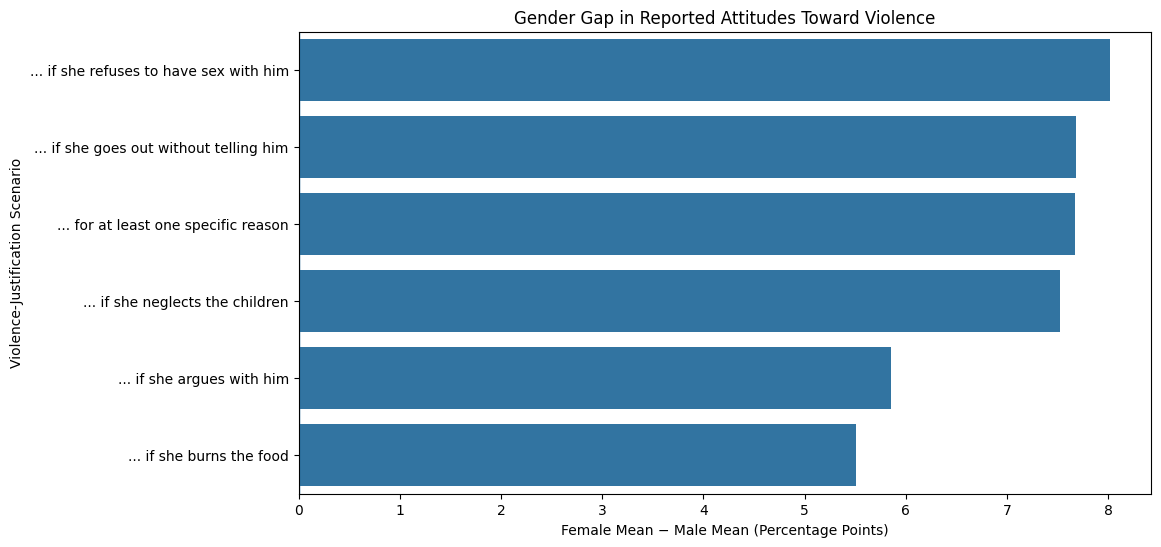

In [59]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=gender_gap,
    x="gender_gap",
    y="Question"
)

plt.axvline(0, linewidth=1)

plt.title("Gender Gap in Reported Attitudes Toward Violence")
plt.xlabel("Female Mean − Male Mean (Percentage Points)")
plt.ylabel("Violence-Justification Scenario")

plt.show()

In [60]:
gender_gap["gender_gap"].describe()

count    6.000000
mean     7.042898
std      1.070712
min      5.511346
25%      6.272268
50%      7.592993
75%      7.679252
max      8.020025
Name: gender_gap, dtype: float64

### Interpretation of the Gender Gap

The gender-gap analysis shows a positive difference between female and male mean reported values across all six violence-justification scenarios.

The average gender gap across the six scenarios is approximately **7.04 percentage points**. The smallest observed gap is **5.51 percentage points** for the scenario involving burning food, while the largest is **8.02 percentage points** for the scenario involving refusal to have sex.

The relatively narrow range of the gaps suggests that the observed difference between the two gender groups is present across multiple scenarios rather than being concentrated in a single justification.

However, this analysis should be interpreted as a descriptive comparison of aggregate reported values. It does not establish why the differences exist or imply that gender itself causes the observed differences.

The substantial amount of missing data among male observations is also an important limitation. Therefore, the calculated gaps represent differences in the available observations and may not fully represent the underlying populations.

## 17. Country × Violence-Justification Analysis

The previous country-level analysis showed substantial variation in the overall reported values across countries.

However, an overall country average can hide important differences between specific violence-justification scenarios.

This analysis therefore examines reported values at the intersection of **country and violence-justification scenario**.

The objective is to identify whether countries exhibit similar patterns across the six scenarios or whether particular scenarios contribute disproportionately to the observed country-level differences.

Because each country in this dataset is represented by a single survey year, this analysis should be interpreted as a cross-country comparison rather than a longitudinal analysis of changes within countries.

In [61]:
country_question_summary = (
    df.groupby(["Country", "Question"])
    .agg(
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        observations=("Value", "count"),
        missing=("Value", lambda x: x.isna().sum())
    )
    .reset_index()
)

country_question_summary.head(20)

,Country,Question,mean_value,median_value,observations,missing
0,Afghanistan,... for at least one specific reason,73.203571,74.05,28,2
1,Afghanistan,... if she argues with him,49.582143,49.00,28,2
2,Afghanistan,... if she burns the food,12.264286,10.65,28,2
3,Afghanistan,... if she goes out without telling him,60.310714,62.30,28,2
4,Afghanistan,... if she neglects the children,36.425000,32.60,28,2
5,Afghanistan,... if she refuses to have sex with him,24.314286,24.90,28,2
6,Albania,... for at least one specific reason,10.883333,10.45,30,0
7,Albania,... if she argues with him,4.046667,3.30,30,0
8,Albania,... if she burns the food,0.883333,0.60,30,0
9,Albania,... if she goes out without telling him,6.356667,5.65,30,0


## 18. Country × Violence-Justification Heatmap

To examine the multidimensional structure of the dataset, the country-level scenario estimates are reshaped into a matrix.

Each row represents a country, while each column represents one of the six violence-justification scenarios. The cell values represent the mean reported percentage for that country and scenario.

Sorting countries according to their overall mean across the six scenarios allows broad cross-country patterns to be compared while preserving the differences between individual scenarios.

This visualization should be interpreted as a descriptive comparison of reported aggregate estimates. It does not establish that countries themselves cause the observed differences, nor does it imply that all countries were surveyed under identical conditions.

In [62]:
country_question_matrix = (
    country_question_summary
    .pivot(
        index="Country",
        columns="Question",
        values="mean_value"
    )
)

# Calculate each country's average across the six scenarios
country_question_matrix["Overall Mean"] = country_question_matrix.mean(axis=1)

# Sort countries by overall mean
country_question_matrix = country_question_matrix.sort_values(
    "Overall Mean",
    ascending=False
)

country_question_matrix.head()

Question,... for at least one specific reason,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him,Overall Mean
Country,,,,,,,
Timor-Leste,64.236667,45.190000,25.566667,55.470000,55.010000,31.786667,46.210000
Eritrea,67.660000,41.153333,27.713333,47.613333,48.933333,44.046667,46.186667
Morocco,61.740000,49.020000,23.226667,47.680000,47.726667,41.886667,45.213333
Tajikistan,61.653333,50.420000,29.093333,49.733333,48.806667,26.120000,44.304444
Afghanistan,73.203571,49.582143,12.264286,60.310714,36.425000,24.314286,42.683333


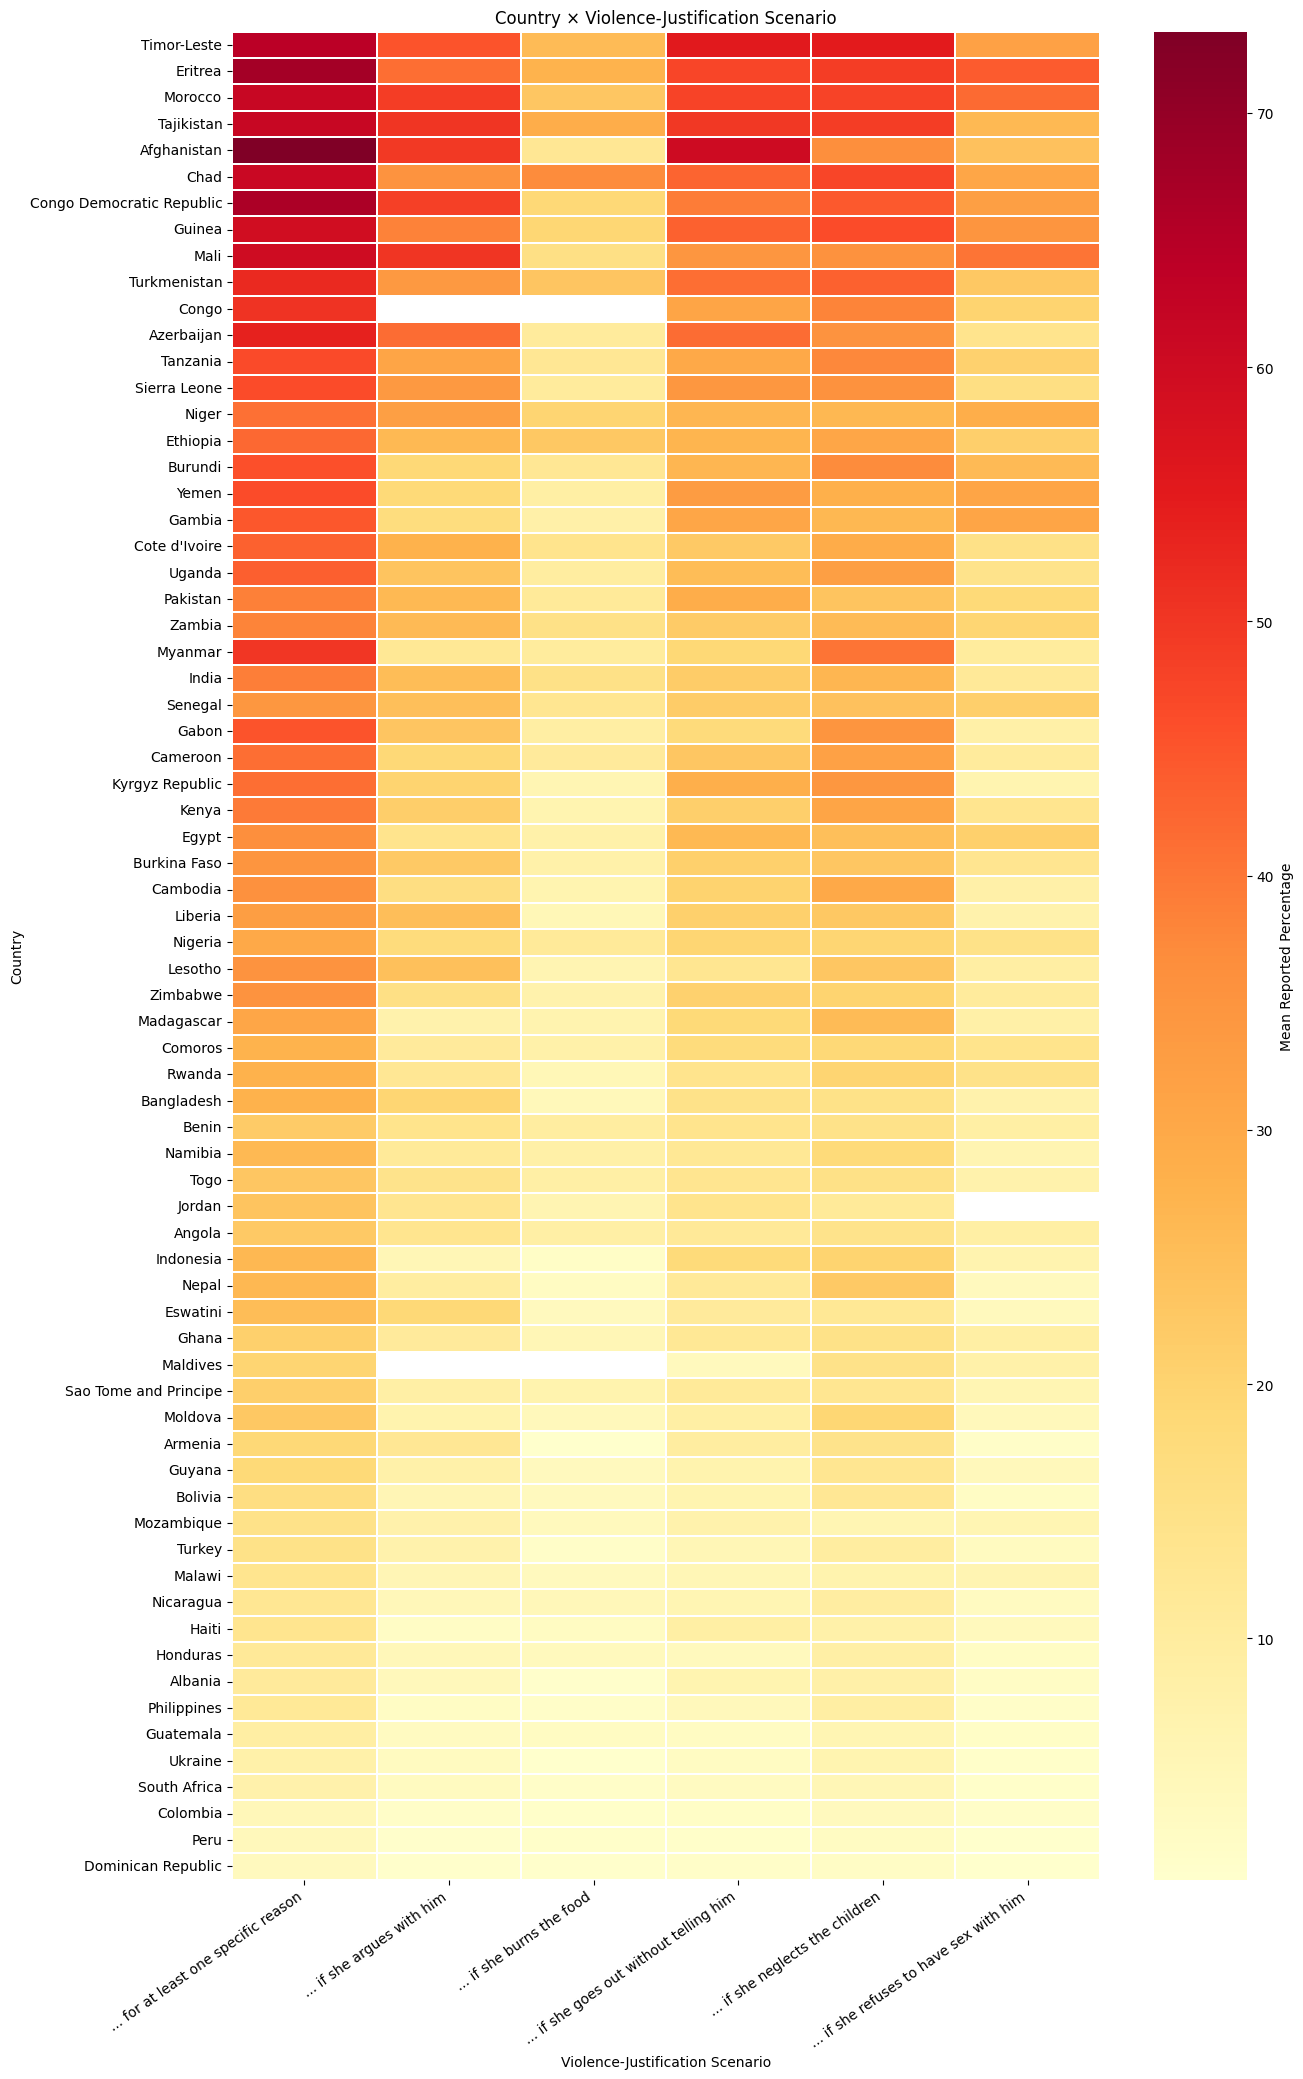

In [63]:
heatmap_data = country_question_matrix.drop(
    columns="Overall Mean"
)

plt.figure(figsize=(14, 24))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "Mean Reported Percentage"}
)

plt.title("Country × Violence-Justification Scenario")
plt.xlabel("Violence-Justification Scenario")
plt.ylabel("Country")

plt.xticks(rotation=35, ha="right")

plt.show()

## 19. Specific Violence-Justification Profile by Country

The dataset contains five specific violence-justification scenarios and one broader measure representing acceptance for at least one specific reason.

Because the broader measure is a composite indicator, it is not directly comparable to the individual scenarios when identifying the most prominent specific justification.

Therefore, this analysis focuses on the five individual scenarios:

- arguing with him
- burning the food
- going out without telling him
- neglecting the children
- refusing to have sex with him

The objective is to identify which specific justification has the highest reported value within each country.

This provides a more meaningful comparison of country-level violence-justification profiles.

In [64]:
specific_questions = [
    "... if she argues with him",
    "... if she burns the food",
    "... if she goes out without telling him",
    "... if she neglects the children",
    "... if she refuses to have sex with him"
]

specific_scenarios = country_question_summary[
    country_question_summary["Question"].isin(specific_questions)
]

specific_matrix = (
    specific_scenarios
    .pivot(
        index="Country",
        columns="Question",
        values="mean_value"
    )
)

specific_matrix.head()

Question,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him
Country,,,,,
Afghanistan,49.582143,12.264286,60.310714,36.425000,24.314286
Albania,4.046667,0.883333,6.356667,8.173333,2.163333
Angola,13.310000,8.526667,11.510000,14.206667,9.020000
Armenia,12.396429,0.517857,9.825000,14.392857,1.642857
Azerbaijan,41.428571,10.596429,41.471429,35.157143,13.682143


In [65]:
country_top_specific = (
    specific_matrix
    .idxmax(axis=1)
    .reset_index()
)

country_top_specific.columns = [
    "Country",
    "Highest Specific Scenario"
]

country_top_specific.head(20)

,Country,Highest Specific Scenario
0,Afghanistan,... if she goes out without telling him
1,Albania,... if she neglects the children
2,Angola,... if she neglects the children
3,Armenia,... if she neglects the children
4,Azerbaijan,... if she goes out without telling him
5,Bangladesh,... if she argues with him
6,Benin,... if she neglects the children
7,Bolivia,... if she neglects the children
8,Burkina Faso,... if she neglects the children
9,Burundi,... if she neglects the children


In [66]:
top_specific_counts = (
    country_top_specific["Highest Specific Scenario"]
    .value_counts()
    .reset_index()
)

top_specific_counts.columns = [
    "Scenario",
    "Number of Countries"
]

top_specific_counts

,Scenario,Number of Countries
0,... if she neglects the children,48
1,... if she argues with him,12
2,... if she goes out without telling him,9
3,... if she refuses to have sex with him,1


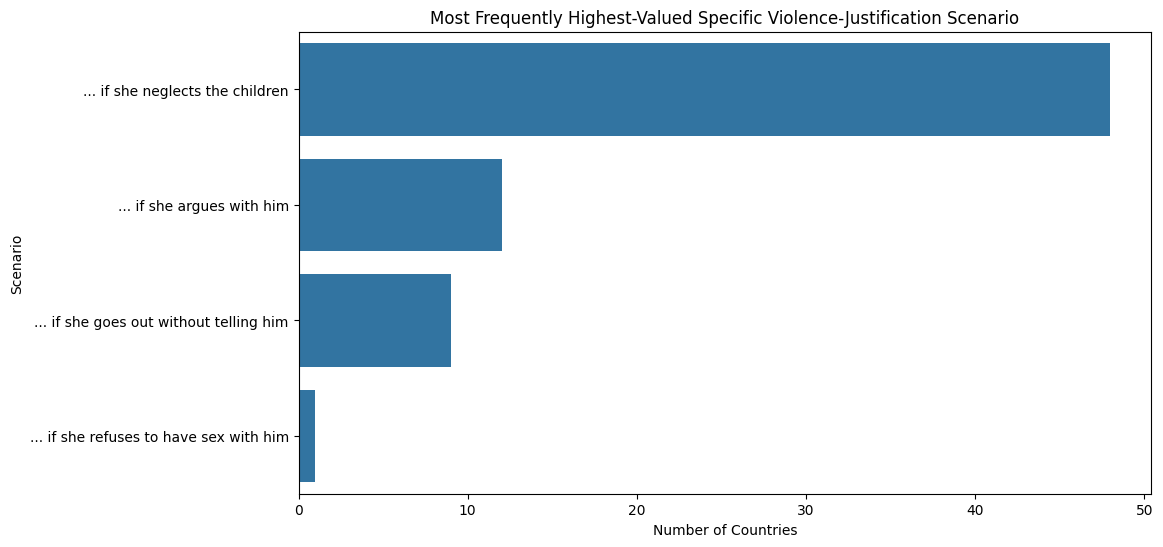

In [67]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_specific_counts,
    x="Number of Countries",
    y="Scenario"
)

plt.title(
    "Most Frequently Highest-Valued Specific Violence-Justification Scenario"
)

plt.xlabel("Number of Countries")
plt.ylabel("Scenario")

plt.show()

## 20. Country-Specific Scenario Patterns

Identifying the highest-valued scenario within each country provides only a partial picture.

A country may have relatively similar values across all scenarios, while another country may have a much stronger concentration in one or two specific scenarios.

To capture these differences, we compare each country's scenario values with the overall mean for each scenario.

This allows us to identify countries whose violence-justification profiles differ substantially from the broader cross-country pattern.

The analysis remains descriptive and does not imply that these patterns are caused by country-level characteristics.

In [68]:
scenario_overall_means = specific_matrix.mean(axis=0)

scenario_deviation = specific_matrix.subtract(
    scenario_overall_means,
    axis="columns"
)

scenario_deviation.head()

Question,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him
Country,,,,,
Afghanistan,30.522433,2.935015,39.994684,12.911997,10.848991
Albania,-15.013043,-8.445938,-13.959363,-15.339670,-11.301961
Angola,-5.749710,-0.802604,-8.806030,-9.306336,-4.445295
Armenia,-6.663281,-8.811414,-10.491030,-9.120146,-11.822437
Azerbaijan,22.368861,1.267158,21.155399,11.644140,0.216848


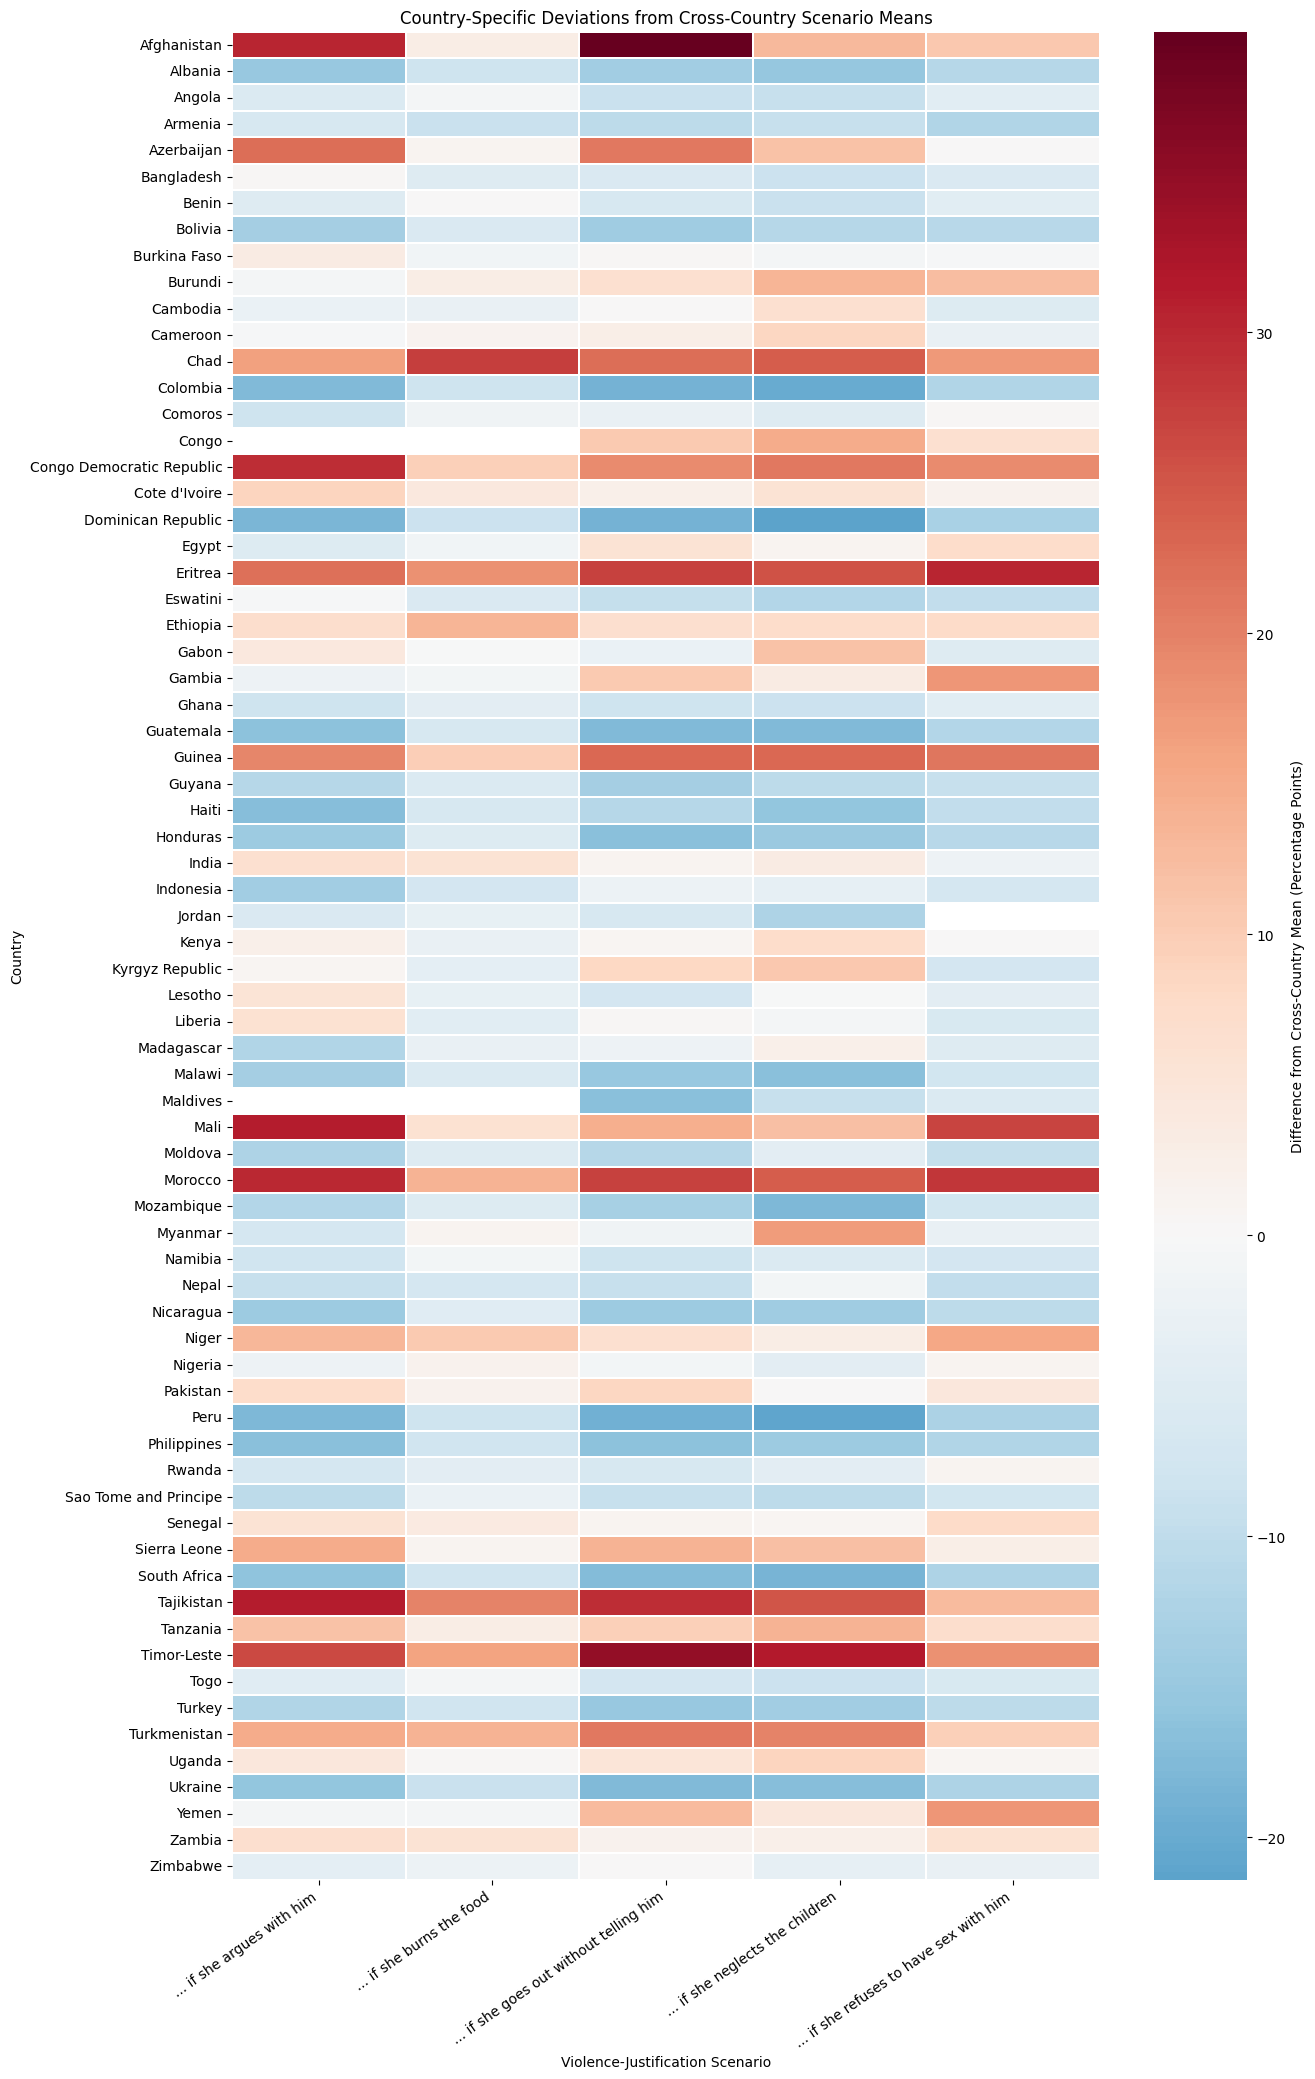

In [69]:
plt.figure(figsize=(14, 24))

sns.heatmap(
    scenario_deviation.sort_index(),
    center=0,
    cmap="RdBu_r",
    linewidths=0.3,
    cbar_kws={"label": "Difference from Cross-Country Mean (Percentage Points)"}
)

plt.title(
    "Country-Specific Deviations from Cross-Country Scenario Means"
)

plt.xlabel("Violence-Justification Scenario")
plt.ylabel("Country")

plt.xticks(rotation=35, ha="right")

plt.show()

### Interpretation

The country-level analysis shows that the five specific violence-justification scenarios do not contribute equally to country-level profiles.

The scenario involving **neglecting the children** has the highest reported mean among the five specific scenarios in **48 of the 70 countries**. The scenario involving arguing with him is highest in 12 countries, while going out without telling him is highest in 9 countries. Refusing to have sex with him is highest in only one country, and burning the food is not the highest-valued specific scenario in any country.

This indicates that the relative prominence of different violence-justification scenarios varies across countries, although some scenarios appear more frequently at the top of country profiles.

The deviation heatmap provides an additional perspective by comparing each country's scenario-specific value with the corresponding cross-country mean. Several countries show consistently positive deviations across multiple scenarios, while others show consistently negative deviations.

These patterns should be interpreted as differences in reported aggregate survey estimates rather than inherent characteristics of countries or their populations. Countries in this dataset are represented by different survey years, and missing observations are not evenly distributed across all country-scenario combinations.

The analysis therefore identifies cross-country patterns in the available data but does not establish causal explanations for those differences.

## 21. Statistical Analysis of Violence-Justification Scenarios

The descriptive analysis indicates that the five specific violence-justification scenarios have different reported values across countries.

To determine whether these differences are statistically detectable, a Friedman test is used.

The Friedman test is appropriate because each country contributes a value for multiple scenarios, meaning that the scenario observations are paired within countries.

The analysis focuses only on the five specific scenarios and excludes the composite "at least one specific reason" measure.

The null hypothesis is that the distributions of the five scenario values are the same across countries.

A statistically significant result would indicate that at least one scenario tends to have systematically different values from the others. It would not, by itself, identify which scenarios differ or establish a causal explanation.

In [70]:
from scipy.stats import friedmanchisquare

# Keep only countries with complete values for all five scenarios
friedman_data = specific_matrix.dropna()

friedman_result = friedmanchisquare(
    friedman_data["... if she argues with him"],
    friedman_data["... if she burns the food"],
    friedman_data["... if she goes out without telling him"],
    friedman_data["... if she neglects the children"],
    friedman_data["... if she refuses to have sex with him"]
)

friedman_result

FriedmanchisquareResult(statistic=np.float64(178.0059701492537), pvalue=np.float64(1.9987184565018873e-37))

In [71]:
friedman_data.shape

(67, 5)

### Friedman Test Results

The Friedman test produced a test statistic of **178.01** with a p-value of approximately **2.00 × 10⁻³⁷** based on 67 countries with complete observations across all five specific scenarios.

Because the p-value is substantially below the 0.05 significance threshold, the null hypothesis is rejected.

This provides strong statistical evidence that the reported values are not distributed equally across the five violence-justification scenarios. In other words, the differences observed in the descriptive analysis are statistically detectable across the countries included in the complete-case analysis.

However, the Friedman test only establishes that differences exist somewhere among the five scenarios. It does not identify which pairs of scenarios differ.

Therefore, post-hoc pairwise analysis is required to determine where the differences occur.

## 22. Post-Hoc Pairwise Comparisons

The Friedman test established that statistically significant differences exist among the five specific violence-justification scenarios.

To identify where these differences occur, pairwise Wilcoxon signed-rank tests are conducted between each pair of scenarios.

The Wilcoxon signed-rank test is appropriate because the scenario values are paired within countries.

Because ten pairwise comparisons are performed, a Bonferroni correction is applied to control the family-wise error rate.

The corrected significance threshold is:

**0.05 / 10 = 0.005**

A pairwise comparison with an adjusted p-value below 0.05 will be considered statistically significant after correction.

In [72]:
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests

scenario_columns = specific_matrix.columns.tolist()

pairwise_results = []

for scenario_1, scenario_2 in combinations(scenario_columns, 2):
    
    pair_data = friedman_data[
        [scenario_1, scenario_2]
    ].dropna()
    
    statistic, p_value = wilcoxon(
        pair_data[scenario_1],
        pair_data[scenario_2]
    )
    
    pairwise_results.append({
        "Scenario 1": scenario_1,
        "Scenario 2": scenario_2,
        "Statistic": statistic,
        "p_value": p_value,
        "n_pairs": len(pair_data)
    })

pairwise_results = pd.DataFrame(pairwise_results)

pairwise_results

,Scenario 1,Scenario 2,Statistic,p_value,n_pairs
0,... if she argues with him,... if she burns the food,23.0,3.141222e-12,67
1,... if she argues with him,... if she goes out without telling him,852.0,7.300694e-02,67
2,... if she argues with him,... if she neglects the children,389.0,2.799814e-06,67
3,... if she argues with him,... if she refuses to have sex with him,286.0,9.908781e-08,67
4,... if she burns the food,... if she goes out without telling him,0.0,1.119700e-12,67
5,... if she burns the food,... if she neglects the children,0.0,1.119700e-12,67
6,... if she burns the food,... if she refuses to have sex with him,391.0,2.975685e-06,67
7,... if she goes out without telling him,... if she neglects the children,318.0,2.920658e-07,67
8,... if she goes out without telling him,... if she refuses to have sex with him,62.0,1.724399e-11,67
9,... if she neglects the children,... if she refuses to have sex with him,43.0,7.577189e-12,67


In [73]:
reject, p_adjusted, _, _ = multipletests(
    pairwise_results["p_value"],
    method="bonferroni"
)

pairwise_results["adjusted_p_value"] = p_adjusted
pairwise_results["significant"] = reject

pairwise_results.sort_values(
    "adjusted_p_value"
)

,Scenario 1,Scenario 2,Statistic,p_value,n_pairs,adjusted_p_value,significant
5,... if she burns the food,... if she neglects the children,0.0,1.119700e-12,67,1.119700e-11,True
4,... if she burns the food,... if she goes out without telling him,0.0,1.119700e-12,67,1.119700e-11,True
0,... if she argues with him,... if she burns the food,23.0,3.141222e-12,67,3.141222e-11,True
9,... if she neglects the children,... if she refuses to have sex with him,43.0,7.577189e-12,67,7.577189e-11,True
8,... if she goes out without telling him,... if she refuses to have sex with him,62.0,1.724399e-11,67,1.724399e-10,True
3,... if she argues with him,... if she refuses to have sex with him,286.0,9.908781e-08,67,9.908781e-07,True
7,... if she goes out without telling him,... if she neglects the children,318.0,2.920658e-07,67,2.920658e-06,True
2,... if she argues with him,... if she neglects the children,389.0,2.799814e-06,67,2.799814e-05,True
6,... if she burns the food,... if she refuses to have sex with him,391.0,2.975685e-06,67,2.975685e-05,True
1,... if she argues with him,... if she goes out without telling him,852.0,7.300694e-02,67,7.300694e-01,False


In [74]:
pairwise_results[
    [
        "Scenario 1",
        "Scenario 2",
        "n_pairs",
        "p_value",
        "adjusted_p_value",
        "significant"
    ]
].sort_values("adjusted_p_value")

,Scenario 1,Scenario 2,n_pairs,p_value,adjusted_p_value,significant
5,... if she burns the food,... if she neglects the children,67,1.119700e-12,1.119700e-11,True
4,... if she burns the food,... if she goes out without telling him,67,1.119700e-12,1.119700e-11,True
0,... if she argues with him,... if she burns the food,67,3.141222e-12,3.141222e-11,True
9,... if she neglects the children,... if she refuses to have sex with him,67,7.577189e-12,7.577189e-11,True
8,... if she goes out without telling him,... if she refuses to have sex with him,67,1.724399e-11,1.724399e-10,True
3,... if she argues with him,... if she refuses to have sex with him,67,9.908781e-08,9.908781e-07,True
7,... if she goes out without telling him,... if she neglects the children,67,2.920658e-07,2.920658e-06,True
2,... if she argues with him,... if she neglects the children,67,2.799814e-06,2.799814e-05,True
6,... if she burns the food,... if she refuses to have sex with him,67,2.975685e-06,2.975685e-05,True
1,... if she argues with him,... if she goes out without telling him,67,7.300694e-02,7.300694e-01,False


### Post-Hoc Pairwise Results

The post-hoc Wilcoxon signed-rank tests show that **9 of the 10 pairwise comparisons remain statistically significant after Bonferroni correction**.

The only comparison that does not show a statistically significant difference is the comparison between **arguing with him** and **going out without telling him**, which has an adjusted p-value of approximately **0.730**.

This indicates that, among the 67 countries with complete observations, the reported values for these two scenarios are statistically similar relative to the other scenario comparisons.

The remaining scenario pairs show statistically significant differences after controlling for multiple comparisons.

These findings provide more detail than the Friedman test alone: the overall test established that differences exist among the five scenarios, while the post-hoc analysis identifies the specific pairs for which those differences are statistically detectable.

Statistical significance does not by itself indicate the magnitude or practical importance of the differences. Therefore, effect sizes are examined next.

## 23. Effect Size of Scenario Differences

Statistical significance indicates that differences exist among the violence-justification scenarios, but it does not indicate how large those differences are.

To quantify the magnitude of the overall difference, Kendall's W is calculated from the Friedman test.

Kendall's W ranges from 0 to 1:

- values closer to 0 indicate weak agreement or small differences in the rankings;
- values closer to 1 indicate strong agreement or substantial systematic differences.

Kendall's W is interpreted here as an effect-size measure for the repeated-measures comparison.

In [75]:
n_countries = friedman_data.shape[0]
n_scenarios = friedman_data.shape[1]

friedman_statistic = friedman_result.statistic

kendalls_w = (
    friedman_statistic /
    (n_countries * (n_scenarios - 1))
)

kendalls_w

np.float64(0.6642013811539317)

In [76]:
def paired_rank_biserial(x, y):
    differences = x - y
    differences = differences[differences != 0]

    ranks = differences.abs().rank()

    positive_ranks = ranks[differences > 0].sum()
    negative_ranks = ranks[differences < 0].sum()

    return (
        (positive_ranks - negative_ranks) /
        (positive_ranks + negative_ranks)
    )

In [77]:
pairwise_effects = []

for scenario_1, scenario_2 in combinations(scenario_columns, 2):

    pair_data = friedman_data[
        [scenario_1, scenario_2]
    ].dropna()

    effect = paired_rank_biserial(
        pair_data[scenario_1],
        pair_data[scenario_2]
    )

    pairwise_effects.append({
        "Scenario 1": scenario_1,
        "Scenario 2": scenario_2,
        "rank_biserial": effect
    })

pairwise_effects = pd.DataFrame(pairwise_effects)

pairwise_effects

,Scenario 1,Scenario 2,rank_biserial
0,... if she argues with him,... if she burns the food,0.979807
1,... if she argues with him,... if she goes out without telling him,-0.251975
2,... if she argues with him,... if she neglects the children,-0.658472
3,... if she argues with him,... if she refuses to have sex with him,0.748903
4,... if she burns the food,... if she goes out without telling him,-1.000000
5,... if she burns the food,... if she neglects the children,-1.000000
6,... if she burns the food,... if she refuses to have sex with him,-0.656716
7,... if she goes out without telling him,... if she neglects the children,-0.720808
8,... if she goes out without telling him,... if she refuses to have sex with him,0.945566
9,... if she neglects the children,... if she refuses to have sex with him,0.962248


In [78]:
pairwise_results_with_effects = (
    pairwise_results
    .merge(
        pairwise_effects,
        on=["Scenario 1", "Scenario 2"]
    )
    .sort_values("adjusted_p_value")
)

pairwise_results_with_effects

,Scenario 1,Scenario 2,Statistic,p_value,n_pairs,adjusted_p_value,significant,rank_biserial
5,... if she burns the food,... if she neglects the children,0.0,1.119700e-12,67,1.119700e-11,True,-1.000000
4,... if she burns the food,... if she goes out without telling him,0.0,1.119700e-12,67,1.119700e-11,True,-1.000000
0,... if she argues with him,... if she burns the food,23.0,3.141222e-12,67,3.141222e-11,True,0.979807
9,... if she neglects the children,... if she refuses to have sex with him,43.0,7.577189e-12,67,7.577189e-11,True,0.962248
8,... if she goes out without telling him,... if she refuses to have sex with him,62.0,1.724399e-11,67,1.724399e-10,True,0.945566
3,... if she argues with him,... if she refuses to have sex with him,286.0,9.908781e-08,67,9.908781e-07,True,0.748903
7,... if she goes out without telling him,... if she neglects the children,318.0,2.920658e-07,67,2.920658e-06,True,-0.720808
2,... if she argues with him,... if she neglects the children,389.0,2.799814e-06,67,2.799814e-05,True,-0.658472
6,... if she burns the food,... if she refuses to have sex with him,391.0,2.975685e-06,67,2.975685e-05,True,-0.656716
1,... if she argues with him,... if she goes out without telling him,852.0,7.300694e-02,67,7.300694e-01,False,-0.251975


### Effect Size Results

The overall effect size from the Friedman analysis was estimated using Kendall's W.

Kendall's W was approximately **0.664**, indicating a substantial systematic difference in the country-level rankings of the five violence-justification scenarios.

The pairwise rank-biserial correlations provide additional information about the direction and magnitude of individual scenario differences.

Several comparisons show very large effects. For example, the rank-biserial correlation between the scenarios involving burning the food and neglecting the children is **−1.00**, indicating that the reported value for burning the food was lower than the value for neglecting the children in all 67 complete countries. A similar pattern occurs when burning the food is compared with going out without telling him.

Other comparisons also show strong effects, including:
- arguing with him vs. burning the food: **0.980**
- neglecting the children vs. refusing to have sex: **0.962**
- going out without telling him vs. refusing to have sex: **0.946**

The only pairwise comparison that was not statistically significant was arguing with him versus going out without telling him, which had an adjusted p-value of **0.730** and a rank-biserial correlation of approximately **−0.252**.

The sign of the rank-biserial correlation indicates the direction of the difference according to the order in which the two scenarios were compared. The magnitude indicates the strength of the paired difference.

These effect sizes describe systematic differences in reported aggregate values across countries. They should not be interpreted as causal effects.

## 24. Country Profile Clustering

The previous analyses identified substantial differences between countries across the five specific violence-justification scenarios.

The next step is to determine whether countries can be grouped according to similarities in their scenario profiles.

For this analysis, each country is represented by five features corresponding to the mean reported value for each specific violence-justification scenario.

Clustering is used as an exploratory technique to identify groups of countries with similar patterns across these five measures.

The resulting clusters should be interpreted as statistical profiles rather than as definitive social or cultural categories.

In [79]:
clustering_data = specific_matrix.dropna().copy()

clustering_data.shape

(67, 5)

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster = scaler.fit_transform(clustering_data)

X_cluster.shape

(67, 5)

In [81]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_cluster)
    inertia.append(model.inertia_)

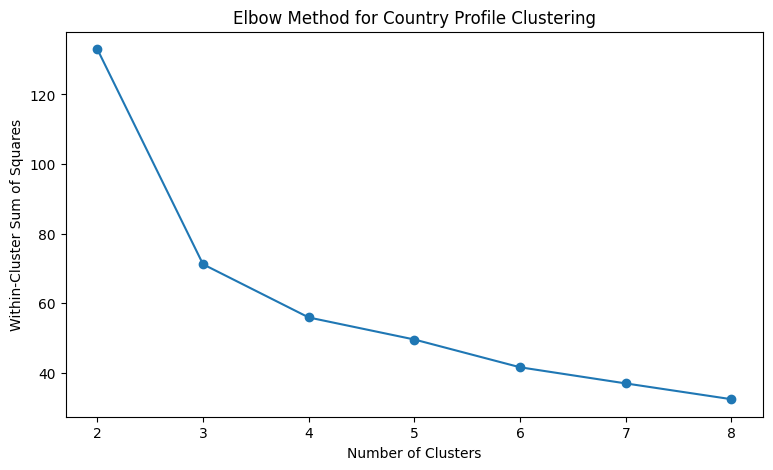

In [82]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Country Profile Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")

plt.show()

## 25. Selecting the Number of Country Profiles

The elbow method shows a substantial reduction in within-cluster variation when increasing the number of clusters from two to three, followed by progressively smaller improvements.

This suggests that three clusters may provide a reasonable balance between reducing within-cluster variation and avoiding unnecessary fragmentation.

However, the elbow method is partly subjective. Therefore, silhouette scores are also calculated for candidate cluster solutions.

The silhouette score measures how well each observation fits within its assigned cluster relative to other clusters. Higher values indicate better separation between clusters.

The final number of clusters will therefore be selected using both the elbow pattern and the silhouette results rather than relying on a single criterion.

In [83]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = model.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        cluster_labels
    )
    
    silhouette_scores.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_scores = pd.DataFrame(silhouette_scores)

silhouette_scores

,k,silhouette_score
0,2,0.494309
1,3,0.470339
2,4,0.378399
3,5,0.345447
4,6,0.348164
5,7,0.359493
6,8,0.349954


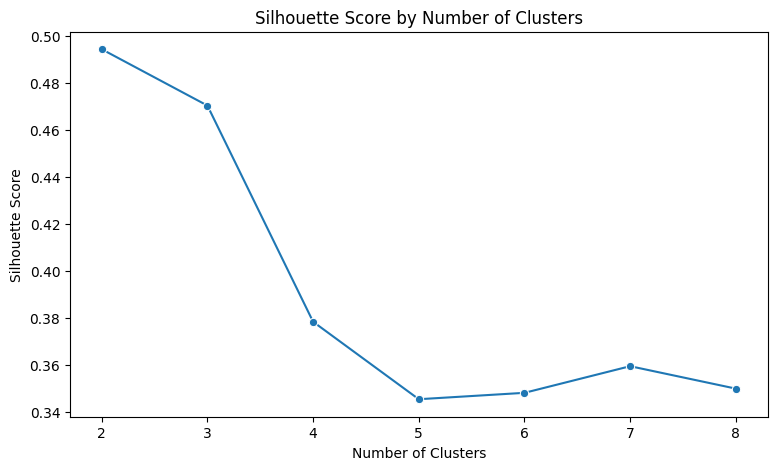

In [84]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=silhouette_scores,
    x="k",
    y="silhouette_score",
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [85]:
silhouette_scores.sort_values(
    "silhouette_score",
    ascending=False
)

,k,silhouette_score
0,2,0.494309
1,3,0.470339
2,4,0.378399
5,7,0.359493
6,8,0.349954
4,6,0.348164
3,5,0.345447


## 26. K-Means Country Profile Clustering

Based on the clustering diagnostics, two clusters provide the strongest separation among the candidate solutions.

The silhouette score is highest at **k = 2 (0.494)**, while the elbow analysis also indicates that most of the reduction in within-cluster variation occurs by the time the solution reaches two to three clusters.

The primary analysis therefore uses two clusters to represent broad country-level profiles across the five violence-justification scenarios.

These clusters are statistical groupings based only on similarity in the observed scenario values. They should not be interpreted as fixed cultural, social, or political categories.

In [86]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

clustering_results = clustering_data.copy()

clustering_results["Cluster"] = cluster_labels

clustering_results.head()

Question,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him,Cluster
Country,,,,,,
Afghanistan,49.582143,12.264286,60.310714,36.425000,24.314286,1
Albania,4.046667,0.883333,6.356667,8.173333,2.163333,0
Angola,13.310000,8.526667,11.510000,14.206667,9.020000,0
Armenia,12.396429,0.517857,9.825000,14.392857,1.642857,0
Azerbaijan,41.428571,10.596429,41.471429,35.157143,13.682143,1


## 27. Cluster Distribution

Before interpreting the clusters, we examine how many countries are assigned to each group.

This provides an initial indication of whether the clustering produces relatively balanced groups or whether one cluster contains substantially more countries than the other.

In [87]:
cluster_counts = (
    clustering_results["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Number of Countries")
)

cluster_counts

,Cluster,Number of Countries
0,0,43
1,1,24


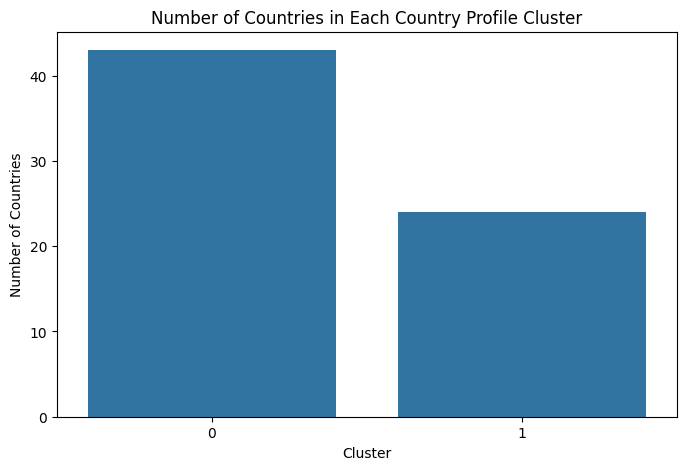

In [88]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_counts,
    x="Cluster",
    y="Number of Countries"
)

plt.title("Number of Countries in Each Country Profile Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")

plt.show()

## 28. Cluster Profiles

Cluster labels are arbitrary identifiers assigned by the K-Means algorithm.

Therefore, the numerical cluster labels themselves do not have substantive meaning.

To interpret the clusters, we compare the mean reported value for each violence-justification scenario within each cluster.

This allows us to identify the characteristic profile of each group of countries.

In [89]:
cluster_profiles = (
    clustering_results
    .groupby("Cluster")
    .mean(numeric_only=True)
)

cluster_profiles

Question,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him
Cluster,,,,,
0,10.893225,4.974793,12.075315,16.478989,6.610561
1,33.939187,17.270843,35.599206,36.395972,25.714772


In [90]:
cluster_profiles_plot = cluster_profiles.T.reset_index()

cluster_profiles_plot.columns = [
    "Scenario",
    "Cluster_0",
    "Cluster_1"
]

cluster_profiles_plot

,Scenario,Cluster_0,Cluster_1
0,... if she argues with him,10.893225,33.939187
1,... if she burns the food,4.974793,17.270843
2,... if she goes out without telling him,12.075315,35.599206
3,... if she neglects the children,16.478989,36.395972
4,... if she refuses to have sex with him,6.610561,25.714772


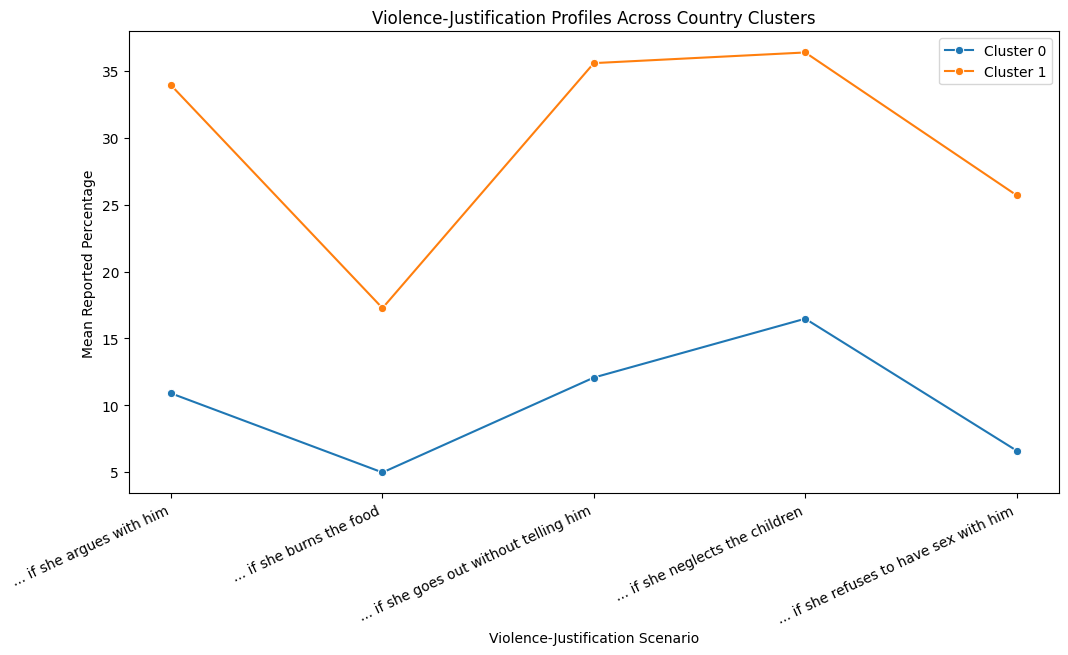

In [91]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=cluster_profiles_plot,
    x="Scenario",
    y="Cluster_0",
    marker="o",
    label="Cluster 0"
)

sns.lineplot(
    data=cluster_profiles_plot,
    x="Scenario",
    y="Cluster_1",
    marker="o",
    label="Cluster 1"
)

plt.title("Violence-Justification Profiles Across Country Clusters")
plt.xlabel("Violence-Justification Scenario")
plt.ylabel("Mean Reported Percentage")
plt.xticks(rotation=25, ha="right")

plt.show()

## 29. Interpretation of Country Profile Clusters

The K-Means analysis identified two distinct country-level profiles based on the five specific violence-justification scenarios.

Cluster 0 has lower mean reported values across all five scenarios, while Cluster 1 has substantially higher values across every scenario.

The difference between the clusters is particularly large for the scenarios involving going out without telling the husband, arguing with the husband, and neglecting the children.

The smallest difference occurs for the scenario involving burning the food, although the difference remains substantial.

Importantly, the clustering pattern is consistent across all five scenarios rather than being driven by a single variable. This suggests that the countries assigned to the two clusters differ primarily in their overall level of reported justification across these scenarios.

The cluster labels themselves have no substantive meaning. They are statistical identifiers assigned by K-Means. Therefore, the clusters are described in terms of their observed response profiles rather than being interpreted as inherently positive or negative categories.

Because the analysis uses country-level aggregate data, these clusters should be interpreted as country-level statistical profiles rather than characteristics of individuals within those countries.

## 30. Country Membership by Cluster

The next step is to identify which countries belong to each statistical profile.

This allows us to examine the geographical distribution of the clusters and determine whether countries with similar violence-justification profiles are distributed across particular regions or contexts.

Cluster membership is descriptive and should not be interpreted as a ranking of countries.

In [92]:
country_clusters = (
    clustering_results
    .reset_index()
    [["Country", "Cluster"]]
    .sort_values(["Cluster", "Country"])
)

country_clusters

Question,Country,Cluster
1,Albania,0
2,Angola,0
3,Armenia,0
5,Bangladesh,0
6,Benin,0
7,Bolivia,0
8,Burkina Faso,0
10,Cambodia,0
11,Cameroon,0
13,Colombia,0


In [93]:
cluster_counts = (
    country_clusters["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Number of Countries")
)

cluster_counts

,Cluster,Number of Countries
0,0,43
1,1,24


## Interpretation of Country Cluster Membership

The clustering analysis assigned 67 countries to two statistical profiles.

Cluster 0 contains 43 countries, while Cluster 1 contains 24 countries.

The earlier cluster-profile analysis showed that Cluster 1 has higher mean reported values across all five violence-justification scenarios, whereas Cluster 0 has lower mean values across the same scenarios.

The purpose of this clustering is not to rank countries or classify them as inherently positive or negative. Instead, it identifies groups of countries whose aggregate response patterns are more similar to one another across the selected scenarios.

It is also important to note that the clustering analysis is based on the 67 countries with complete observations across all five scenarios. Countries with missing values in one or more of these scenarios were excluded from this particular analysis.

Therefore, cluster membership represents similarity in the observed survey measures rather than a broader characterization of the countries themselves.

## 31. Distance to Cluster Centroids

K-Means assigns each country to the nearest cluster centroid.

However, countries can differ in how close they are to their assigned centroid. Examining these distances helps identify countries that are more typical of their assigned profile and countries that lie relatively close to the boundary between profiles.

This provides additional context when interpreting cluster membership.

In [94]:
# Check the current structure first
print("Index name:", clustering_results.index.name)
print("Columns:", clustering_results.columns.tolist())

Index name: Country
Columns: ['... if she argues with him', '... if she burns the food', '... if she goes out without telling him', '... if she neglects the children', '... if she refuses to have sex with him', 'Cluster']


In [95]:
# Move Country from the index into a regular column
clustering_results = clustering_results.reset_index()

clustering_results.head()

Question,Country,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him,Cluster
0,Afghanistan,49.582143,12.264286,60.310714,36.425000,24.314286,1
1,Albania,4.046667,0.883333,6.356667,8.173333,2.163333,0
2,Angola,13.310000,8.526667,11.510000,14.206667,9.020000,0
3,Armenia,12.396429,0.517857,9.825000,14.392857,1.642857,0
4,Azerbaijan,41.428571,10.596429,41.471429,35.157143,13.682143,1


In [96]:
# Calculate distances from each country to both cluster centroids
cluster_distances = kmeans.transform(X_cluster)

clustering_results["distance_to_cluster_0"] = cluster_distances[:, 0]
clustering_results["distance_to_cluster_1"] = cluster_distances[:, 1]

# Distance to the centroid of the assigned cluster
clustering_results["assigned_cluster_distance"] = (
    clustering_results[
        ["distance_to_cluster_0", "distance_to_cluster_1"]
    ]
    .min(axis=1)
)

# Countries closest to their assigned cluster centroid
typical_countries = (
    clustering_results[
        [
            "Country",
            "Cluster",
            "distance_to_cluster_0",
            "distance_to_cluster_1",
            "assigned_cluster_distance"
        ]
    ]
    .sort_values("assigned_cluster_distance")
)

typical_countries.head(10)

Question,Country,Cluster,distance_to_cluster_0,distance_to_cluster_1,assigned_cluster_distance
24,Ghana,0,0.235022,3.571433,0.235022
52,Sao Tome and Principe,0,0.403552,3.788514,0.403552
43,Namibia,0,0.434458,3.426147,0.434458
39,Moldova,0,0.481717,3.940032,0.481717
59,Togo,0,0.532723,3.322972,0.532723
2,Angola,0,0.563881,3.362292,0.563881
27,Guyana,0,0.574257,4.177805,0.574257
44,Nepal,0,0.617548,3.810191,0.617548
5,Bangladesh,0,0.658481,3.369627,0.658481
6,Benin,0,0.704926,3.199247,0.704926


In [97]:
clustering_results["cluster_distance_gap"] = (
    clustering_results[
        ["distance_to_cluster_0", "distance_to_cluster_1"]
    ]
    .max(axis=1)
    -
    clustering_results[
        ["distance_to_cluster_0", "distance_to_cluster_1"]
    ]
    .min(axis=1)
)

clustering_results[
    [
        "Country",
        "Cluster",
        "distance_to_cluster_0",
        "distance_to_cluster_1",
        "cluster_distance_gap"
    ]
].sort_values("cluster_distance_gap").head(10)

Question,Country,Cluster,distance_to_cluster_0,distance_to_cluster_1,cluster_distance_gap
30,India,1,2.005487,1.879490,0.125996
62,Uganda,1,2.003239,1.763627,0.239611
11,Cameroon,0,1.725359,2.133332,0.407973
18,Egypt,0,1.783372,2.223663,0.440292
53,Senegal,1,2.129646,1.641102,0.488544
48,Pakistan,1,2.138149,1.595273,0.542877
42,Myanmar,0,2.011242,2.575549,0.564307
22,Gabon,0,1.787506,2.381160,0.593654
16,Cote d'Ivoire,1,2.197419,1.547047,0.650372
33,Kyrgyz Republic,0,1.887013,2.552846,0.665833


## 32. Sensitivity Analysis: Three-Cluster Solution

The primary clustering analysis selected two clusters based on the highest silhouette score.

However, the elbow analysis also suggested that three clusters could provide a meaningful alternative representation.

A three-cluster solution is therefore examined as a sensitivity analysis.

The purpose is not to replace the primary two-cluster solution, but to determine whether introducing an additional cluster reveals a meaningful subgroup that is hidden within the two-cluster structure.

If the three-cluster solution produces a coherent additional profile, this may provide additional descriptive detail. If it produces poorly separated or difficult-to-interpret groups, the two-cluster solution remains the more parsimonious representation.

In [98]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels_3 = kmeans_3.fit_predict(X_cluster)

clustering_results["Cluster_3"] = cluster_labels_3

cluster_3_counts = (
    clustering_results["Cluster_3"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Number of Countries")
)

cluster_3_counts

,Cluster,Number of Countries
0,0,31
1,1,26
2,2,10


In [99]:
cluster_3_profiles = (
    clustering_results
    .groupby("Cluster_3")[clustering_data.columns]
    .mean()
)

cluster_3_profiles

Question,... if she argues with him,... if she burns the food,... if she goes out without telling him,... if she neglects the children,... if she refuses to have sex with him
Cluster_3,,,,,
0,7.691907,3.889457,8.687661,12.021231,4.872675
1,23.172868,10.624317,24.698383,29.049488,16.193518
2,44.200548,23.161095,46.214405,45.415500,32.932429


### Interpretation of the Three-Cluster Sensitivity Analysis

The three-cluster solution produced three clearly ordered country profiles containing 31, 26, and 10 countries respectively.

Across all five scenarios, Cluster 0 records the lowest mean reported percentages, Cluster 1 occupies an intermediate position, and Cluster 2 records the highest mean percentages.

For example, the mean percentage for the scenario involving arguing with the husband increases from approximately 7.7% in Cluster 0 to 23.2% in Cluster 1 and 44.2% in Cluster 2. A similar progression occurs for going out without telling the husband (8.7%, 24.7%, and 46.2%) and refusing sex (4.9%, 16.2%, and 32.9%).

This consistency indicates that the additional cluster is not being created by an isolated scenario. Instead, the three-cluster solution divides countries according to increasingly higher overall reported percentages across the five scenarios.

However, the two-cluster solution remains the primary specification because it achieved the highest silhouette score (0.494 compared with 0.470 for three clusters), indicating somewhat stronger separation between groups.

The three-cluster model therefore serves as a useful sensitivity analysis. It suggests that the broad structure identified by the two-cluster model is robust, while also showing that a more detailed specification can distinguish an intermediate country profile.

These clusters describe similarities in aggregate survey response patterns and should not be interpreted as rankings or fixed social or cultural classifications of countries.

## 33. Comparison of Three-Cluster Profiles

To examine how the three country profiles differ, the mean reported percentage for each scenario is plotted for each cluster.

This visualization helps determine whether the additional cluster represents a distinct response pattern or simply an intermediate level between the two profiles identified in the primary analysis.

In [100]:
cluster_3_plot = (
    cluster_3_profiles
    .T
    .reset_index()
    .melt(
        id_vars="Question",
        var_name="Cluster",
        value_name="Mean Percentage"
    )
)

cluster_3_plot.head()

,Question,Cluster,Mean Percentage
0,... if she argues with him,0,7.691907
1,... if she burns the food,0,3.889457
2,... if she goes out without telling him,0,8.687661
3,... if she neglects the children,0,12.021231
4,... if she refuses to have sex with him,0,4.872675


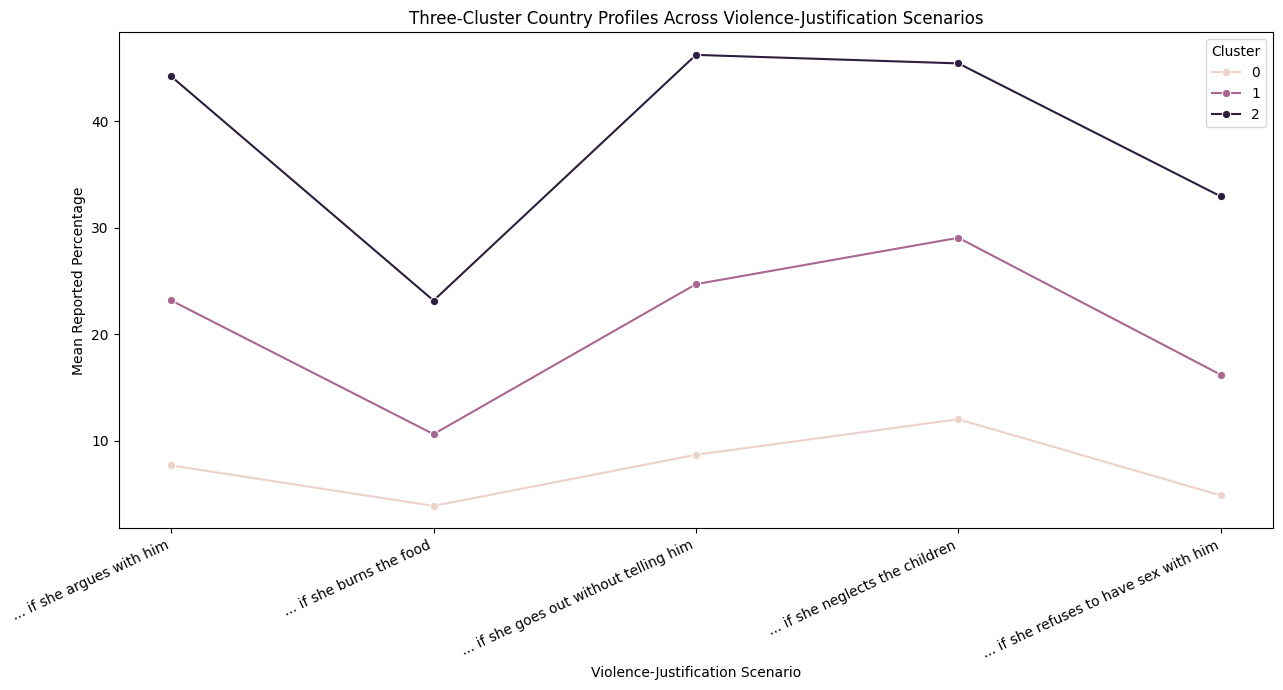

In [101]:
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=cluster_3_plot,
    x="Question",
    y="Mean Percentage",
    hue="Cluster",
    marker="o"
)

plt.title("Three-Cluster Country Profiles Across Violence-Justification Scenarios")
plt.xlabel("Violence-Justification Scenario")
plt.ylabel("Mean Reported Percentage")

plt.xticks(rotation=25, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

### Key Finding

The three cluster profiles follow broadly similar shapes across the five scenarios but differ substantially in their overall levels.

Cluster 0 consistently records the lowest reported percentages, Cluster 1 occupies an intermediate position, and Cluster 2 records the highest percentages.

The approximately parallel structure of the profiles suggests that the primary distinction between clusters is the overall level of reported justification rather than fundamentally different scenario-specific response patterns.

This reinforces the conclusion that a common underlying dimension of violence-justifying attitudes contributes strongly to the cross-country variation observed in the dataset.

# 34. Principal Component Analysis (PCA)

The clustering analysis suggests that countries differ strongly in their overall levels across the five violence-justification scenarios.

Principal Component Analysis (PCA) is used to investigate whether these five variables can be summarized by a smaller number of underlying dimensions.

PCA transforms the standardized scenario variables into new uncorrelated components that capture progressively smaller proportions of the total variation in the data.

The analysis has two main objectives:

1. Determine how much of the variation across the five scenarios can be explained by the first few principal components.
2. Visualize countries in a lower-dimensional space to examine whether the cluster structure identified by K-Means is also visible geometrically.

The same standardized complete-case country dataset used for clustering is used for PCA to ensure consistency between the analyses.

In [102]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_cluster)

explained_variance = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))
    ],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(
        pca.explained_variance_ratio_
    )
})

explained_variance

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.878638,0.878638
1,PC2,0.046149,0.924787
2,PC3,0.037025,0.961812
3,PC4,0.026144,0.987956
4,PC5,0.012044,1.000000


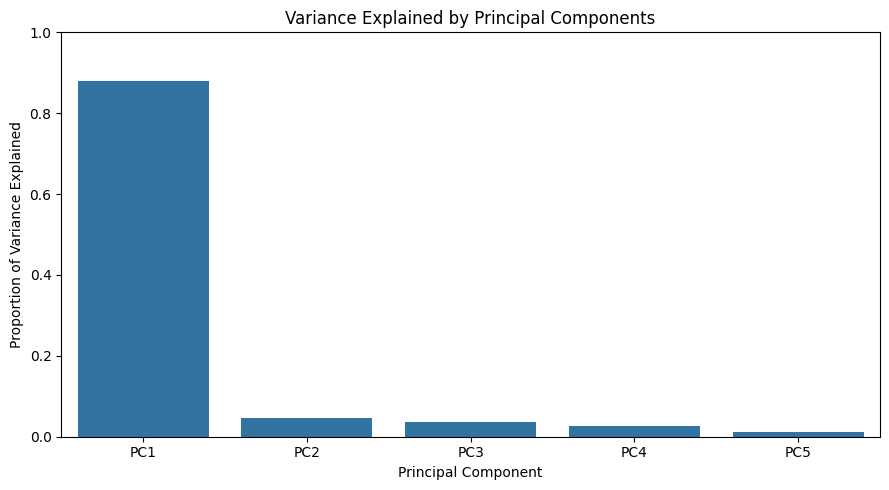

In [103]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=explained_variance,
    x="Principal Component",
    y="Explained Variance Ratio"
)

plt.title("Variance Explained by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

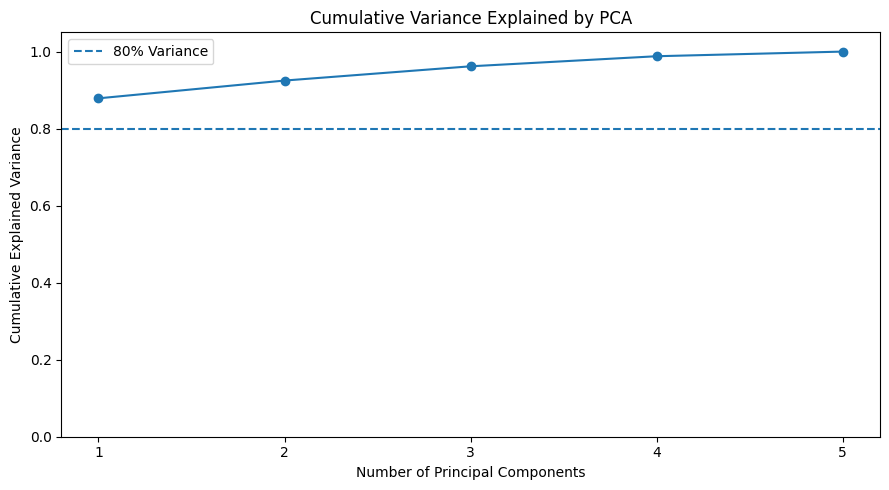

In [104]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")

plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.show()

### Interpretation of Explained Variance

The PCA results show that the first principal component (PC1) explains approximately **87.9% of the total variance** across the five violence-justification scenarios.

The second principal component (PC2) explains an additional **4.6%**, bringing the cumulative variance explained by the first two components to approximately **92.5%**.

This is a substantial degree of dimensionality reduction. Although the original country profiles contain five scenario variables, more than nine-tenths of their total variation can be represented using only two principal components.

The dominance of PC1 also suggests that the five scenarios share a strong common pattern of cross-country variation. However, the substantive meaning of PC1 cannot be determined from explained variance alone. The component loadings must first be examined to determine which scenarios contribute to the component and in which direction.

Because PC1 and PC2 jointly preserve approximately 92.5% of the total variance, a two-dimensional PCA representation provides a reasonable summary of the multivariate country profiles.

## 35. Principal Component Loadings

Explained variance indicates how much information each principal component captures, but it does not explain what the components represent.

To interpret the components, we examine the PCA loadings.

A loading represents the contribution and direction of each original violence-justification scenario within a principal component. Variables with larger absolute loadings contribute more strongly to that component.

If the five scenarios have similarly large loadings in the same direction on PC1, this would indicate that PC1 primarily captures a common overall dimension shared across the violence-justification scenarios.

PC2 can then be examined to determine which scenario-specific differences account for the smaller amount of variation not captured by PC1.

In [105]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=clustering_data.columns,
    columns=[
        f"PC{i+1}" for i in range(len(pca.components_))
    ]
)

pca_loadings

,PC1,PC2,PC3,PC4,PC5
Question,,,,,
... if she argues with him,0.450076,-0.379926,0.078657,0.721226,-0.355997
... if she burns the food,0.435450,0.695528,-0.508368,0.219731,0.141084
... if she goes out without telling him,0.459823,-0.360580,0.084160,-0.090167,0.802080
... if she neglects the children,0.450089,-0.303290,-0.406646,-0.603376,-0.419538
... if she refuses to have sex with him,0.440225,0.387162,0.750287,-0.243636,-0.184439


In [106]:
pca_loadings_summary = (
    pca_loadings[["PC1", "PC2"]]
    .reset_index()
    .rename(columns={"Question": "Scenario"})
)

pca_loadings_summary

,Scenario,PC1,PC2
0,... if she argues with him,0.450076,-0.379926
1,... if she burns the food,0.435450,0.695528
2,... if she goes out without telling him,0.459823,-0.360580
3,... if she neglects the children,0.450089,-0.303290
4,... if she refuses to have sex with him,0.440225,0.387162


In [107]:
pca_loadings_summary = (
    pca_loadings[["PC1", "PC2"]]
    .reset_index()
)

pca_loadings_summary.columns = ["Scenario", "PC1", "PC2"]

pca_loadings_summary

,Scenario,PC1,PC2
0,... if she argues with him,0.450076,-0.379926
1,... if she burns the food,0.435450,0.695528
2,... if she goes out without telling him,0.459823,-0.360580
3,... if she neglects the children,0.450089,-0.303290
4,... if she refuses to have sex with him,0.440225,0.387162


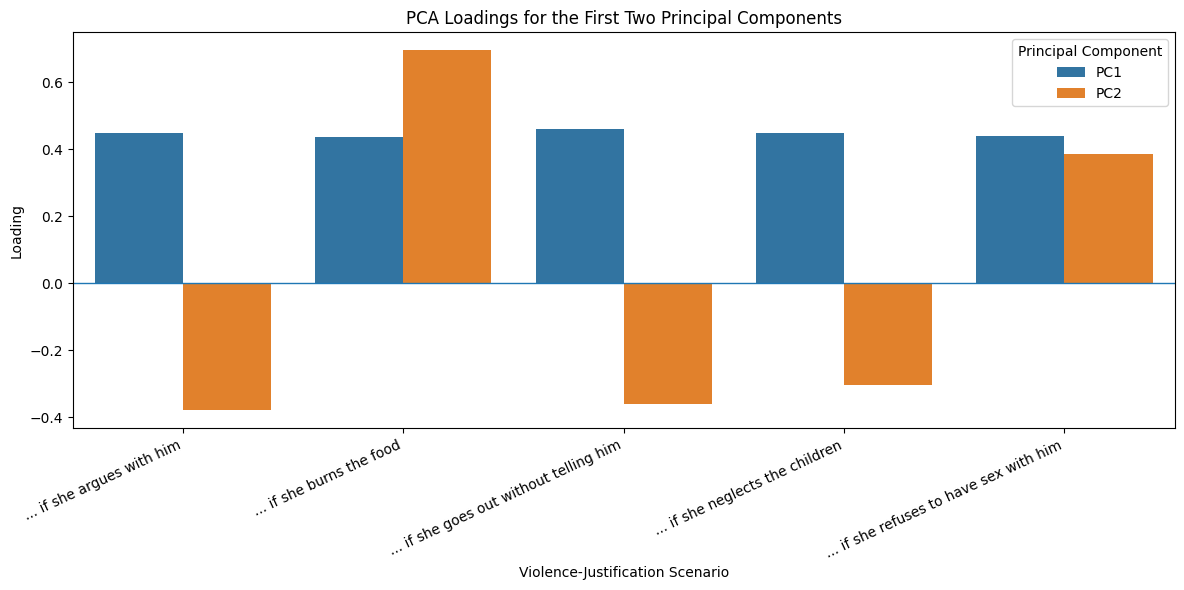

In [108]:
loadings_long = pca_loadings_summary.melt(
    id_vars="Scenario",
    var_name="Principal Component",
    value_name="Loading"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=loadings_long,
    x="Scenario",
    y="Loading",
    hue="Principal Component"
)

plt.axhline(0, linewidth=1)

plt.title("PCA Loadings for the First Two Principal Components")
plt.xlabel("Violence-Justification Scenario")
plt.ylabel("Loading")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.show()

### Interpretation of PCA Loadings

The loading structure provides a clear interpretation of the first principal component.

All five violence-justification scenarios have large, positive, and remarkably similar loadings on PC1, ranging from approximately **0.435 to 0.460**. No single scenario dominates the component.

Combined with the fact that PC1 explains approximately **87.9% of the total variance**, this indicates that the principal source of cross-country variation is a broad common dimension shared across all five scenarios.

PC1 can therefore be interpreted as an **overall violence-justification attitude dimension** within this dataset. Countries with higher PC1 scores tend to report higher percentages across the violence-justification scenarios, while countries with lower PC1 scores tend to report lower percentages across the scenarios.

PC2 has a substantially different structure. The strongest positive loading occurs for the "burns the food" scenario (0.696), followed by refusal of sex (0.387), while arguing, going out without informing the husband, and neglecting the children have negative loadings.

PC2 therefore captures a smaller secondary contrast in the *pattern* of justification across scenarios rather than the overall level of reported justification. However, because PC2 explains only approximately **4.6% of the total variance**, it should not be given the same substantive importance as PC1.

## 36. Two-Dimensional PCA Representation of Countries

Countries are projected onto the first two principal components to visualize similarities and differences in their multivariate violence-justification profiles.

Since PC1 and PC2 jointly explain approximately 92.5% of the total variance, this two-dimensional representation retains most of the information contained in the original five scenario variables.

The primary two-cluster K-Means assignments are overlaid on the PCA representation to examine whether the cluster structure is also visible in the reduced-dimensional space.

Countries positioned closer together have more similar standardized response profiles across the five scenarios, while countries positioned farther apart have more distinct profiles.

In [109]:
pca_results = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

pca_results["Country"] = clustering_results["Country"].values
pca_results["Cluster"] = clustering_results["Cluster"].values

pca_results.head()

,PC1,PC2,Country,Cluster
0,3.287589,-1.493935,Afghanistan,1
1,-2.386355,-0.033298,Albania,0
2,-1.017915,0.370954,Angola,0
3,-1.835947,-0.540906,Armenia,0
4,1.863032,-1.282881,Azerbaijan,1


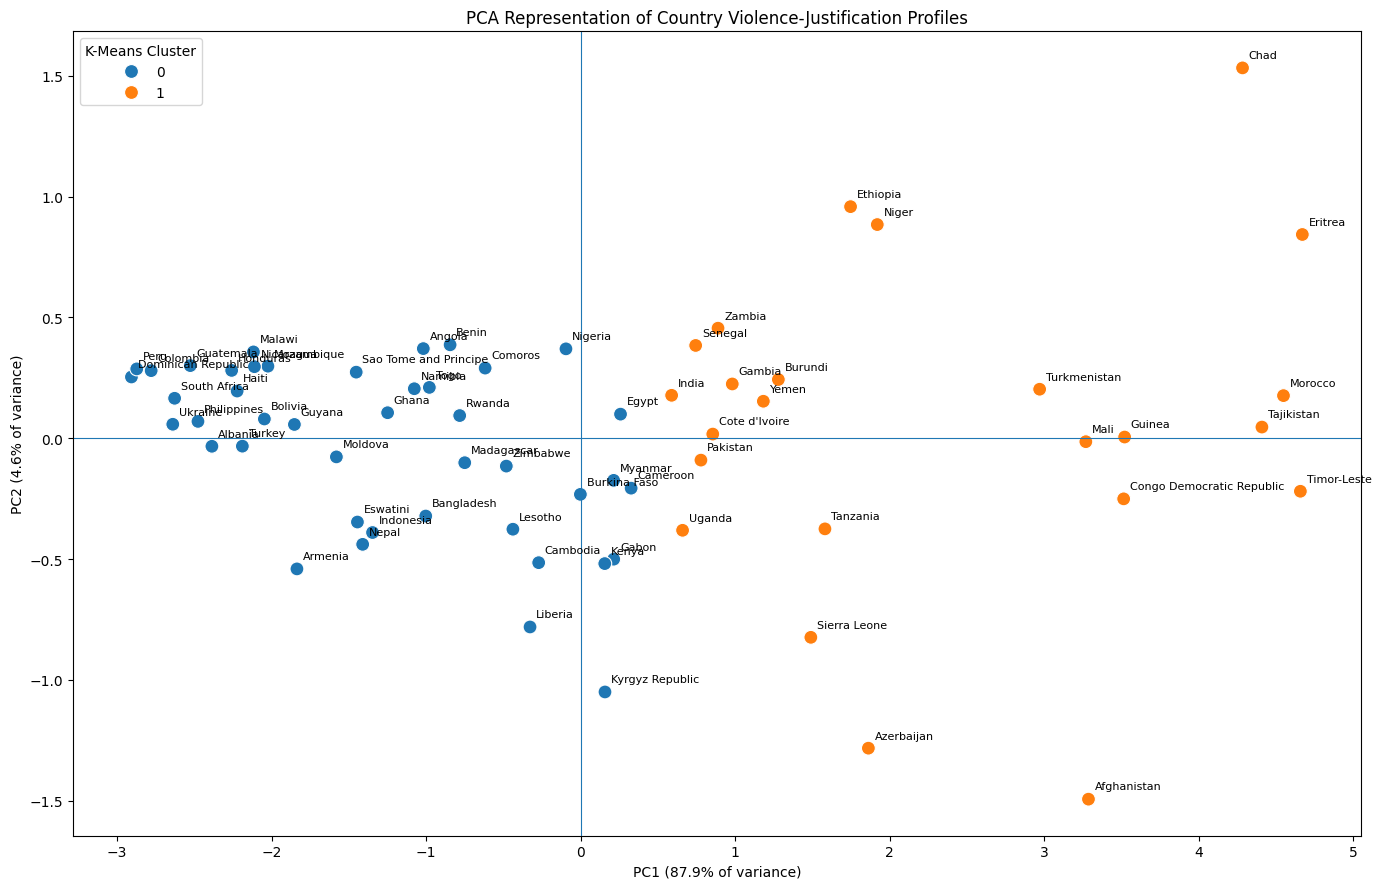

In [110]:
plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=pca_results,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=100
)

for _, row in pca_results.iterrows():
    plt.text(
        row["PC1"] + 0.04,
        row["PC2"] + 0.04,
        row["Country"],
        fontsize=8
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("PC1 (87.9% of variance)")
plt.ylabel("PC2 (4.6% of variance)")
plt.title(
    "PCA Representation of Country Violence-Justification Profiles"
)

plt.legend(title="K-Means Cluster")
plt.tight_layout()

plt.show()

### Interpretation of the PCA Country Map

The two-dimensional PCA representation provides strong visual support for the structure identified by K-Means clustering.

The two clusters are separated primarily along **PC1**, which explains approximately **87.9% of the total variance**. Countries assigned to Cluster 0 are concentrated largely toward lower PC1 scores, while countries assigned to Cluster 1 are concentrated toward higher PC1 scores.

Because all five violence-justification scenarios load positively and almost equally on PC1, movement along this axis primarily represents differences in the overall level of reported justification across the five scenarios.

The PCA results therefore suggest that the primary distinction between the two country clusters is not a difference in which specific scenarios are justified, but rather a broad difference in the overall reported level of violence-justifying attitudes across scenarios.

PC2 explains only approximately **4.6% of the variance** and primarily captures smaller differences in the relative pattern of responses across scenarios. Countries positioned unusually high or low on PC2 may therefore have scenario profiles that differ somewhat from the dominant cross-country pattern.

Overall, the PCA and K-Means results are highly consistent: most cross-country variation can be summarized by a single dominant dimension, and the two-cluster solution largely separates countries along this dimension.

## 37. Relationship Between PCA Scores and K-Means Clusters

The PCA visualization suggests that the K-Means clusters are separated predominantly along the first principal component.

To quantify this relationship, the distribution of PC1 scores is summarized for each cluster. Since PC1 represents the dominant common violence-justification dimension, substantial differences in PC1 scores between clusters would confirm that the clustering solution primarily reflects differences in the overall reported level across the five scenarios.

In [111]:
pc1_cluster_summary = (
    pca_results
    .groupby("Cluster")["PC1"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        observations="count"
    )
)

pc1_cluster_summary

,mean,median,std,min,max,observations
Cluster,,,,,,
0,-1.295614,-1.346638,1.007215,-2.907188,0.327199,43
1,2.321309,1.805317,1.477831,0.589381,4.671941,24


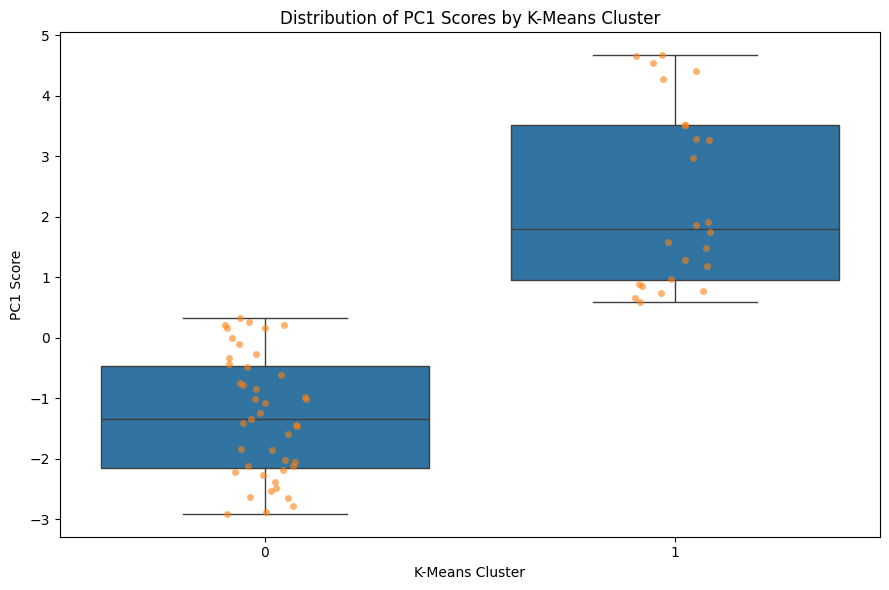

In [112]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=pca_results,
    x="Cluster",
    y="PC1"
)

sns.stripplot(
    data=pca_results,
    x="Cluster",
    y="PC1",
    alpha=0.6
)

plt.title("Distribution of PC1 Scores by K-Means Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("PC1 Score")

plt.tight_layout()
plt.show()

## 38. Statistical Comparison of PC1 Scores Between Clusters

To formally assess whether the two K-Means clusters occupy different positions along the dominant PCA dimension, PC1 scores are compared using the Mann–Whitney U test.

The test evaluates whether the distribution of PC1 scores differs systematically between the two clusters without requiring the assumption of normally distributed scores.

Because the clusters were themselves derived from the same underlying scenario variables, this test should be interpreted as a descriptive validation of cluster separation rather than as independent confirmatory evidence.

In [113]:
from scipy.stats import mannwhitneyu

cluster0_pc1 = pca_results.loc[
    pca_results["Cluster"] == 0, "PC1"
]

cluster1_pc1 = pca_results.loc[
    pca_results["Cluster"] == 1, "PC1"
]

u_stat, p_value = mannwhitneyu(
    cluster0_pc1,
    cluster1_pc1,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {u_stat:.3f}")
print(f"p-value: {p_value:.6g}")

Mann–Whitney U statistic: 0.000
p-value: 1.57289e-11


In [114]:
n0 = len(cluster0_pc1)
n1 = len(cluster1_pc1)

rank_biserial = 1 - (2 * u_stat) / (n0 * n1)

print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Rank-biserial correlation: 1.000


### Interpretation of PC1 Separation Between Clusters

The distribution of PC1 scores shows complete separation between the two K-Means clusters.

Cluster 0 has a mean PC1 score of **−1.30** and a median of **−1.35**, with scores ranging from approximately **−2.91 to 0.33**. In contrast, Cluster 1 has a mean PC1 score of **2.32** and a median of **1.81**, with scores ranging from approximately **0.59 to 4.67**.

Importantly, the observed PC1 ranges of the two clusters do not overlap. The maximum PC1 score in Cluster 0 (0.33) remains below the minimum score in Cluster 1 (0.59).

A Mann–Whitney U test also indicates a very strong difference in the PC1 score distributions between the clusters (**U = 0, p < 0.001**). The corresponding rank-biserial effect-size magnitude is **1.00**, indicating complete separation in the rank ordering of PC1 scores between the two groups.

Because PC1 explains approximately **87.9% of the variance** and all five scenarios load positively and similarly onto it, these findings indicate that the two-cluster solution primarily separates countries according to their overall level of reported justification across the violence-related scenarios.

However, this statistical comparison should be interpreted as a descriptive assessment of cluster separation rather than an independent hypothesis test. Both the PCA scores and K-Means clusters were derived from the same underlying scenario variables, so the extremely strong separation is partly a consequence of their shared data structure.

### Interpreting the Clusters as Groups Along a Continuum

Although K-Means identifies two distinct clusters, the PCA results suggest that these groups should not necessarily be interpreted as fundamentally different categories of countries.

PC1 alone explains approximately 87.9% of the total variation and represents a common dimension shared across all five violence-justification scenarios. The strong separation of the clusters along this component indicates that K-Means is largely partitioning countries according to their position on this dominant continuous dimension.

The clusters are therefore best interpreted as a useful descriptive segmentation of country profiles rather than evidence of two naturally discrete types of societies.

This distinction is important because clustering algorithms will create partitions even when the underlying structure is predominantly continuous.

# Multivariable Analysis

## 39. Modelling the Factors Associated With Reported Violence Justification

The exploratory analysis identified substantial differences in reported violence justification across countries, scenarios, gender, education, residence, employment status, age and marital status.

However, these descriptive comparisons examine characteristics largely in isolation. Differences observed for one characteristic may partly reflect differences in other characteristics or in the countries represented in each group.

A multivariable modelling approach is therefore used to examine the simultaneous association between demographic characteristics, scenario type and reported violence-justification percentages.

The objective is not to establish causal relationships, but to determine which characteristics remain statistically associated with the reported percentage after accounting for other observed factors.

In [115]:
model_df = df[
    [
        "Value",
        "Country",
        "Gender",
        "Demographics Question",
        "Demographics Response",
        "Question",
        "Survey Year"
    ]
].dropna(subset=["Value"]).copy()

print("Modelling observations:", len(model_df))
print("Countries:", model_df["Country"].nunique())
print("Missing values:")
display(model_df.isna().sum())

Modelling observations: 11187
Countries: 70
Missing values:


Value                    0
Country                  0
Gender                   0
Demographics Question    0
Demographics Response    0
Question                 0
Survey Year              0
dtype: int64

In [116]:
model_df["Age"] = np.where(
    model_df["Demographics Question"].eq("Age"),
    model_df["Demographics Response"],
    "Not applicable"
)

model_df["Education"] = np.where(
    model_df["Demographics Question"].eq("Education"),
    model_df["Demographics Response"],
    "Not applicable"
)

model_df["Employment"] = np.where(
    model_df["Demographics Question"].eq("Employment"),
    model_df["Demographics Response"],
    "Not applicable"
)

model_df["Marital_Status"] = np.where(
    model_df["Demographics Question"].eq("Marital status"),
    model_df["Demographics Response"],
    "Not applicable"
)

model_df["Residence"] = np.where(
    model_df["Demographics Question"].eq("Residence"),
    model_df["Demographics Response"],
    "Not applicable"
)

In [117]:
model_df[
    [
        "Value",
        "Country",
        "Gender",
        "Age",
        "Education",
        "Employment",
        "Marital_Status",
        "Residence",
        "Question"
    ]
].head(15)

,Value,Country,Gender,Age,Education,Employment,Marital_Status,Residence,Question
1,10.1,Afghanistan,F,Not applicable,Higher,Not applicable,Not applicable,Not applicable,... if she burns the food
2,13.7,Afghanistan,F,Not applicable,Secondary,Not applicable,Not applicable,Not applicable,... if she burns the food
3,13.8,Afghanistan,F,Not applicable,Primary,Not applicable,Not applicable,Not applicable,... if she burns the food
4,13.8,Afghanistan,F,Not applicable,Not applicable,Not applicable,"Widowed, divorced, separated",Not applicable,... if she burns the food
5,17.0,Afghanistan,F,Not applicable,Not applicable,Employed for kind,Not applicable,Not applicable,... if she burns the food
6,17.3,Afghanistan,F,15-24,Not applicable,Not applicable,Not applicable,Not applicable,... if she burns the food
7,18.0,Afghanistan,F,Not applicable,Not applicable,Unemployed,Not applicable,Not applicable,... if she burns the food
8,18.1,Afghanistan,F,Not applicable,Not applicable,Not applicable,Not applicable,Rural,... if she burns the food
9,18.2,Afghanistan,F,25-34,Not applicable,Not applicable,Not applicable,Not applicable,... if she burns the food
10,18.3,Afghanistan,F,Not applicable,Not applicable,Not applicable,Married or living together,Not applicable,... if she burns the food


### Structure of the Demographic Data

The dataset contains aggregated survey estimates rather than individual-level respondent records.

Each observation represents the reported percentage for a particular combination of country, gender, violence-justification scenario, and **one demographic stratification**. For example, an observation may describe women with primary education or men aged 25–34, but it does not simultaneously identify the education, age, employment status, marital status and residence of the same individuals.

Consequently, the demographic dimensions cannot be entered simultaneously as if they were jointly observed individual-level characteristics. Doing so would incorrectly treat structurally unavailable demographic information as ordinary categories.

The multivariable analysis therefore preserves the actual structure of the data by modelling demographic dimensions separately while controlling for common contextual factors such as country, gender and violence-justification scenario.

The resulting coefficients should be interpreted as associations between subgroup-level reported percentages and demographic categories, not as individual-level effects or causal relationships.

## 40. Adjusted Analysis of Education

The exploratory analysis revealed a pronounced education gradient in reported violence justification. Mean reported percentages declined from approximately 25.4% among groups with no education to 8.9% among groups with higher education.

However, these unadjusted differences may partly reflect variation in country composition, gender and violence-justification scenario.

An adjusted regression model is therefore estimated using only observations stratified by education. The model includes education level as the demographic predictor while controlling for gender, violence-justification scenario and country.

Country is included as a fixed effect to account for systematic differences in reported levels between countries. Scenario fixed effects account for the substantial differences previously observed between violence-justification situations.

Because observations are aggregated subgroup estimates rather than individual respondent records, the resulting coefficients describe adjusted differences between subgroup-level percentages and should not be interpreted as individual-level causal effects.

In [118]:
education_df = (
    df[
        (df["Demographics Question"] == "Education") &
        (df["Value"].notna())
    ]
    .copy()
)

education_df = education_df.rename(
    columns={"Demographics Response": "Education"}
)

print("Observations:", len(education_df))
print("Countries:", education_df["Country"].nunique())

display(
    education_df[
        ["Country", "Gender", "Education", "Question", "Value"]
    ].head()
)

display(
    education_df["Education"].value_counts()
)

Observations: 2942
Countries: 70


,Country,Gender,Education,Question,Value
1,Afghanistan,F,Higher,... if she burns the food,10.1
2,Afghanistan,F,Secondary,... if she burns the food,13.7
3,Afghanistan,F,Primary,... if she burns the food,13.8
13,Afghanistan,F,No education,... if she burns the food,19.1
16,Afghanistan,M,Higher,... if she burns the food,4.5


Education
Secondary       758
Higher          752
Primary         728
No education    704
Name: count, dtype: int64

In [119]:
import statsmodels.formula.api as smf

education_model = smf.ols(
    formula="""
        Value ~
        C(Education, Treatment(reference='No education')) +
        C(Gender) +
        C(Question) +
        C(Country)
    """,
    data=education_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": education_df["Country"]}
)

print(education_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     480.4
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           1.43e-58
Time:                        08:43:53   Log-Likelihood:                -10368.
No. Observations:                2942   AIC:                         2.089e+04
Df Residuals:                    2863   BIC:                         2.137e+04
Df Model:                          78                                         
Covariance Type:              cluster                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

c:\Users\User\miniconda3\envs\wadhare\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 78, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [120]:
education_terms = [
    term for term in education_model.params.index
    if "Education" in term
]

education_results = pd.DataFrame({
    "Coefficient": education_model.params[education_terms],
    "Std_Error": education_model.bse[education_terms],
    "p_value": education_model.pvalues[education_terms],
    "CI_Lower": education_model.conf_int().loc[education_terms, 0],
    "CI_Upper": education_model.conf_int().loc[education_terms, 1]
})

education_results

,Coefficient,Std_Error,p_value,CI_Lower,CI_Upper
"C(Education, Treatment(reference='No education'))[T.Higher]",-16.419104,1.122285,1.805997e-48,-18.618742,-14.219467
"C(Education, Treatment(reference='No education'))[T.Primary]",-2.535447,0.569695,8.565734e-06,-3.652030,-1.418865
"C(Education, Treatment(reference='No education'))[T.Secondary]",-7.897257,0.777211,2.959608e-24,-9.420563,-6.373952


### Interpretation of the Adjusted Education Model

The adjusted regression analysis provides evidence of a strong education gradient in reported violence justification.

Using respondents with **no education** as the reference category, all three higher education categories are associated with lower subgroup-level reported percentages after accounting for country, gender, and violence-justification scenario.

Specifically:

- **Primary education** is associated with an adjusted reduction of approximately **2.54 percentage points** relative to no education (95% CI: −3.65 to −1.42, p < 0.001).
- **Secondary education** is associated with an adjusted reduction of approximately **7.90 percentage points** (95% CI: −9.42 to −6.37, p < 0.001).
- **Higher education** shows the largest difference, with an adjusted reduction of approximately **16.42 percentage points** relative to no education (95% CI: −18.62 to −14.22, p < 0.001).

The magnitude of the coefficients increases progressively across education levels, revealing a clear adjusted education gradient. This pattern is consistent with the earlier descriptive analysis, where mean reported percentages declined from 25.4% among groups with no education to 8.9% among groups with higher education.

Importantly, the education gradient remains substantial even after accounting for systematic differences between countries, gender groups, and violence-justification scenarios. This suggests that the descriptive education pattern is not explained solely by those factors.

However, these results represent **subgroup-level associations rather than individual-level causal effects**. The dataset contains aggregated survey estimates, and the analysis does not establish that increasing an individual's education would itself produce the estimated reductions in reported violence justification.

## 43. Comparing Unadjusted and Adjusted Education Differences

To assess whether adjustment for country, gender and violence-justification scenario substantially changes the observed education gradient, unadjusted mean differences are compared with the coefficients from the adjusted regression model.

If the adjusted estimates remain close to the unadjusted differences, this indicates that the overall education gradient is relatively robust to differences in the included contextual factors.

In [121]:
education_raw_means = (
    education_df
    .groupby("Education")["Value"]
    .mean()
)

reference_mean = education_raw_means["No education"]

raw_differences = (
    education_raw_means - reference_mean
)

education_comparison = pd.DataFrame({
    "Raw_Mean": education_raw_means,
    "Raw_Difference_vs_No_Education": raw_differences
})

education_comparison

,Raw_Mean,Raw_Difference_vs_No_Education
Education,,
Higher,8.898670,-16.504455
No education,25.403125,0.000000
Primary,22.819093,-2.584032
Secondary,17.378892,-8.024233


In [122]:
adjusted_map = {
    "No education": 0,
    "Primary": education_model.params[
        "C(Education, Treatment(reference='No education'))[T.Primary]"
    ],
    "Secondary": education_model.params[
        "C(Education, Treatment(reference='No education'))[T.Secondary]"
    ],
    "Higher": education_model.params[
        "C(Education, Treatment(reference='No education'))[T.Higher]"
    ]
}

education_comparison["Adjusted_Difference"] = (
    education_comparison.index.map(adjusted_map)
)

education_comparison = education_comparison.loc[
    ["No education", "Primary", "Secondary", "Higher"]
]

education_comparison

,Raw_Mean,Raw_Difference_vs_No_Education,Adjusted_Difference
Education,,,
No education,25.403125,0.000000,0.000000
Primary,22.819093,-2.584032,-2.535447
Secondary,17.378892,-8.024233,-7.897257
Higher,8.898670,-16.504455,-16.419104


In [123]:
import statsmodels.formula.api as smf
import pandas as pd


def fit_demographic_model(
    data,
    demographic_question,
    reference_category
):
    """
    Fits an OLS model for one demographic dimension while adjusting
    for gender, violence-justification scenario and country.

    Standard errors are clustered by country.
    """

    subset = data[
        (data["Demographics Question"] == demographic_question) &
        (data["Value"].notna())
    ].copy()

    subset = subset.rename(
        columns={"Demographics Response": "Demographic"}
    )

    formula = f"""
        Value ~
        C(Demographic, Treatment(reference='{reference_category}')) +
        C(Gender) +
        C(Question) +
        C(Country)
    """

    model = smf.ols(
        formula=formula,
        data=subset
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": subset["Country"]}
    )

    terms = [
        term for term in model.params.index
        if "Demographic" in term
    ]

    results = pd.DataFrame({
        "Demographic_Dimension": demographic_question,
        "Reference_Category": reference_category,
        "Category": [
            term.split("[T.")[-1].rstrip("]")
            for term in terms
        ],
        "Coefficient": model.params[terms].values,
        "Std_Error": model.bse[terms].values,
        "p_value": model.pvalues[terms].values,
        "CI_Lower": model.conf_int().loc[terms, 0].values,
        "CI_Upper": model.conf_int().loc[terms, 1].values
    })

    return model, results

In [124]:
age_model, age_results = fit_demographic_model(
    df,
    "Age",
    "15-24"
)

residence_model, residence_results = fit_demographic_model(
    df,
    "Residence",
    "Rural"
)

employment_model, employment_results = fit_demographic_model(
    df,
    "Employment",
    "Unemployed"
)

marital_model, marital_results = fit_demographic_model(
    df,
    "Marital status",
    "Never married"
)

In [125]:
print("AGE")
display(age_results)

print("RESIDENCE")
display(residence_results)

print("EMPLOYMENT")
display(employment_results)

print("MARITAL STATUS")
display(marital_results)

AGE


,Demographic_Dimension,Reference_Category,Category,Coefficient,Std_Error,p_value,CI_Lower,CI_Upper
0,Age,15-24,25-34,-1.380607,0.365424,0.000158,-2.096824,-0.664390
1,Age,15-24,35-49,-1.747757,0.422226,0.000035,-2.575306,-0.920209


RESIDENCE


,Demographic_Dimension,Reference_Category,Category,Coefficient,Std_Error,p_value,CI_Lower,CI_Upper
0,Residence,Rural,Urban,-7.398285,0.633864,1.777685e-31,-8.640635,-6.155935


EMPLOYMENT


,Demographic_Dimension,Reference_Category,Category,Coefficient,Std_Error,p_value,CI_Lower,CI_Upper
0,Employment,Unemployed,Employed for cash,-0.434888,0.413410,2.928214e-01,-1.245157,0.375381
1,Employment,Unemployed,Employed for kind,4.412794,0.598959,1.739416e-13,3.238855,5.586733


MARITAL STATUS


,Demographic_Dimension,Reference_Category,Category,Coefficient,Std_Error,p_value,CI_Lower,CI_Upper
0,Marital status,Never married,Married or living together,1.177128,0.505739,0.019936,0.185899,2.168358
1,Marital status,Never married,"Widowed, divorced, separated",1.604737,0.494059,0.001162,0.636400,2.573075


### Interpretation of the Adjusted Age Model

After accounting for country, gender, and violence-justification scenario, reported percentages differ significantly across age groups.

Using respondents aged **15–24 years** as the reference category:

- The **25–34** group has an adjusted reported percentage approximately **1.38 percentage points lower** than the 15–24 group (95% CI: −2.10 to −0.66, p < 0.001).
- The **35–49** group has an adjusted reported percentage approximately **1.75 percentage points lower** (95% CI: −2.58 to −0.92, p < 0.001).

The results therefore suggest a modest age gradient, with older age groups showing somewhat lower reported justification of violence than the youngest group.

Although statistically significant, these differences are relatively small compared with the differences observed for education and residence. Statistical significance should therefore not be confused with substantive magnitude.

### Interpretation of the Adjusted Residence Model

Residence shows a substantial association with reported attitudes toward violence.

Using **rural residence** as the reference category, urban groups have an adjusted reported percentage approximately **7.40 percentage points lower** than rural groups (95% CI: −8.64 to −6.16, p < 0.001).

This difference remains substantial after accounting for country, gender, and violence-justification scenario.

The result is also highly consistent with the descriptive analysis, where the mean reported percentage was approximately 23.29% for rural groups compared with 15.90% for urban groups.

Among the demographic dimensions examined, residence therefore represents one of the larger adjusted differences in the dataset, although the observational and aggregated structure of the data prevents a causal interpretation.

### Interpretation of the Adjusted Employment Model

The relationship between employment status and reported violence justification is mixed.

Using **unemployed groups** as the reference category:

- Groups **employed for cash** have an adjusted reported percentage approximately **0.43 percentage points lower** than unemployed groups. However, this difference is not statistically significant (95% CI: −1.25 to 0.38, p = 0.293).
- Groups **employed for kind** have an adjusted reported percentage approximately **4.41 percentage points higher** than unemployed groups (95% CI: 3.24 to 5.59, p < 0.001).

The results therefore provide little evidence of a meaningful difference between cash-employed and unemployed groups, while employment for kind is associated with substantially higher reported percentages.

This suggests that employment should not be interpreted as a simple employed-versus-unemployed relationship. The form of employment appears to matter considerably within these aggregated survey estimates.

### Interpretation of the Adjusted Marital-Status Model

Using **never-married groups** as the reference category:

- Groups classified as **married or living together** have an adjusted reported percentage approximately **1.18 percentage points higher** (95% CI: 0.19 to 2.17, p = 0.020).
- Groups classified as **widowed, divorced, or separated** have an adjusted reported percentage approximately **1.60 percentage points higher** (95% CI: 0.64 to 2.57, p = 0.001).

Both differences are statistically significant at the 5% level. However, their magnitudes are relatively small compared with the education and residence differences observed elsewhere in the analysis.

The results therefore indicate detectable marital-status differences, but marital status appears to explain considerably smaller variation in reported percentages than some of the other demographic dimensions examined.

## 45. Combined Adjusted Demographic Effects

The separate demographic models can now be compared to evaluate the relative magnitude and uncertainty of the adjusted demographic associations.

Each coefficient represents the estimated percentage-point difference from the specified reference category after controlling for country, gender, and violence-justification scenario.

Because the models use different reference categories, coefficients should be interpreted relative to the reference category shown for each demographic dimension rather than as absolute levels of violence justification.

In [126]:
education_effects = pd.DataFrame({
    "Demographic_Dimension": "Education",
    "Reference_Category": "No education",
    "Category": ["Primary", "Secondary", "Higher"],
    "Coefficient": [
        education_model.params[
            "C(Education, Treatment(reference='No education'))[T.Primary]"
        ],
        education_model.params[
            "C(Education, Treatment(reference='No education'))[T.Secondary]"
        ],
        education_model.params[
            "C(Education, Treatment(reference='No education'))[T.Higher]"
        ]
    ],
    "Std_Error": [
        education_model.bse[
            "C(Education, Treatment(reference='No education'))[T.Primary]"
        ],
        education_model.bse[
            "C(Education, Treatment(reference='No education'))[T.Secondary]"
        ],
        education_model.bse[
            "C(Education, Treatment(reference='No education'))[T.Higher]"
        ]
    ],
    "p_value": [
        education_model.pvalues[
            "C(Education, Treatment(reference='No education'))[T.Primary]"
        ],
        education_model.pvalues[
            "C(Education, Treatment(reference='No education'))[T.Secondary]"
        ],
        education_model.pvalues[
            "C(Education, Treatment(reference='No education'))[T.Higher]"
        ]
    ]
})

education_effects["CI_Lower"] = (
    education_effects["Coefficient"]
    - 1.96 * education_effects["Std_Error"]
)

education_effects["CI_Upper"] = (
    education_effects["Coefficient"]
    + 1.96 * education_effects["Std_Error"]
)

In [127]:
all_demographic_effects = pd.concat(
    [
        education_effects,
        age_results,
        residence_results,
        employment_results,
        marital_results
    ],
    ignore_index=True
)

all_demographic_effects

,Demographic_Dimension,Reference_Category,Category,Coefficient,Std_Error,p_value,CI_Lower,CI_Upper
0,Education,No education,Primary,-2.535447,0.569695,8.565734e-06,-3.652050,-1.418845
1,Education,No education,Secondary,-7.897257,0.777211,2.959608e-24,-9.420591,-6.373924
2,Education,No education,Higher,-16.419104,1.122285,1.805997e-48,-18.618782,-14.219426
3,Age,15-24,25-34,-1.380607,0.365424,1.580299e-04,-2.096824,-0.664390
4,Age,15-24,35-49,-1.747757,0.422226,3.482406e-05,-2.575306,-0.920209
5,Residence,Rural,Urban,-7.398285,0.633864,1.777685e-31,-8.640635,-6.155935
6,Employment,Unemployed,Employed for cash,-0.434888,0.413410,2.928214e-01,-1.245157,0.375381
7,Employment,Unemployed,Employed for kind,4.412794,0.598959,1.739416e-13,3.238855,5.586733
8,Marital status,Never married,Married or living together,1.177128,0.505739,1.993637e-02,0.185899,2.168358
9,Marital status,Never married,"Widowed, divorced, separated",1.604737,0.494059,1.161913e-03,0.636400,2.573075


In [128]:
all_demographic_effects["Label"] = (
    all_demographic_effects["Demographic_Dimension"]
    + ": "
    + all_demographic_effects["Category"]
)

all_demographic_effects["Significant"] = (
    all_demographic_effects["p_value"] < 0.05
)

all_demographic_effects[
    [
        "Demographic_Dimension",
        "Reference_Category",
        "Category",
        "Coefficient",
        "CI_Lower",
        "CI_Upper",
        "p_value",
        "Significant"
    ]
]

,Demographic_Dimension,Reference_Category,Category,Coefficient,CI_Lower,CI_Upper,p_value,Significant
0,Education,No education,Primary,-2.535447,-3.652050,-1.418845,8.565734e-06,True
1,Education,No education,Secondary,-7.897257,-9.420591,-6.373924,2.959608e-24,True
2,Education,No education,Higher,-16.419104,-18.618782,-14.219426,1.805997e-48,True
3,Age,15-24,25-34,-1.380607,-2.096824,-0.664390,1.580299e-04,True
4,Age,15-24,35-49,-1.747757,-2.575306,-0.920209,3.482406e-05,True
5,Residence,Rural,Urban,-7.398285,-8.640635,-6.155935,1.777685e-31,True
6,Employment,Unemployed,Employed for cash,-0.434888,-1.245157,0.375381,2.928214e-01,False
7,Employment,Unemployed,Employed for kind,4.412794,3.238855,5.586733,1.739416e-13,True
8,Marital status,Never married,Married or living together,1.177128,0.185899,2.168358,1.993637e-02,True
9,Marital status,Never married,"Widowed, divorced, separated",1.604737,0.636400,2.573075,1.161913e-03,True


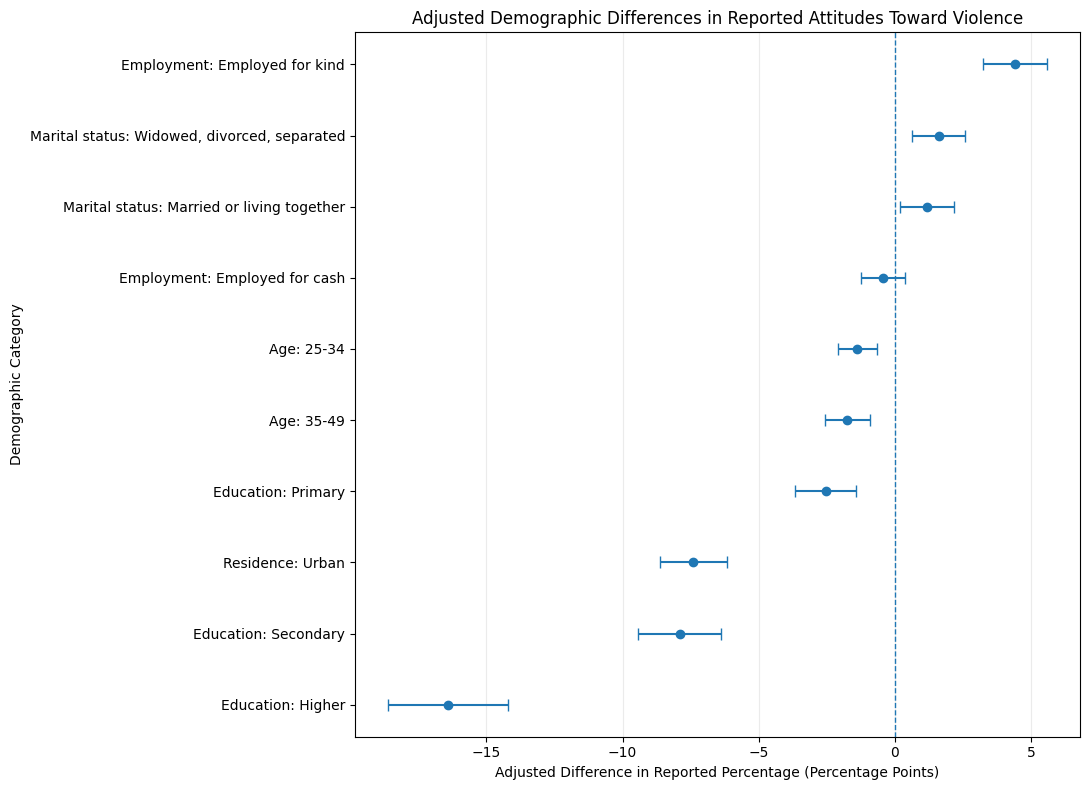

In [129]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = (
    all_demographic_effects
    .sort_values("Coefficient")
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))

lower_error = (
    plot_df["Coefficient"] - plot_df["CI_Lower"]
)

upper_error = (
    plot_df["CI_Upper"] - plot_df["Coefficient"]
)

plt.figure(figsize=(11, 8))

plt.errorbar(
    plot_df["Coefficient"],
    y,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    y,
    plot_df["Label"]
)

plt.xlabel(
    "Adjusted Difference in Reported Percentage (Percentage Points)"
)

plt.ylabel("Demographic Category")

plt.title(
    "Adjusted Demographic Differences in Reported Attitudes Toward Violence"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Interpretation of the Combined Adjusted Effects

The combined results reveal substantial differences in the magnitude of demographic associations.

The strongest adjusted pattern is observed for **education**. Relative to groups with no education, the estimated reported percentage declines progressively across primary, secondary and higher education, with the largest difference observed for higher education.

**Residence** also shows a sizeable difference, with urban groups reporting substantially lower percentages than rural groups.

The estimated differences between the older age groups and the 15–24 reference group are statistically significant but comparatively small. Similarly, marital-status differences are detectable but modest in magnitude.

Employment presents a more heterogeneous pattern. Cash employment does not differ significantly from unemployment, whereas employment for kind is associated with a higher reported percentage.

Taken together, these findings indicate that the demographic dimensions are not equally associated with reported violence justification. Education and residence show the largest adjusted differences among the demographic comparisons examined here, while age and marital status show smaller differences.

These results remain associational. Because the observations represent aggregated demographic survey estimates rather than individual respondent records, the coefficients should not be interpreted as individual-level causal effects.

## 47. Regression Model Diagnostics and Robustness Checks

The regression analysis identified several statistically significant demographic
associations with reported attitudes toward violence. However, statistical
significance alone does not establish that the fitted models adequately represent
the structure of the data.

Regression diagnostics are therefore conducted to evaluate whether important
model assumptions are violated and whether the estimated demographic effects
are sensitive to unusual observations.

The diagnostic analysis focuses on:

1. Residual distributions and normality.
2. Heteroskedasticity of residual variance.
3. Influential observations.
4. Sensitivity of demographic coefficients to influential observations.
5. Robust standard errors.

These checks are particularly important because the dataset contains aggregated
country-demographic survey estimates rather than individual respondent-level
observations.

In [130]:
# Basic information about the education regression model

print("Number of observations:", int(education_model.nobs))
print("R-squared:", round(education_model.rsquared, 4))
print("Adjusted R-squared:", round(education_model.rsquared_adj, 4))

print("\nResidual summary:")
print(education_model.resid.describe())

Number of observations: 2942
R-squared: 0.766
Adjusted R-squared: 0.7597

Residual summary:
count    2.942000e+03
mean    -7.931415e-15
std      8.210836e+00
min     -2.513087e+01
25%     -5.408227e+00
50%     -5.467433e-01
75%      4.686581e+00
max      2.836788e+01
dtype: float64


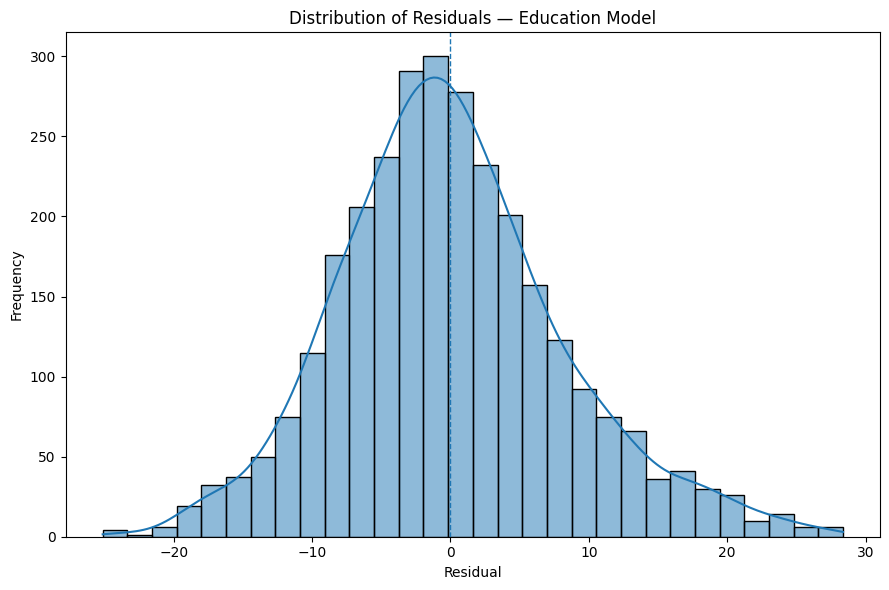

In [131]:
# check the residual distribution

import matplotlib.pyplot as plt
import seaborn as sns

residuals = education_model.resid

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Distribution of Residuals — Education Model")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

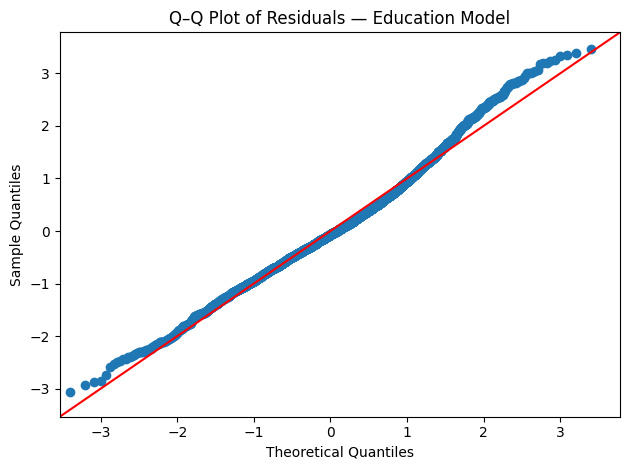

In [132]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q–Q Plot of Residuals — Education Model")
plt.tight_layout()
plt.show()

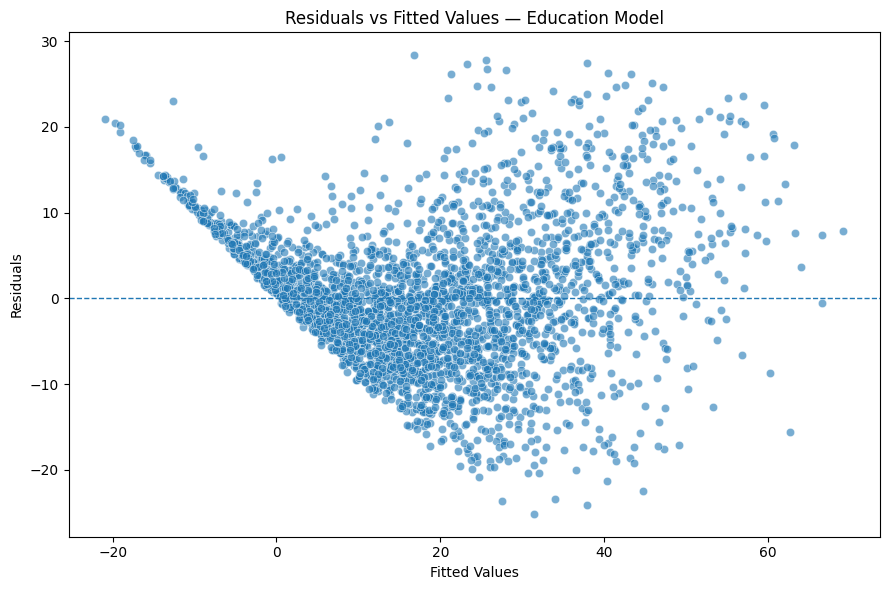

In [133]:
# Residuals vs fitted values

fitted_values = education_model.fittedvalues

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=fitted_values,
    y=residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title(
    "Residuals vs Fitted Values — Education Model"
)

plt.tight_layout()
plt.show()

In [134]:
# Breusch–Pagan test

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    education_model.resid,
    education_model.model.exog
)

bp_results = {
    "LM Statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F Statistic": bp_test[2],
    "F p-value": bp_test[3]
}

for key, value in bp_results.items():
    print(f"{key}: {value:.6g}")

LM Statistic: 757.754
LM p-value: 5.83345e-112
F Statistic: 12.7337
F p-value: 8.32914e-133


In [135]:
influence = education_model.get_influence()

influence_df = pd.DataFrame({
    "Cook_Distance": influence.cooks_distance[0],
    "Leverage": influence.hat_matrix_diag,
    "Studentized_Residual": influence.resid_studentized_external
})

influence_df.describe()

,Cook_Distance,Leverage,Studentized_Residual
count,2.942000e+03,2942.000000,2942.000000
mean,3.535297e-04,0.026852,0.000070
std,5.816834e-04,0.006542,1.000733
min,1.099666e-09,0.023893,-3.061192
25%,2.740159e-05,0.023921,-0.657730
50%,1.273981e-04,0.023958,-0.066845
75%,4.145202e-04,0.024004,0.571500
max,5.748499e-03,0.044466,3.479137


In [136]:
n = len(influence_df)

cooks_threshold = 4 / n

print("Cook's distance threshold:", round(cooks_threshold, 6))

print(
    "Observations above threshold:",
    (influence_df["Cook_Distance"] > cooks_threshold).sum()
)

print(
    "Maximum Cook's distance:",
    influence_df["Cook_Distance"].max()
)

print(
    "Maximum leverage:",
    influence_df["Leverage"].max()
)

Cook's distance threshold: 0.00136
Observations above threshold: 189
Maximum Cook's distance: 0.0057484987060867155
Maximum leverage: 0.044465565622423854


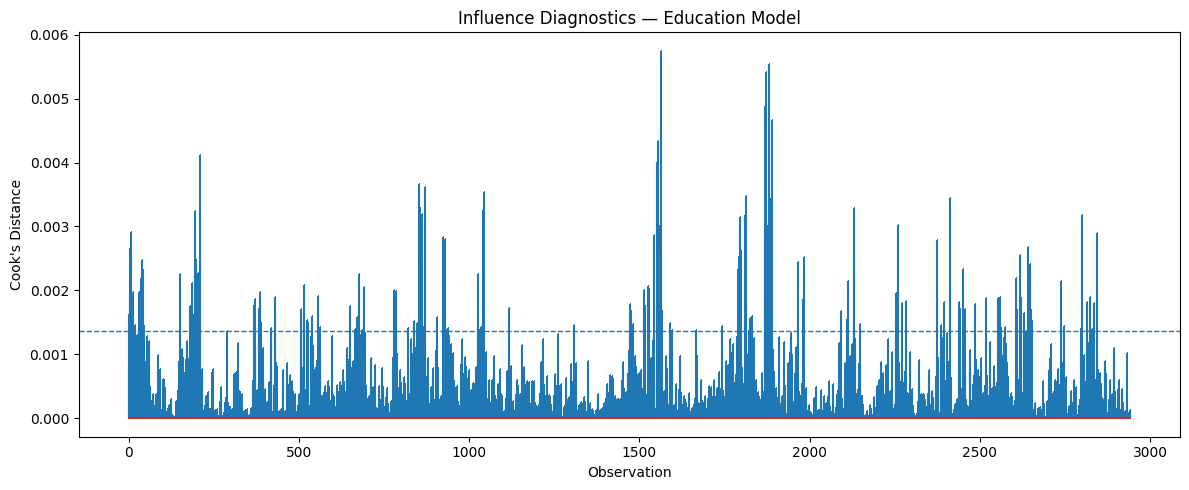

In [137]:
plt.figure(figsize=(12, 5))

plt.stem(
    np.arange(len(influence_df)),
    influence_df["Cook_Distance"],
    markerfmt=","
)

plt.axhline(
    cooks_threshold,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")

plt.title(
    "Influence Diagnostics — Education Model"
)

plt.tight_layout()
plt.show()

### Education Model Diagnostic Results

The education model contains **2,942 observations** and explains approximately **76.6% of the variation** in reported violence-justification percentages ($R^2 = 0.766$). The adjusted $R^2$ of **0.760** remains close to the unadjusted value, indicating that the model retains substantial explanatory power after accounting for its predictors.

#### Residual Distribution

The residual histogram is broadly centered near zero, as expected from an OLS model. However, the distribution is not perfectly symmetric and exhibits some departure from a normal bell-shaped distribution.

The Q–Q plot confirms this result. Residuals follow the theoretical normal line reasonably well through much of the central distribution but deviate systematically, particularly in the upper tail. Therefore, the residuals should not be treated as perfectly normally distributed.

Given the relatively large sample size, moderate departures from residual normality are less concerning for coefficient estimation than violations of the variance assumptions.

#### Heteroskedasticity

The residual-versus-fitted plot reveals a pronounced change in residual dispersion across predicted values. Rather than forming a constant-width random cloud around zero, the residuals display a clear structured and expanding pattern.

The Breusch–Pagan test strongly confirms this visual evidence:

- LM statistic = **757.754**
- LM p-value < **0.001**
- F statistic = **12.734**
- F p-value < **0.001**

The null hypothesis of constant residual variance is therefore rejected. There is strong evidence of **heteroskedasticity** in the education model.

This does not by itself invalidate the estimated OLS coefficients, but conventional OLS standard errors, confidence intervals and significance tests may be unreliable. Heteroskedasticity-robust standard errors should therefore be used for final statistical inference.

#### Influence Diagnostics

Using the conventional screening threshold of $4/n \approx 0.00136$, **189 observations** exceed the Cook's-distance threshold.

However, the maximum Cook's distance is only approximately **0.00575**, while maximum leverage is approximately **0.0445**. The presence of observations above the screening threshold therefore does not by itself establish that the model is dominated by a small number of extreme observations.

Because the dataset consists of aggregated country-demographic estimates, some influential observations may represent genuine cross-country heterogeneity rather than erroneous data. They should therefore not be removed automatically.

Overall, the diagnostics support retaining the regression model while strengthening inference through robust standard errors and sensitivity analysis.

In [138]:
# Re-estimate inference using HC3 heteroskedasticity-robust standard errors

education_model_hc3 = education_model.get_robustcov_results(
    cov_type="HC3"
)

print(education_model_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     93.84
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:30:08   Log-Likelihood:                -10368.
No. Observations:                2942   AIC:                         2.089e+04
Df Residuals:                    2863   BIC:                         2.137e+04
Df Model:                          78                                         
Covariance Type:                  HC3                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [139]:
import pandas as pd
import numpy as np

param_names = education_model.model.exog_names

hc3_results = pd.DataFrame({
    "Variable": param_names,
    "Coefficient": education_model_hc3.params,
    "OLS_SE": education_model.bse.values,
    "HC3_SE": education_model_hc3.bse,
    "OLS_p_value": education_model.pvalues.values,
    "HC3_p_value": education_model_hc3.pvalues,
    "HC3_CI_Lower": education_model_hc3.conf_int()[:, 0],
    "HC3_CI_Upper": education_model_hc3.conf_int()[:, 1]
})

education_hc3 = hc3_results[
    hc3_results["Variable"].str.contains("Education")
].copy()

education_hc3

,Variable,Coefficient,OLS_SE,HC3_SE,OLS_p_value,HC3_p_value,HC3_CI_Lower,HC3_CI_Upper
1,"C(Education, Treatment(reference='No education...",-16.419104,1.122285,0.483298,1.805997e-48,5.571114e-253,-17.366351,-15.471858
2,"C(Education, Treatment(reference='No education...",-2.535447,0.569695,0.462393,8.565734e-06,4.174300e-08,-3.441722,-1.629173
3,"C(Education, Treatment(reference='No education...",-7.897257,0.777211,0.447842,2.959608e-24,1.350313e-69,-8.775012,-7.019502


In [140]:
education_hc3["SE_Percent_Change"] = (
    (education_hc3["HC3_SE"] - education_hc3["OLS_SE"])
    / education_hc3["OLS_SE"]
) * 100

education_hc3[
    [
        "Variable",
        "Coefficient",
        "OLS_SE",
        "HC3_SE",
        "SE_Percent_Change",
        "OLS_p_value",
        "HC3_p_value",
        "HC3_CI_Lower",
        "HC3_CI_Upper"
    ]
]

,Variable,Coefficient,OLS_SE,HC3_SE,SE_Percent_Change,OLS_p_value,HC3_p_value,HC3_CI_Lower,HC3_CI_Upper
1,"C(Education, Treatment(reference='No education...",-16.419104,1.122285,0.483298,-56.936252,1.805997e-48,5.571114e-253,-17.366351,-15.471858
2,"C(Education, Treatment(reference='No education...",-2.535447,0.569695,0.462393,-18.834981,8.565734e-06,4.174300e-08,-3.441722,-1.629173
3,"C(Education, Treatment(reference='No education...",-7.897257,0.777211,0.447842,-42.378286,2.959608e-24,1.350313e-69,-8.775012,-7.019502


### HC3 Robust Standard Errors: Education Effects

Because the diagnostic analysis identified strong heteroskedasticity, the education model was re-evaluated using **HC3 heteroskedasticity-robust standard errors**.

The estimated regression coefficients remain unchanged because HC3 modifies the estimated covariance matrix rather than the OLS coefficient estimates themselves. However, the uncertainty surrounding those estimates changes substantially.

Relative to groups with no education:

- **Primary education** is associated with a **2.54 percentage-point lower** reported percentage (HC3 95% CI: −3.44 to −1.63, p < 0.001).
- **Secondary education** is associated with a **7.90 percentage-point lower** reported percentage (HC3 95% CI: −8.78 to −7.02, p < 0.001).
- **Higher education** is associated with a **16.42 percentage-point lower** reported percentage (HC3 95% CI: −17.37 to −15.47, p < 0.001).

Importantly, all three education contrasts remain statistically significant after correcting the standard errors for heteroskedasticity.

The HC3 standard errors are smaller than the conventional OLS standard errors, declining by approximately **18.8% for primary**, **42.4% for secondary**, and **56.9% for higher education**. Robust standard errors are not inherently larger than conventional standard errors; their direction depends on the relationship between residual variance, leverage, and the model's design matrix.

The substantive conclusion is therefore highly robust to heteroskedasticity correction: reported violence-justification percentages decline progressively across higher levels of education, with the largest adjusted difference observed for higher education.

These estimates remain associational and should not be interpreted as evidence that education itself causally produces the observed differences.

In [141]:
# Identify observations with the largest influence

education_diagnostic_df = education_df.copy()

education_diagnostic_df["Cook_Distance"] = (
    education_model.get_influence().cooks_distance[0]
)

education_diagnostic_df["Leverage"] = (
    education_model.get_influence().hat_matrix_diag
)

education_diagnostic_df["Studentized_Residual"] = (
    education_model.get_influence().resid_studentized_external
)

top_influential = (
    education_diagnostic_df
    .sort_values("Cook_Distance", ascending=False)
    .head(20)
)

top_influential[
    [
        "Country",
        "Gender",
        "Education",
        "Question",
        "Value",
        "Cook_Distance",
        "Leverage",
        "Studentized_Residual"
    ]
]

,Country,Gender,Education,Question,Value,Cook_Distance,Leverage,Studentized_Residual
6424,Kyrgyz Republic,M,Higher,... if she neglects the children,45.2,0.005748,0.036296,3.479137
7771,Morocco,F,No education,... if she goes out without telling him,67.5,0.005537,0.044415,3.072232
7763,Morocco,F,No education,... if she argues with him,66.1,0.005417,0.044466,3.036927
7759,Morocco,F,No education,... for at least one specific reason,78.5,0.004880,0.044415,2.883590
7779,Morocco,F,No education,... if she refuses to have sex with him,58.9,0.004659,0.044442,2.816678
6408,Kyrgyz Republic,M,Higher,... for at least one specific reason,50.9,0.004343,0.036296,3.022535
844,Azerbaijan,M,Higher,... if she argues with him,47.5,0.004124,0.030988,3.196836
6340,Kyrgyz Republic,F,Primary,... if she refuses to have sex with him,3.9,0.004014,0.036582,-2.893540
3646,Eritrea,F,No education,... for at least one specific reason,77.5,0.003662,0.044415,2.497028
3662,Eritrea,F,No education,... if she refuses to have sex with him,58.3,0.003613,0.044442,2.479499


### Identification of Influential Observations

Cook's distance is used to identify observations that exert comparatively strong influence on the fitted regression model.

Rather than automatically removing every observation exceeding the conventional $4/n$ screening threshold, the observations with the largest Cook's distances are examined directly.

This distinction is important because the dataset contains aggregated country-demographic survey estimates. An observation may be statistically influential because it represents a genuinely unusual country or subgroup rather than because it is erroneous.

In [142]:
flagged = education_diagnostic_df[
    education_diagnostic_df["Cook_Distance"] > cooks_threshold
].copy()

print("Total flagged observations:", len(flagged))
print(
    "Percentage of education sample:",
    round(len(flagged) / len(education_diagnostic_df) * 100, 2),
    "%"
)

print("\nFlagged observations by education:")
display(
    flagged["Education"]
    .value_counts()
    .to_frame("Flagged Observations")
)

print("\nCountries with the most flagged observations:")
display(
    flagged["Country"]
    .value_counts()
    .head(15)
    .to_frame("Flagged Observations")
)

Total flagged observations: 189
Percentage of education sample: 6.42 %

Flagged observations by education:


,Flagged Observations
Education,
No education,68
Higher,54
Primary,41
Secondary,26



Countries with the most flagged observations:


,Flagged Observations
Country,
Afghanistan,17
Azerbaijan,14
Mali,14
Morocco,13
Timor-Leste,11
Eritrea,10
Chad,9
Kyrgyz Republic,8
Burundi,7


In [143]:
sensitivity_df = education_diagnostic_df[
    education_diagnostic_df["Cook_Distance"] <= cooks_threshold
].copy()

print("Original observations:", len(education_diagnostic_df))
print("Sensitivity sample:", len(sensitivity_df))
print(
    "Temporarily excluded:",
    len(education_diagnostic_df) - len(sensitivity_df)
)

Original observations: 2942
Sensitivity sample: 2753
Temporarily excluded: 189


In [144]:
import statsmodels.formula.api as smf

education_sensitivity_model = smf.ols(
    formula=education_model.model.formula,
    data=sensitivity_df
).fit(cov_type="HC3")

print(education_sensitivity_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     112.3
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:34:11   Log-Likelihood:                -9127.6
No. Observations:                2753   AIC:                         1.841e+04
Df Residuals:                    2674   BIC:                         1.888e+04
Df Model:                          78                                         
Covariance Type:                  HC3                                         
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [145]:
sensitivity_results = pd.DataFrame({
    "Variable": education_sensitivity_model.params.index,
    "Sensitivity_Coefficient":
        education_sensitivity_model.params.values,
    "Sensitivity_HC3_SE":
        education_sensitivity_model.bse.values,
    "Sensitivity_p_value":
        education_sensitivity_model.pvalues.values,
    "CI_Lower":
        education_sensitivity_model.conf_int().iloc[:, 0].values,
    "CI_Upper":
        education_sensitivity_model.conf_int().iloc[:, 1].values
})

sensitivity_education = sensitivity_results[
    sensitivity_results["Variable"].str.contains("Education")
].copy()

sensitivity_education

,Variable,Sensitivity_Coefficient,Sensitivity_HC3_SE,Sensitivity_p_value,CI_Lower,CI_Upper
1,"C(Education, Treatment(reference='No education...",-15.420132,0.402466,0.000000e+00,-16.208950,-14.631314
2,"C(Education, Treatment(reference='No education...",-1.648484,0.384728,1.828988e-05,-2.402536,-0.894431
3,"C(Education, Treatment(reference='No education...",-6.970250,0.379159,1.782736e-75,-7.713389,-6.227112


In [146]:
comparison = education_hc3[
    ["Variable", "Coefficient", "HC3_SE", "HC3_p_value"]
].merge(
    sensitivity_education[
        [
            "Variable",
            "Sensitivity_Coefficient",
            "Sensitivity_HC3_SE",
            "Sensitivity_p_value"
        ]
    ],
    on="Variable"
)

comparison["Coefficient_Change"] = (
    comparison["Sensitivity_Coefficient"]
    - comparison["Coefficient"]
)

comparison["Percent_Change"] = (
    comparison["Coefficient_Change"].abs()
    / comparison["Coefficient"].abs()
) * 100

comparison

,Variable,Coefficient,HC3_SE,HC3_p_value,Sensitivity_Coefficient,Sensitivity_HC3_SE,Sensitivity_p_value,Coefficient_Change,Percent_Change
0,"C(Education, Treatment(reference='No education...",-16.419104,0.483298,5.571114e-253,-15.420132,0.402466,0.000000e+00,0.998972,6.084206
1,"C(Education, Treatment(reference='No education...",-2.535447,0.462393,4.174300e-08,-1.648484,0.384728,1.828988e-05,0.886964,34.982527
2,"C(Education, Treatment(reference='No education...",-7.897257,0.447842,1.350313e-69,-6.970250,0.379159,1.782736e-75,0.927007,11.738337


### Influence Diagnostics and Sensitivity Analysis

Influence diagnostics identified **189 observations (6.42% of the education-analysis sample)** with Cook's distances exceeding the conventional screening threshold of \(4/n\).

The flagged observations were not concentrated in a single education category. They included 68 observations from the no-education group, 54 from higher education, 41 from primary education, and 26 from secondary education. Several countries contributed disproportionately to the flagged observations, including Afghanistan, Azerbaijan, Mali, Morocco, Timor-Leste, and Eritrea.

The largest individual Cook's distance was approximately **0.00575**, which is well below the commonly referenced value of 1 for an extremely influential observation. Therefore, the diagnostic results do not indicate that the model is dominated by a single observation. Instead, they suggest the presence of multiple moderately influential country-demographic observations.

To evaluate the sensitivity of the education coefficients, the regression was re-estimated after temporarily excluding observations exceeding the Cook's-distance screening threshold. HC3 robust standard errors were retained in the sensitivity model.

The estimated association for **higher education** changed from −16.42 to −15.42 percentage points, representing an absolute coefficient change of approximately **6.1%**. The coefficient remained negative and highly statistically significant.

For **secondary education**, the coefficient changed from −7.90 to −6.97 percentage points, corresponding to an approximately **11.7%** change. The direction and statistical significance of the association were also preserved.

The **primary-education** coefficient was more sensitive. Its estimate changed from −2.54 to −1.65 percentage points, an approximately **35.0% relative change**. Nevertheless, the coefficient remained negative and statistically significant (p < 0.001).

Overall, the sensitivity analysis provides particularly strong support for the higher- and secondary-education findings because their estimated magnitudes remain comparatively stable after influential observations are excluded. The primary-education association is less stable in magnitude and should therefore be interpreted more cautiously.

Importantly, the reduced-sample model is used only as a robustness check. The HC3 full-sample model remains the primary specification because influential observations may represent genuine cross-country variation rather than erroneous data.

In [149]:
# ============================================================
# COUNTRY-CLUSTERED STANDARD ERRORS
# ============================================================

education_clustered = education_model.get_robustcov_results(
    cov_type="cluster",
    groups=education_df["Country"]
)

clustered_results = pd.DataFrame({
    "Variable": education_model.params.index,
    "Coefficient": education_clustered.params,
    "Clustered_SE": education_clustered.bse,
    "Clustered_p_value": education_clustered.pvalues,
    "CI_Lower": education_clustered.conf_int()[:, 0],
    "CI_Upper": education_clustered.conf_int()[:, 1]
})

clustered_education = clustered_results[
    clustered_results["Variable"].str.contains("Education")
].copy()

clustered_education

,Variable,Coefficient,Clustered_SE,Clustered_p_value,CI_Lower,CI_Upper
1,"C(Education, Treatment(reference='No education...",-16.419104,1.122285,1.805997e-48,-18.618742,-14.219467
2,"C(Education, Treatment(reference='No education...",-2.535447,0.569695,8.565734e-06,-3.652030,-1.418865
3,"C(Education, Treatment(reference='No education...",-7.897257,0.777211,2.959608e-24,-9.420563,-6.373952


In [151]:
# ============================================================
# HC3 ROBUST EDUCATION MODEL
# ============================================================

education_hc3_model = education_model.get_robustcov_results(
    cov_type="HC3"
)

print("HC3 model created successfully.")

HC3 model created successfully.


In [152]:
# ============================================================
# COUNTRY-CLUSTERED STANDARD ERRORS
# ============================================================

education_clustered = education_model.get_robustcov_results(
    cov_type="cluster",
    groups=education_df["Country"]
)

print("Country-clustered model created successfully.")
print("Number of country clusters:", education_df["Country"].nunique())

Country-clustered model created successfully.
Number of country clusters: 70


In [158]:
education_formula = education_model.model.formula

edu_ols = smf.ols(
    formula=education_formula,
    data=education_df
).fit()

In [163]:
edu_hc3 = smf.ols(
    formula=education_formula,
    data=education_df
).fit(
    cov_type="HC3"
)

In [164]:
edu_cluster = smf.ols(
    formula=education_formula,
    data=education_df
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": education_df["Country"],
        "use_correction": True
    },
    use_t=True
)

In [165]:
print("OLS:", edu_ols.cov_type)
print("HC3:", edu_hc3.cov_type)
print("Cluster:", edu_cluster.cov_type)
print("Countries:", education_df["Country"].nunique())

OLS: nonrobust
HC3: HC3
Cluster: cluster
Countries: 70


In [166]:
# ============================================================
# COMPARE OLS, HC3, AND COUNTRY-CLUSTERED INFERENCE
# ============================================================

inference_comparison = pd.DataFrame({
    "Variable": education_model.params.index,
    "Coefficient": education_model.params.values,

    # Conventional OLS
    "OLS_SE": education_model.bse.values,
    "OLS_p": education_model.pvalues.values,

    # HC3 robust
    "HC3_SE": education_hc3_model.bse,
    "HC3_p": education_hc3_model.pvalues,

    # Country-clustered
    "Country_Clustered_SE": education_clustered.bse,
    "Country_Clustered_p": education_clustered.pvalues
})

# Keep education coefficients only
inference_comparison = inference_comparison[
    inference_comparison["Variable"].str.contains("Education")
].copy()

inference_comparison

,Variable,Coefficient,OLS_SE,OLS_p,HC3_SE,HC3_p,Country_Clustered_SE,Country_Clustered_p
1,"C(Education, Treatment(reference='No education...",-16.419104,1.122285,1.805997e-48,0.483298,5.571114e-253,1.122285,1.805997e-48
2,"C(Education, Treatment(reference='No education...",-2.535447,0.569695,8.565734e-06,0.462393,4.174300e-08,0.569695,8.565734e-06
3,"C(Education, Treatment(reference='No education...",-7.897257,0.777211,2.959608e-24,0.447842,1.350313e-69,0.777211,2.959608e-24


In [168]:
inference_comparison["HC3_vs_OLS_%"] = (
    (
        inference_comparison["HC3_SE"]
        - inference_comparison["Conventional_OLS_SE"]
    )
    / inference_comparison["Conventional_OLS_SE"]
    * 100
)

inference_comparison["Cluster_vs_OLS_%"] = (
    (
        inference_comparison["Country_Clustered_SE"]
        - inference_comparison["Conventional_OLS_SE"]
    )
    / inference_comparison["Conventional_OLS_SE"]
    * 100
)

inference_comparison

,Variable,Coefficient,Conventional_OLS_SE,Conventional_OLS_p,HC3_SE,HC3_p,Country_Clustered_SE,Country_Clustered_p,HC3_vs_OLS_%,Cluster_vs_OLS_%
1,"C(Education, Treatment(reference='No education...",-16.419104,0.439637,4.751513e-249,0.483298,5.571114e-253,1.122285,7.785147e-23,9.931235,155.275585
2,"C(Education, Treatment(reference='No education...",-2.535447,0.440885,9.820110e-09,0.462393,4.174300e-08,0.569695,3.208894e-05,4.878384,29.216238
3,"C(Education, Treatment(reference='No education...",-7.897257,0.438619,9.613967e-69,0.447842,1.350313e-69,0.777211,2.405464e-15,2.102835,77.195069


### Robustness of the Education Results to Alternative Standard Errors

Three approaches were compared for estimating uncertainty around the education coefficients:

1. conventional OLS standard errors;
2. HC3 heteroskedasticity-robust standard errors; and
3. standard errors clustered by country.

The regression coefficients are identical across all three specifications because the fitted regression model itself is unchanged. However, the estimated uncertainty differs substantially.

Country clustering produces considerably larger standard errors than conventional OLS, particularly for higher and secondary education. Relative to conventional OLS, the country-clustered standard error increases by approximately **155% for higher education**, **77% for secondary education**, and **29% for primary education**.

This indicates that observations within the same country contain important statistical dependence and should not be treated as completely independent observations.

Despite the increased uncertainty, all three education contrasts remain statistically significant under country-clustered inference:

- Higher education: approximately **16.42 percentage points lower** than no education.
- Secondary education: approximately **7.90 percentage points lower**.
- Primary education: approximately **2.54 percentage points lower**.

The persistence of the education gradient after accounting for country-level dependence strengthens the robustness of the descriptive finding.

The higher- and secondary-education estimates also remained comparatively stable in the earlier influence sensitivity analysis. The primary-education estimate remained negative and statistically significant but showed greater sensitivity to influential observations, and its magnitude should therefore be interpreted more cautiously.

These findings remain associational. The aggregated structure of the survey data does not support individual-level causal conclusions about the effect of education.

In [171]:
import pandas as pd
import statsmodels.formula.api as smf


def fit_final_demographic_model(
    data,
    demographic_question,
    reference_category
):
    """
    Adjusted subgroup-level model with:
    - country fixed effects
    - gender fixed effects
    - violence-scenario fixed effects
    - country-clustered standard errors
    - finite-cluster correction
    - t-based inference
    """

    subset = data[
        (data["Demographics Question"] == demographic_question) &
        (data["Value"].notna())
    ].copy()

    subset = subset.rename(
        columns={"Demographics Response": "Demographic"}
    )

    formula = f"""
        Value ~
        C(Demographic, Treatment(reference='{reference_category}')) +
        C(Gender) +
        C(Question) +
        C(Country)
    """

    model = smf.ols(
        formula=formula,
        data=subset
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": subset["Country"],
            "use_correction": True
        },
        use_t=True
    )

    terms = [
        term for term in model.params.index
        if "Demographic" in term
    ]

    ci = model.conf_int().loc[terms]

    results = pd.DataFrame({
        "Dimension": demographic_question,
        "Reference": reference_category,
        "Category": [
            term.split("[T.")[-1].rstrip("]")
            for term in terms
        ],
        "Coefficient": model.params[terms].values,
        "Clustered_SE": model.bse[terms].values,
        "p_value": model.pvalues[terms].values,
        "CI_Lower": ci.iloc[:, 0].values,
        "CI_Upper": ci.iloc[:, 1].values
    })

    return model, results

In [172]:
edu_final_model, edu_final = fit_final_demographic_model(
    df,
    "Education",
    "No education"
)

age_final_model, age_final = fit_final_demographic_model(
    df,
    "Age",
    "15-24"
)

res_final_model, res_final = fit_final_demographic_model(
    df,
    "Residence",
    "Rural"
)

emp_final_model, emp_final = fit_final_demographic_model(
    df,
    "Employment",
    "Unemployed"
)

marital_final_model, marital_final = fit_final_demographic_model(
    df,
    "Marital status",
    "Never married"
)

In [173]:
final_adjusted_effects = pd.concat(
    [
        edu_final,
        age_final,
        res_final,
        emp_final,
        marital_final
    ],
    ignore_index=True
)

final_adjusted_effects["Significant"] = (
    final_adjusted_effects["p_value"] < 0.05
)

final_adjusted_effects

,Dimension,Reference,Category,Coefficient,Clustered_SE,p_value,CI_Lower,CI_Upper,Significant
0,Education,No education,Higher,-16.419104,1.122285,7.785147e-23,-18.658001,-14.180208,True
1,Education,No education,Primary,-2.535447,0.569695,3.208894e-05,-3.671958,-1.398937,True
2,Education,No education,Secondary,-7.897257,0.777211,2.405464e-15,-9.447751,-6.346764,True
3,Age,15-24,25-34,-1.380607,0.365424,3.317771e-04,-2.109607,-0.651607,True
4,Age,15-24,35-49,-1.747757,0.422226,9.690899e-05,-2.590076,-0.905438,True
5,Residence,Rural,Urban,-7.398285,0.633864,5.431440e-18,-8.662808,-6.133762,True
6,Employment,Unemployed,Employed for cash,-0.434888,0.413410,2.964915e-01,-1.259618,0.389843,False
7,Employment,Unemployed,Employed for kind,4.412794,0.598959,2.858993e-10,3.217903,5.607685,True
8,Marital status,Never married,Married or living together,1.177128,0.505739,2.287617e-02,0.168208,2.186049,True
9,Marital status,Never married,"Widowed, divorced, separated",1.604737,0.494059,1.795973e-03,0.619117,2.590358,True


## 52. Final Adjusted Demographic Effects

The final regression results are summarized using a coefficient plot with 95% confidence intervals.

Each point represents the adjusted percentage-point difference between a demographic category and its reference category after controlling for country, gender, and violence-justification scenario.

Standard errors are clustered by country to account for statistical dependence among multiple observations from the same country.

A confidence interval that crosses zero indicates that the estimated difference is not statistically distinguishable from zero at the 5% significance level.

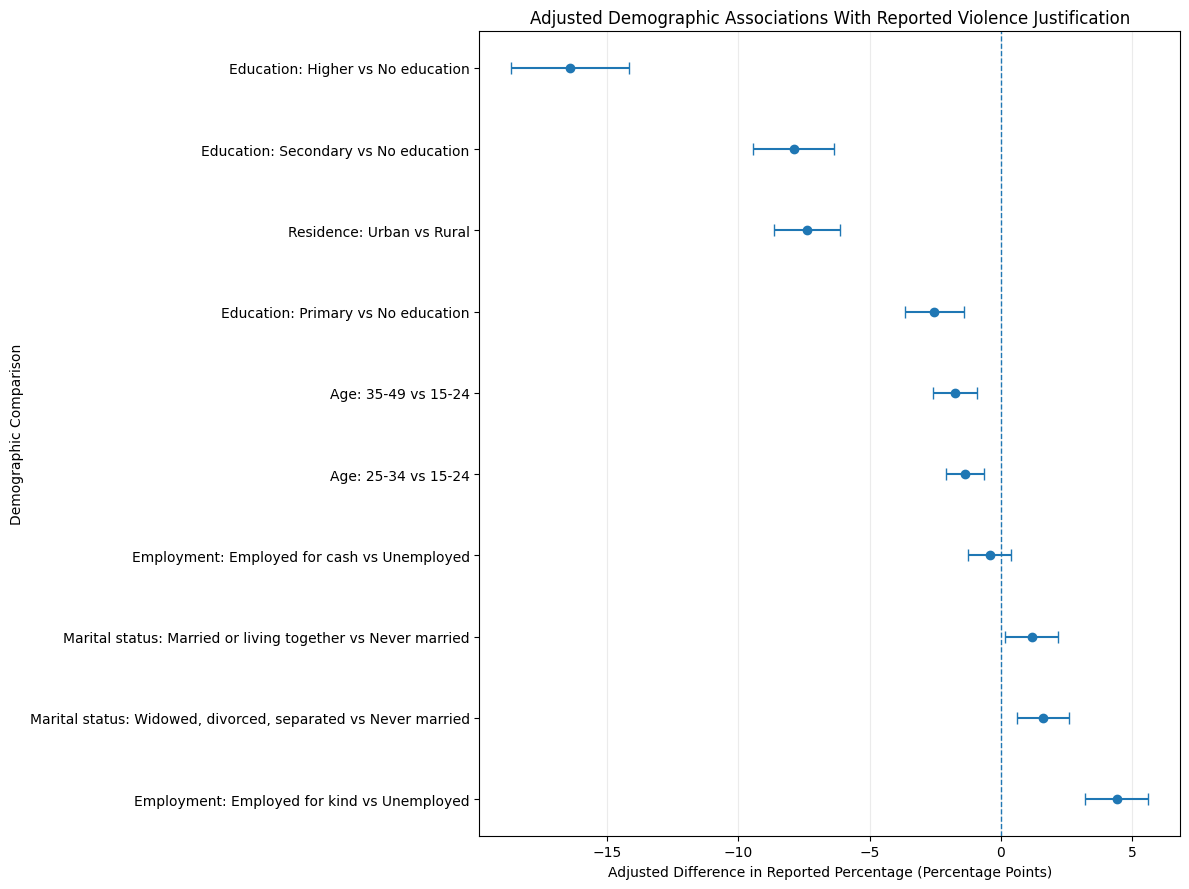

In [174]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = final_adjusted_effects.copy()

# Readable labels
plot_df["Label"] = (
    plot_df["Dimension"]
    + ": "
    + plot_df["Category"]
    + " vs "
    + plot_df["Reference"]
)

# Put strongest negative effects toward the bottom
plot_df = (
    plot_df
    .sort_values("Coefficient", ascending=False)
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))

lower_error = (
    plot_df["Coefficient"] - plot_df["CI_Lower"]
)

upper_error = (
    plot_df["CI_Upper"] - plot_df["Coefficient"]
)

plt.figure(figsize=(12, 9))

plt.errorbar(
    plot_df["Coefficient"],
    y,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    y,
    plot_df["Label"]
)

plt.xlabel(
    "Adjusted Difference in Reported Percentage (Percentage Points)"
)

plt.ylabel("Demographic Comparison")

plt.title(
    "Adjusted Demographic Associations With Reported Violence Justification"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Interpretation of the Final Adjusted Effects

The coefficient plot shows substantial differences in the magnitude of the demographic associations.

The strongest adjusted pattern is observed for **education**. Compared with groups with no education, the reported percentage decreases progressively across primary, secondary, and higher education. Higher education shows the largest adjusted difference in the entire demographic analysis, at approximately **−16.42 percentage points**.

**Residence** also shows a substantial difference. Urban groups have an adjusted reported percentage approximately **7.40 percentage points lower** than rural groups.

Age differences are considerably smaller. Groups aged 25–34 and 35–49 show adjusted differences of approximately −1.38 and −1.75 percentage points respectively compared with the 15–24 reference group.

Employment shows a heterogeneous pattern. Cash employment is not statistically distinguishable from unemployment, whereas employment for kind is associated with an approximately **4.41 percentage-point higher** reported value.

Marital-status differences are statistically detectable but comparatively modest, with married/living-together and widowed/divorced/separated groups showing adjusted differences of approximately 1–2 percentage points relative to never-married groups.

Overall, education and residence exhibit the largest adjusted demographic differences in the available data.

These estimates represent associations among aggregated demographic survey estimates. They should not be interpreted as individual-level causal effects.

## Why a Predictive Model Was Not Used

Although supervised machine-learning models such as Random Forest, XGBoost, or other regression algorithms could technically be fitted to this dataset, predictive modelling was not considered the most appropriate analytical objective.

The dataset contains **aggregated subgroup-level survey estimates rather than individual respondent-level observations**. Each row represents a reported percentage for a specific combination of country, gender, violence-justification scenario, and one demographic subgroup.

Importantly, the demographic dimensions are not jointly observed. For example, an education-based observation does not simultaneously contain the age, employment status, marital status, and residence of the same individuals. Treating these dimensions as ordinary predictive features would therefore create artificial combinations that are not supported by the underlying data structure.

In addition, there is no clearly defined future or individual-level target to predict. The `Value` variable is itself an aggregate reported percentage rather than a future behavioural outcome, incidence measure, or respondent-level class label.

A conventional random train-test split could also produce misleadingly strong model performance because multiple related observations originate from the same countries. If observations from the same country appeared in both the training and test sets, the model could partially learn country-specific patterns rather than demonstrate genuine generalization to unseen contexts.

Furthermore, each country is represented by only one survey year in this dataset. The data therefore do not provide a longitudinal history suitable for forecasting changes in attitudes over time.

For these reasons, the project prioritizes methods that are better aligned with the structure and analytical objectives of the data:

- **Regression analysis** to estimate adjusted associations between demographic groups and reported percentages.
- **Non-parametric statistical tests** to evaluate differences across violence-justification scenarios.
- **Principal Component Analysis (PCA)** to identify the dominant dimensions underlying cross-country variation.
- **K-Means clustering** to explore similarities in country-level response profiles.

A predictive modelling approach would become more appropriate if the project had access to individual-level respondent data, jointly observed demographic characteristics, repeated survey waves, additional country-level predictors, or a clearly defined prediction target.

Therefore, the decision not to build a supervised predictive model reflects the methodological limitations and intended use of the available data rather than the absence of modelling techniques.

# 53. Key Findings

The analysis reveals substantial variation in reported attitudes toward the justification of violence against women and girls across countries, demographic groups, and violence-justification scenarios.

1. **Violence-justification scenarios differ systematically.**  
   The Friedman test found strong evidence of differences among the five specific scenarios. Post-hoc analysis showed statistically detectable differences for nine of the ten scenario pairs. The only pair without a statistically significant difference after multiple-comparison correction was arguing with the husband versus going out without informing him.

2. **Neglecting the children is frequently the highest-valued specific scenario.**  
   Among the five individual scenarios, neglecting the children had the highest country-level mean in 48 of the 70 countries. Burning the food was not the highest-valued specific scenario in any country.

3. **Country-level variation is substantial.**  
   Large differences are observed between countries in both overall reported percentages and scenario-specific profiles. These differences should be interpreted in the context of differing survey years, missing-data patterns, and national contexts rather than as inherent characteristics of countries.

4. **A dominant common dimension explains most cross-country variation.**  
   PCA showed that the first principal component explains approximately **87.9%** of the variance across the five specific scenarios. All five scenarios load similarly and positively onto this component, suggesting that much of the country-level variation reflects a common overall dimension of reported violence justification.

5. **Country clustering largely reflects this common dimension.**  
   K-Means identified two broad country profiles, with one cluster showing consistently higher values across all five scenarios. PCA demonstrated that these clusters are separated primarily along the dominant first principal component, suggesting that the clustering represents segmentation along an underlying continuum rather than completely distinct country types.

6. **Education shows the strongest adjusted demographic gradient.**  
   Relative to groups with no education, reported percentages are approximately **2.54 points lower for primary education**, **7.90 points lower for secondary education**, and **16.42 points lower for higher education**, after accounting for country, gender, and scenario.

7. **Residence also shows a substantial adjusted difference.**  
   Urban groups have reported percentages approximately **7.40 percentage points lower** than rural groups after adjustment.

8. **Age and marital-status differences are statistically detectable but comparatively small.**  
   Their adjusted differences are generally between approximately one and two percentage points.

9. **Employment status has a mixed relationship with the outcome.**  
   Cash employment is not statistically distinguishable from unemployment, while employment for kind is associated with an approximately **4.41 percentage-point higher** reported value.

10. **The education findings are robust to multiple diagnostic checks.**  
    The education gradient persists under country-clustered inference, HC3 heteroskedasticity-robust inference, and sensitivity analysis excluding observations flagged by Cook's distance. Higher- and secondary-education estimates are particularly stable, while the primary-education estimate shows somewhat greater sensitivity in magnitude.

# 54. Practical and Policy Implications

The analysis identifies several areas that may be useful for organizations designing violence-prevention, gender-equality, education, and community-awareness programs.

The strong education gradient indicates that reported justification of violence varies substantially across education groups. This supports further investigation into how education access, educational attainment, curriculum content, and related socioeconomic conditions are associated with attitudes toward gender-based violence.

The rural–urban difference suggests that geographic context should also be considered when designing awareness and prevention programs. Rural and urban communities may require different communication strategies, service-delivery approaches, or further qualitative investigation to understand the mechanisms underlying the observed differences.

The scenario analysis shows that attitudes are not uniform across different justifications for violence. In many countries, neglecting children appears as the highest-valued specific justification. Prevention campaigns may therefore benefit from addressing scenario-specific social norms rather than discussing violence against women only as a single undifferentiated concept.

Country-level profiles can also help international organizations identify where additional contextual research may be valuable. However, cluster membership should not be treated as a ranking or as evidence that countries belong to fixed cultural categories.

Most importantly, the findings should be used to generate hypotheses and guide further investigation rather than to claim that demographic characteristics themselves cause attitudes toward violence.

# 55. Limitations

Several limitations should be considered when interpreting the results.

First, the dataset contains **aggregated survey estimates rather than individual respondent-level records**. The demographic dimensions therefore represent separate subgroup breakdowns and cannot be combined as though age, education, employment, marital status, and residence were simultaneously observed for the same individuals.

Second, the analysis is observational and cross-sectional. The regression coefficients represent associations and do not establish causal relationships.

Third, each country is represented by a single survey year in this dataset. Survey year therefore cannot be interpreted as a longitudinal time series of changing attitudes within countries.

Fourth, approximately 11% of the original `Value` observations are missing, and missingness is not evenly distributed across countries, genders, demographic categories, and questions. Male observations in particular contain substantially more missing values than female observations.

Fifth, countries were surveyed in different years. Cross-country comparisons therefore combine geographic variation with differences in survey timing and potentially changing social contexts.

Sixth, the outcome measures reported attitudes toward whether violence is justified under particular scenarios. They do not measure the actual incidence of violence, violent behaviour, victimization, or perpetration.

Seventh, country fixed effects account for systematic differences between countries in the adjusted demographic models, but they cannot identify the specific social, economic, institutional, or cultural mechanisms responsible for those differences.

Finally, clustering and PCA are exploratory methods. The country clusters provide useful statistical summaries of similar response profiles but should not be interpreted as naturally occurring or permanent classifications of countries.

# 56. Conclusion

This project investigated cross-country and demographic patterns in reported attitudes toward the justification of violence against women and girls using aggregated survey data from 70 countries.

The analysis identified substantial variation across countries and across different violence-justification scenarios. Scenario differences were supported by non-parametric statistical tests and large effect sizes.

Multivariate country-profile analysis revealed a strong common structure across the five specific scenarios. The first principal component explained approximately 87.9% of their cross-country variation, while K-Means clustering separated countries primarily according to their position along this dominant dimension.

Demographic analysis showed that education represents the strongest adjusted gradient in the dataset. Higher education groups reported substantially lower percentages than groups with no education even after controlling for country, gender, and scenario. Urban residence was also associated with considerably lower reported percentages than rural residence.

Age and marital-status differences were statistically detectable but smaller, while employment showed a more complex pattern rather than a simple employed-versus-unemployed relationship.

The results demonstrate the value of combining exploratory analysis, statistical inference, robustness checks, clustering, and dimensionality reduction when examining aggregated social survey data.

At the same time, the project highlights the importance of respecting the structure of the data. The findings describe associations among aggregated subgroup estimates and should not be interpreted as individual-level causal effects.

Overall, the analysis provides a detailed quantitative picture of how reported justification of violence varies across scenarios, demographic groups, and countries while identifying education, residence, and a strong common cross-country attitude dimension as central patterns in the available data.